# Methods: Symmetric Dual-Encoder Group-Head Regression for Same-Time Sky-to-Science Coefficient Transfer

**Status:** working notebook. §5.5 documents the current default model, a
per-group compressed variant of the architecture described in §6 that
replaced the uncompressed baseline on 2026-07-28. §11 lists what remains
incomplete; read it before quoting any number out of this notebook.

## 1. Scientific objective

Given two sky spectra taken *simultaneously* with a science exposure but at
different points on the sky, predict the sky-component coefficients at the
science line of sight.

At each valid row $i$ the model receives

- near-sky coefficients $\mathbf{c}^{(i)}_{near}$ and their context $\mathbf{x}^{(i)}_{ctx,near}$
- far-sky coefficients $\mathbf{c}^{(i)}_{far}$ and their context $\mathbf{x}^{(i)}_{ctx,far}$
- science-pointing context $\mathbf{x}^{(i)}_{ctx,sci}$

and predicts

$$
\hat{\mathbf{c}}^{(i)}_{sci} = f\!\left(\mathbf{c}^{(i)}_{near},\,\mathbf{c}^{(i)}_{far},\,
\mathbf{x}^{(i)}_{ctx,near},\,\mathbf{x}^{(i)}_{ctx,far},\,\mathbf{x}^{(i)}_{ctx,sci}\right).
$$

This is a **transfer** problem, not a forecast: all inputs are contemporaneous
with the target. The framing matters because airglow brightness fluctuates by
tens of percent on ten-minute timescales under gravity-wave forcing, and that
variation is not predictable from ephemeris context. It *is* measured by the two
sky telescopes, so the two sky coefficient vectors carry the information a
context-only regression cannot access. The network's job is only the
*differential* effect of pointing geometry.

Both sky contexts are supplied so the model can form the geometric relationship
between each sky pointing and the science pointing. A version that received only
$\mathbf{x}_{ctx,sci}$ could not do this even in principle.

## 2. Data model and triplet construction

Three decomposition products sharing a common input FITS source: sky-near,
sky-far, and science. The loader enforces

1. numeric coercion and finite-row filtering for coefficient and context matrices;
2. context harmonisation across near, far and science modes;
3. row-index alignment by intersection of valid source rows across all three products;
4. construction of shell-geometry features and folded time features from the timestamp.

Result: aligned $\mathbf{C}_{near},\mathbf{C}_{far},\mathbf{C}_{sci}\in\mathbb{R}^{N\times P}$
and $\mathbf{X}_{ctx,near},\mathbf{X}_{ctx,far},\mathbf{X}_{ctx,sci}\in\mathbb{R}^{N\times Q}$
with shared coefficient- and context-name schemas.

Near/far ordering is by angular separation from the science pointing, not by
telescope identity, so which physical telescope occupies the "near" channel
changes from row to row.

## 3. Filtering and quality control

Applied in this order, so the printed per-filter counts refer to the full
input dataset and only compose via boolean AND on the row-keep mask.

1. optional exclusion of tiles whose science pointing falls within a specified
   angular radius of a listed sky region (default: LMC at $(\alpha,\delta)=(80.894^\circ,-69.756^\circ)$
   and SMC at $(13.187^\circ,-72.829^\circ)$, 10$^\circ$ radius each). This is a
   coarse pre-filter for the target contamination discussed in §11.2 — both Clouds
   combine bright stellar populations, dense H II regions and diffuse ionised gas at
   velocities close enough to airglow to blend with a sky-component fit;
2. context sanity checks (non-negative altitude, bounded shell-path factors);
3. optional combined reduced-$\chi^2$ gating across near/far/science decompositions;
4. hard coefficient bounds for selected components;
5. kappa-sigma clipping in concatenated triplet coefficient space;
6. optional thinning, applied LAST so that steps 1–5 report fractions against the
   full pre-thinning dataset rather than a downsampled subset.

## 4. Geometric normalisation

This is the physical core of the current implementation and the part that
changed most recently.

### 4.1 The scaling law

An airglow amplitude observed at zenith angle $z$ relates to the intrinsic
emissivity of the emitting layer by

$$
A_{obs} = A_{int}\; \underbrace{V(z;h)}_{\text{slant path}}\;
\underbrace{10^{-0.4\,k(\lambda)\,[X(z)-1]}}_{\text{extinction}},
$$

with the van Rhijn factor for a thin shell at height $h$ above radius $R_\oplus$

$$
V(z;h) = \left[1 - \left(\frac{R_\oplus}{R_\oplus + h}\right)^{\!2}\sin^2 z\right]^{-1/2},
\qquad V(0;h)=1 .
$$

$V$ saturates toward the horizon (6.0 at $h=87$ km, 3.4 at $h=285$ km) rather
than diverging like $\sec z$, because the observer sits inside a curved shell.
Using plane-parallel airmass instead overstates the enhancement by 4% at
$z=60^\circ$ for a mesospheric layer and 12% for an ionospheric one — a smooth
function of $z$, so it does not average away and would alias into whatever the
network learns as geometry.

### 4.2 Where it is applied

`airglow_geometry_scale()` returns $V\cdot 10^{-0.4k(X-1)}$ per row and per
coefficient, and is applied **in physical units, before the square-root
transform and before robust scaling**. Neither of those operations commutes with
a division by the geometry factor: the scaler subtracts a median, so
$(\sqrt{c}-m)/V \ne \sqrt{c/V}-m$, and under the square root the correct divisor
would be $\sqrt{V}$ rather than $V$. Applying the correction downstream of either
transform produces an error of order $V$ itself.

Consequently:

- sky coefficients are divided by their own geometry factor before encoding;
- the target is divided by the science-pointing factor;
- network outputs are **intrinsic emissivities**, restored to observed
  amplitudes by multiplying by $V(z_{sci};h)\cdot 10^{-0.4k(X_{sci}-1)}$ inside
  `predict_sci_coefficients_group_mlp`;
- the `vanrhijn_*` context columns are therefore redundant as network inputs and
  are excluded from the encoders (`ctx_keep_idx`). `alt` and `airmass` are kept,
  because the moon and continuum groups still need them.

Because the reference point is $X=1$ rather than $X=0$, the recovered
"emissivity" is a **zenith-equivalent amplitude**, still carrying one airmass of
extinction. This is self-consistent and cancels in the sky-to-science transfer,
but the quantity is not a physical layer emissivity and should not be
interpreted as one.

`assert_context_is_physical()` guards every call. It checks physical ranges and
cross-checks any `vanrhijn_*` column against van Rhijn recomputed from `alt`.
Those two are computed independently upstream, so disagreement means the context
was transformed on the way in — the failure mode being guarded against is
evaluating geometry on scaler output, where an altitude of $\sim 0.5$ becomes a
zenith angle of $\sim 89.5^\circ$ and every row silently receives a near-horizon
factor of $\sim 6$.

### 4.3 Layer heights

Assigned per group via `GROUP_HEIGHT_FEATURE`: 87 km for `mesospheric`
(OH / O$_2$ / HO$_2$ / FeO / Na-like), 95 km for `atomic`, 285 km for
`ionospheric` (OI 6300/6364). The `moon`, `continuum` and `other` groups receive
a factor of exactly 1.0 — scattered moonlight and the aerosol/Rayleigh continuum
are not thin-shell emission and require scattering geometry, not van Rhijn.

### 4.4 Per-coefficient wavelengths

Extinction varies strongly across the LVM range, so a single wavelength per
group is not adequate: the `mesospheric` group alone spans OI 5577, Na D and the
OH/O$_2$ bands, and even within the OH Meinel system $k$ varies by nearly a
factor of two between the reddest and bluest bands. `resolve_coef_wavelengths_a()`
therefore assigns a wavelength per coefficient, from, in order of precedence as
currently implemented:

1. **basis centroid** — `coef_wavelengths_from_basis()` exploits linearity of the
   decomposition: reconstructing with $\mathbf{c}=\mathbf{e}_j$ isolates basis
   component $j$, whose intensity-weighted centroid is
   $\lambda_{eff}(j)=\sum\lambda|f_j| / \sum|f_j|$. This reads the actual basis,
   including level populations and the LSF, and is definitionally the right
   weighting. Cached, since it costs one reconstruction call per coefficient.
2. **input/PMD centroid** — `oh_wavelengths_from_input_file()` reproduces the OH
   line grouping from `pmd_popmodel_OH.dat` using `OH_GROUP_KEYS` and takes the
   $A_{ij}g_i$-weighted centroid of each group. Needed because `OH_###` names
   carry no wavelength token, so without it all 402 OH coefficients would
   collapse to one fallback value.
3. **coefficient name** — an explicit 4–5 digit wavelength token, else a species
   lookup (`_SPECIES_WAVELENGTH_A`).
4. **group default** — `GROUP_EFFECTIVE_WAVELENGTH_A`, last resort.

Provenance is recorded per coefficient and printed for the airglow groups,
because a silently wrong wavelength becomes a silently wrong extinction
correction.

### 4.5 Effective extinction

$k(\lambda)$ enters as $10^{-0.4k(X-1)}$. Three facts govern how it should be
chosen, and the implementation follows from them.

**Only the ratio matters, so the absolute value barely does.** The
sky-to-science transfer is

$$
R = \frac{V(z_{sci})}{V(z_{sky})}\;10^{-0.4\,k\,(X_{sci}-X_{sky})},
\qquad
\frac{\partial \ln R}{\partial k} = -0.4\ln 10\;\Delta X \approx -0.921\,\Delta X .
$$

The absolute $k$ cancels; only $k$ times the airmass *difference* survives. The
three pointings are simultaneous and share one atmosphere, so a per-night error
$\delta k$ propagates as $0.921\,\delta k\,\Delta X$. With realistic aerosol
variability ($\delta k \sim 0.02$–$0.04$ mag/airmass) and $\Delta X \sim 0.2$
that is a 0.2–0.7% transfer error, an order of magnitude below the gravity-wave
floor. **Per-observation extinction is therefore not modelled, and does not need
to be.** The spectrophotometric telescope would be better spent on the moon and
continuum terms, which depend on aerosol optical depth directly rather than
through $\Delta X$.

**A stellar curve is the wrong curve for an extended source.** This is the part
that does matter, because it is a coherent bias rather than random scatter. For
a star, scattered photons are lost. Airglow is a quasi-uniform source filling the
sky, so photons scattered out of the beam are largely replaced by photons
scattered in from adjacent lines of sight, and the effective attenuation is well
below the single-scattering value. Scattering dominates the total everywhere
airglow matters — Rayleigh plus aerosol is roughly 70–100% of $k$ from 4000 Å to
1 µm at LCO's 2380 m — so a stellar curve over-corrects, most severely in the blue.

**$h$ and $k$ are nearly degenerate.** Over the zenith range LVM observes,
$\ln V(z;h)$ and $X-1$ are collinear to $\rho > 0.995$ for $z \le 60^\circ$. A
height error can masquerade as an extinction error and vice versa. What the data
constrain, and all the model needs, is the product $V\cdot 10^{-0.4k(X-1)}$.

#### The implementation: fit $k_{\rm eff}$, do not model it

`fit_effective_extinction()` performs a Bouguer fit that uses airglow as its own
source. For coefficient $j$ and a simultaneous sky pair,

$$
\ln\!\frac{A_{near}}{A_{far}} - \ln\!\frac{V_{near}}{V_{far}}
= -0.4\ln 10\;k_{\rm eff}\,(X_{near}-X_{far}) + \varepsilon ,
$$

where $\varepsilon$ is the gravity-wave fluctuation between the two lines of
sight — zero mean in the log and uncorrelated with the airmass difference. The
intrinsic emissivity cancels because both arms are the same coefficient at the
same instant. The recovered $k_{\rm eff}$ absorbs the multiple-scattering
correction, the airglow-versus-stellar difference, the site aerosol level and any
residual error in the assumed layer height, none of which has to be modelled
explicitly.

Four details make the estimator trustworthy:

- **Layer height is held fixed.** Because of the degeneracy above, only
  $k_{\rm eff}$ is fitted. Fitting both would be ill-conditioned.
- **Selection is at column level only.** A per-row amplitude threshold is
  selection on the outcome: whichever arm sits at lower airmass has the smaller
  van Rhijn factor and fails the cut unless it carries a positive fluctuation,
  which correlates the retained residual with the sign of $\Delta X$. In testing,
  a 40th-percentile per-row cut inflated the recovered $k_{\rm eff}$ by a factor
  of 1.8. Coefficients are instead kept or dropped whole, via
  `min_positive_fraction`, and `retained_frac` is reported so residual row-level
  loss is visible.
- **Errors are cluster-robust, clustered on rows.** All coefficients in a row
  share one gravity-wave fluctuation, so naive OLS errors are far too small.
- **Stability is reported.** Each bin carries split-half values, and the fitted
  intercept — which should be zero. A significantly nonzero intercept indicates a
  relative throughput offset between the two sky channels rather than anything
  atmospheric.

`resolve_coef_extinction_k()` then interpolates the fitted values in wavelength
over well-constrained bins, falls back to the generic curve elsewhere, and clips
into $[0, k_{\rm generic}]$: the multiple-scattering argument makes the stellar
curve an upper bound, so a fitted value above it signals noise or an unmodelled
gradient, not physics. The resulting per-coefficient array is stored on the
dataset, threaded into `airglow_geometry_scale`, and saved in the training
artifacts so that prediction uses exactly the values training used. Setting
`USE_FITTED_EXTINCTION = False` in the wavelength cell reverts to the generic
curve.

On synthetic pairs with an injected $k_{\rm eff}$ at 40% of the stellar curve,
6000 rows and 12% gravity-wave scatter, the fit recovers a ratio of 0.41 with an
rms pull of 1.4.

**Cost.** The fit is fully vectorised. Because the airmass difference is
constant within a row, the design statistics and the whole cluster-robust meat
matrix reduce to per-row counts and per-row sums, so there is no flattened
$(N \times P)$ array and no per-cluster loop; van Rhijn is evaluated once per
distinct layer height as an $(N,)$ vector rather than as an $(N \times P)$
matrix. Only the robust scale for sigma clipping touches individual elements,
and it is estimated on a row subsample (`clip_sample_rows`). Measured against
the previous implementation this is 8–10x faster and about 9x smaller in peak
allocation, with identical coefficients and errors to floating-point precision.
At 50 000 rows and 419 coefficients the fit takes about 3 s.

**Known confounder.** A systematic horizontal gradient in layer brightness that
correlates with elevation angle at a fixed site would bias $k_{\rm eff}$, since
the estimator cannot distinguish it from extinction. The split-half columns catch
instability but not a persistent gradient. Checking the fit against azimuth, and
across seasons, would test for it.

## 5. Target and feature transforms

Coefficients enter model space via a non-negative square root,
$\mathbf{z}=\sqrt{\max(\mathbf{c},0)}$, applied *after* geometry normalisation.
If amplitudes track photon counts this is variance-stabilising, so squared error
in this space approximates $\chi^2$, and it degrades more gracefully than a log
near zero. The clip at zero does discard the sign of negative coefficients.

A robust (median/IQR) scaler is fit on **training rows only** and applied to
near, far and science coefficients and contexts, with values clipped to $\pm 25$.

## 5.5 Per-group compression (the model this notebook now trains)

The diagnostic of §9.1 said the coefficient space is heavily redundant. On
this dataset it identifies 79 transferable degrees of freedom in the 442
coefficient columns — a 5.6× reduction on the target and, because the
encoder consumes the same per-arm scores, on the encoder input as well.
The default model of the notebook is trained in this compressed
representation. The uncompressed model of §6 is kept only as the parent
class of `DualEncoderGroupHeadMLPCompressed`; its architecture, geometry
handling, splitting and optimiser are reused verbatim, and it is no longer
trained.

The compression is per group, and is not the same operation for every group.
For each group $g$:

1. **Geometry removal.** Coefficients are divided by the airglow geometry
   factor of §4, in physical units, giving zenith-equivalent amplitudes.
2. **Space transform.** The group is mapped into the space where its physical
   variability is linear:
   - `mesospheric` — asinh (multiplicative variation from rotational
     temperature and vibrational populations),
   - `moon` — linear (spline coefficients are already an additive basis),
   - `atomic` / `continuum` / `ionospheric` / `other` — sqrt "identity"
     (variance-stabilising, no rotation, no truncation).
3. **Column standardisation.** Subtract per-coefficient mean, divide by
   per-coefficient sd, both fit on training rows only, pooled over
   near/far/sci. This is the correlation-matrix parameterisation for the PCA
   that follows.
4. **PCA rotation.** Eigendecomposition of the sample covariance in the
   standardised space, ordered by variance. Rotation only; no truncation at
   this step.
5. **Cross-arm selection.** Retain component $c$ iff $r_{xarm}(c) > 0.5$ on
   held-out nights, where $r_{xarm}$ is the Pearson correlation of the
   near-arm score with the far-arm score for that component. On this dataset
   the threshold $0.5$ is roughly $30$ times the correlation null.
6. **Score-space training.** The encoder, trunk and heads work entirely in
   the retained score space. Group heads emit signed linear outputs;
   non-negativity is restored on the reconstruction path when scores are
   inverse-projected back to physical emissivity and clipped at zero (the
   sqrt-identity groups invert through square and are non-negative by
   construction).

**Selection by correlation, not by variance rank.** PCA orders by variance;
transferability is a different ordering. A shared mode can sit behind an
arm-private one, so truncating at "the first $k$" throws away exactly the
directions that *can* be predicted at a third pointing while keeping the
ones that cannot. Numerically, on this dataset the retained mesospheric
components are not the leading block. The `xarm_keep` array in each fitted
compressor records which components were kept.

**Consequences for the rest of the pipeline.**

- **Loss balance (§7).** With per-group scores in a narrow range across
  groups the $1/\sqrt{n_g}$ per-group weight no longer collapses the
  per-coefficient weight ratio, and `continuum_group_weight` is retired.
- **Smoothness prior.** The moon spline's PCA truncation is itself a
  smoothness prior. `moon_smooth_lambda` is retired.
- **Non-negativity.** Softplus in coefficient space is replaced by clipping
  in physical space after the inverse compressor. Small negatives from
  numerical noise do not reach the science pipeline.
- **Out-of-distribution flag.** Reconstruction residual in the fitted basis
  can be reported per row as an OOD indicator for nights that fall outside
  the training span.

**Empirical result (night-held-out test, 1386 rows).** The compressed model
beats the uncompressed baseline on mean RMSE by ~33%, median RMSE by ~26%,
MAE by ~34%, and median per-coefficient Pearson correlation by 0.09 (0.80 →
0.89). Mean per-coefficient correlation drops by 0.025, which is the
expected penalty on coefficients whose truth has weak but nonzero signal in
the discarded subspace and by design collapses to a constant after inverse
projection. Spectrum-space per-row RMSE (evaluated in the batch-RMSE cell)
tracks the coefficient-space improvement.

## 6. Network architecture

### 6.1 Symmetric dual encoder

A shared MLP $E_{sky}$ is applied to each sky arm, concatenating that arm's
geometry-normalised coefficients with that arm's own context:

$$
\mathbf{e}_{near}=E_{sky}([\mathbf{z}_{near};\mathbf{x}_{ctx,near}]),\qquad
\mathbf{e}_{far}=E_{sky}([\mathbf{z}_{far};\mathbf{x}_{ctx,far}]).
$$

Weight sharing forces both channels onto a common representation manifold.

### 6.2 Fusion

$$
\mathbf{z}_{fuse} = [\,\mathbf{e}_{mean};\ \mathbf{e}_{diff};\ |\mathbf{e}_{diff}|;\ E_{ctx}(\mathbf{x}_{ctx,sci})\,],
\qquad
\mathbf{e}_{mean}=\tfrac12(\mathbf{e}_{near}+\mathbf{e}_{far}),\quad
\mathbf{e}_{diff}=\mathbf{e}_{near}-\mathbf{e}_{far}.
$$

Note that $\mathbf{e}_{diff}$ is antisymmetric under exchange of the two arms, so
the model is *not* invariant to swapping them. This is intentional given that
near/far is defined by separation, but it forecloses swap augmentation and does
not generalise to more than two reference measurements.

### 6.2b Context features reaching the encoders

`drop_vanrhijn_from_context` (default **False**) controls whether the
`vanrhijn_*` columns are hidden from the encoders. They are redundant *for the
airglow groups*, whose geometry is now removed analytically — but not for the
moon and continuum groups, which receive a geometry factor of exactly 1.0 and
must learn their airmass dependence from context. Since the encoders are shared
across all heads, dropping those columns removes smooth non-linear functions of
altitude from every head, leaving only raw `alt` and `airmass`. That is a
plausible cause of degraded continuum reconstruction, and most plausible in the
blue, where the scattered continuum's airmass dependence is strongest. The
default was changed to keep them; set the flag to `True` to A/B it.

### 6.3 Trunk and group heads

A shared trunk maps $\mathbf{z}_{fuse}$ to an intermediate representation;
group-specific heads then predict coefficient subsets partitioned by physical
family and emission layer (`moon`, `continuum`, `mesospheric`, `ionospheric`,
`atomic`, `other`). Heads end in Softplus, enforcing non-negative emissivity in
model space. Grouping is defined once, in the loaders cell, and is shared by the
wavelength resolver, the structure-function diagnostics and the model.

## 7. Loss

The compressed model trains SmoothL1 on scaled score-space, per group:

$$
\mathcal{L} = \frac{1}{G}\sum_{g=1}^{G} w_g\,\mathrm{SmoothL1}(\hat{\mathbf{s}}_g,\mathbf{s}_g),
\qquad w_g = n_{g,\mathrm{score}}^{-1/2},
$$

where $\mathbf{s}_g$ is the retained score vector for group $g$ (§5.5).
On this dataset the per-group score dimensions are `moon`=27, `mesospheric`=45,
`atomic`=7. Compared with a per-coefficient loss on the 442-column raw
target, the $1/\sqrt{n_g}$ balancing now spans a narrow range ($\sim 0.15$–$0.38$)
rather than five orders of magnitude, so the continuum head no longer
dominates the gradient and the OH block no longer sits in the noise floor.
`continuum_group_weight` and `moon_smooth_lambda` are retired: the first
is unnecessary in the score-space balance, and the second is subsumed by
the PCA truncation on the moon spline (§5.5).

Only components with $r_{xarm} > 0.5$ receive a head output at all, so
directions the sky arms cannot transfer to the science pointing contribute
nothing to the loss and are reconstructed as a constant from the training
mean. That is a feature: the model does not spend capacity trying to fit
unpredictable structure.

The loss acts on scores of zenith-equivalent emissivity, not on observed
amplitude, so a given error costs the same at all zenith angles. Per-group
unweighted validation losses are still tracked and printed at the best
epoch to separate "this head is under-trained" from "this head is being
traded away".

## 8. Optimisation and data splitting

AdamW, global-norm gradient clipping, patience-based early stopping on
validation loss, best-epoch checkpoint restoration.

`split_mode` defaults to **`night_grouped`**: rows are grouped by
`floor(mjd - 0.5)`, which correctly collects an LCO night (evening twilight near
23:00 UT and morning near 10:00 UT map to the same integer), and whole nights are
assigned to train/val/test. `time_sorted` and `random` remain available;
`random` leaks badly, because consecutive exposures on one night are near
duplicates, and should be used only for debugging. Unrecognised values raise.

## 9. Evaluation

1. coefficient-space metrics on held-out rows;
2. single-row full-spectrum reconstruction checks;
3. random-subset spectral RMSE (near self-reconstruction, far self-reconstruction,
   predicted science versus observed science);
4. relationship visualisations in context and latent space;
5. structure-function diagnostics $D(\Delta\theta)=\langle(\Delta\log A_{resid})^2\rangle$
   for grouped coefficients after geometric normalisation.

Comparing predicted-science reconstruction RMSE against near/far
self-reconstruction RMSE benchmarks against an internal decomposition-fidelity
floor. That floor is a sanity bound, not a competitor: see §11.

### 9.1 Effective dimensionality of the coefficient groups

A dedicated cell measures how many degrees of freedom each group actually
carries, on geometry-normalised amplitudes, with the basis fit on training
nights only. Three criteria are reported because they disagree:

- **Variance fraction** — shown only to demonstrate that it is a trap here. Past
  the real structure the leftover variance is noise spread over hundreds of
  directions, so "99.9% of variance" tries to capture the noise.
- **Horn parallel analysis** — eigenvalues compared against a column-shuffled
  null, computed from the *correlation* matrix. Standardisation is essential:
  otherwise the null inherits the column variances, which span a large range
  (a high-excitation OH line is far more sensitive to $T_{\rm rot}$ than a
  low-excitation one), and the method badly under-detects. This is the right
  rank for the **encoder input**.
- **Cross-arm score correlation** — near and far scores projected onto the same
  basis and correlated per component, on held-out nights. A direction
  uncorrelated between two simultaneous lines of sight cannot be predicted at a
  third, so this is the right rank for the **target**.

Two structural points fall out of the second and third criteria. The
transferable components are *not* generally the leading block, because PCA sorts
by variance rather than transferability — the target basis is therefore a subset
selected by correlation, not a truncation at the first $k$. And the transferable
count can *exceed* the Horn rank, because correlating two arms beats the noise
floor of either one alone; the encoder input should be sized by the larger of
the two.

The projection space is `asinh` by default rather than `sqrt`: a change in
rotational temperature is a single linear direction in log space but a curved
manifold in linear space, so log-like coordinates give a more compact and more
interpretable basis. This is deliberately decoupled from the loss, which stays
in the variance-stabilising `sqrt` space. A sensitivity scan reports the Horn
rank under each transform.

The cell ends with a printed recommendation: compression ratio, resulting
parameter counts for the encoder input layer and the group heads, the revised
per-coefficient weight balance (§7), and per-group caveats. The recommendation of this cell — proceed with per-group compression using
asinh for the mesospheric group, linear for moon, sqrt-identity for the
rest, and target components selected by cross-arm correlation above 0.5 on
held-out nights — has been adopted as the default model of the notebook;
see §5.5. Two consequences that were decided deliberately before adopting
a projection: Softplus non-negativity is lost in score space, and PCA
truncation on the moon spline is itself a smoothness prior, making
`moon_smooth_lambda` redundant. Reconstruction residual in the fitted
basis also serves as an out-of-distribution flag.

## 10. Reproducibility

- deterministic under explicit seeds (split and random subsets);
- artifacts carry scalers, group mapping, resolved per-coefficient wavelengths
  and their provenance, best checkpoint, and resolved hyperparameters;
- RMSE reported in both physical and display-scaled units.

## 11. Known limitations and open items

Ordered by expected impact.

**11.1 No naive baseline is computed.** Nothing in the notebook currently answers
"does the network beat geometry-scaled interpolation of the two sky spectra?"
Reconstructing the science spectrum from `coef_near` alone, and from the
`airglow_geometry_scale`-weighted combination of near and far, is the comparison
that decides whether the model earns its place.

**11.2 The target is contaminated by the science field.** `coef_sci` is fitted to
`FLUX_SCI`, which contains the nebular emission of the target. A sky-component
fit to that spectrum absorbs nebular flux, worst in OI 6300, which is
simultaneously a thermospheric airglow line and a shock/DIG diagnostic. Training
on it teaches the model to over-subtract, most severely in the brightest fields.
The `sci_rmse` metric compounds this: a perfect sky prediction leaves nonzero
residual at every nebular line, and the metric scores that as error. Cheap
diagnostic: if `sci_rmse` ever drops below `near_rmse`/`far_rmse`, the model is
fitting the object. Kinematic separation (sky component fixed at
$v_{topo}=0$, nebular component at the field's systemic velocity) works for
targets with large $|v_{sys}|$ and not at all for local gas.

**11.3 Extinction confounder (open).** The effective-extinction fit of §4.5 is
implemented and used by default, which removes the stellar-curve bias. What
remains open is the confounder noted there: a horizontal brightness gradient
correlated with elevation would be absorbed into $k_{\rm eff}$. Worth testing by
refitting against azimuth and by season, and by refitting per lunation to track
aerosol.

**11.4 Per-coefficient heights (open).** Heights are still per-group, so OI 5577
(~96 km) and Na D (~92 km) are treated at the OH height of 87 km. A
per-coefficient height array is now a small extension, since the per-coefficient
wavelength array already exists. The $h$–$k$ degeneracy limits how much this can
matter, and the fitted $k_{\rm eff}$ already absorbs part of the height error.

**11.5 Population-model weighting (open).** The wavelength precedence is now
explicit — basis first, population model filling only what the basis could not
resolve — and `cross_check_wavelengths()` compares the two where both exist,
warning if they disagree by more than 25 Å. Both routes now read the same input
product, which is a precondition for that comparison to mean anything. One
approximation remains: the population-model route weights each OH group's
centroid by $A_{ij}g_i$, ignoring the Boltzmann factor across rotational levels
within a group. The basis route does not have this problem, since it reads the
reconstructed component directly, so the residual exposure is limited to
coefficients the basis route cannot resolve.

**11.6 Loss is in coefficient space, not spectrum space.** Basis components are
partially degenerate: two coefficient vectors can differ substantially yet
produce near-identical spectra. Since the decomposition is linear ($s=B\mathbf{c}$),
the objective that matches the science requirement is
$(\hat{\mathbf{c}}-\mathbf{c})^\top B^\top\Sigma^{-1}B(\hat{\mathbf{c}}-\mathbf{c})$
with $\Sigma$ the per-pixel variance and nebular-contaminated ranges masked. That
also removes the need for `continuum_group_weight` and fixes the $w_g$ issue in §7.

**11.7 No predictive uncertainty.** The model is deterministic, so nothing
propagates into the science error budget. Given that §11.2 prevents verifying the
prediction against the science spectrum in general, calibrated uncertainty is not
optional. Minimum viable version: a second output per group giving $\log\sigma$,
trained under Gaussian NLL, checked with a PIT histogram on night-held-out rows.

**11.8 Filtering removes the hard cases.** Kappa-sigma clipping runs on
concatenated near+far+**sci** coefficients, so rows extreme in the *target* are
rejected — bright time, high airmass, high solar activity. That raises test scores
and lowers real-world performance. Clip on inputs only and keep the extremes as a
held-out stress set. Similarly, $\chi^2$ gating uses `nanmax` across the three
products, so rows where a sky-only model fits `FLUX_SCI` badly are cut, biasing
the training set toward faint fields.

**11.9 Context gaps.** No solar-activity proxies (F10.7, Kp), which are the main
predictors for the 285 km group. `sun_alt` is degenerate between evening and
morning twilight, though OH decay and OI 6300 recombination behave differently in
the two — a signed time-from-solar-midnight would break it. No science-to-sky
angular separation or bracketing indicator. No telescope-identity flag, which
matters because near/far assignment shuffles E and W (§2), so any throughput
difference between the two sky telescopes enters as a geometry-correlated
systematic.

**11.10 Per-coefficient heights, not just wavelengths.** Heights are still
per-group, so OI 5577 (~96 km) and Na D (~92 km) are treated at the OH height of
87 km. Now that a per-coefficient wavelength array exists, a per-coefficient
height array is a small extension. The $h$–$k$ degeneracy (§4.5) limits how much
this can matter.

**11.11 Hyperparameter search over the compressed loss (resolved on 2026-07-28).**
A dense 18-config grid centred on the previous default
(encoder_dims ∈ {(320,160),(384,192)}, head_dim ∈ {160,192,224},
lr ∈ {5e-4,7e-4,1e-3}, trunk_dims=(320,160), weight_decay=1e-4,
seed=42, budget=50 epochs/patience 4) was evaluated on the night-held-out
test split. The winner — encoder_dims=(384,192), trunk_dims=(320,160),
head_dim=224, lr=5e-4, weight_decay=1e-4 — improved mean per-coefficient
RMSE from 102.4 to 99.75 (−2.6%), MAE from 74.96 to 71.33 (−4.8%), and
median per-coefficient Pearson correlation from 0.889 to 0.890, converging
at epoch 30 rather than 20 under the same patience. That geometry has been
adopted as `default_dual_group_config`. A prior wide random sweep
(sampled 14 of ~1200 candidates) missed the exact default geometry, and
its local best was 2.6% worse than the current default when retrained at
the default budget; both sweeps are retained in the notebook (gated by
`RUN_SWEEP` / `RUN_DENSE_SWEEP`) as templates for the next dataset. The
improvement was measured at a single seed (42), so a multi-seed rerun is
still open work if a smaller change matters. The stale uncompressed sweep
cell was removed on 2026-07-28.

## 12. Change log

**2026-07-28 — spectrum-space evaluation gated to the training filter set.**
The random-subset batch RMSE cell now applies chi2 (max reduced-$\chi^2$
over near/far/sci, 90th percentile capped at 10) and LMC/SMC field
exclusion (10$^\circ$ each) to the every10 triplet BEFORE drawing the
random rows. That keeps the evaluation set out of tiles the training set
excludes, so `sci_pred_vs_true` no longer picks up contamination from the
Magellanic Clouds or from decompositions the training set had already
thrown out. Hard coefficient bounds and kappa-sigma clipping are
deliberately NOT applied to the evaluation set: those are training-time
filters on the target, and applying them would remove the model's
hardest true cases from the reconstruction diagnostic.

**2026-07-28 — filter order reorganised.** Inside `apply_triplet_filters`,
the LMC/SMC field exclusion (§3, step 1) now runs before any other filter, and
thinning (§3, step 6) runs last. The intermediate per-filter counts are
reported against the full pre-thinning dataset (rather than a downsampled
subset), and "final kept rows" is announced at the very end. Boolean AND is
commutative, so the final `filtered_triplet` and every downstream number are
identical to the previous ordering; only the printed diagnostics change.

**2026-07-28 — Magellanic Cloud field exclusion.** `apply_triplet_filters`
now excludes tiles whose science pointing lies within 10$^\circ$ of the LMC
(SIMBAD J2000 centre $\alpha=80.894^\circ$, $\delta=-69.756^\circ$) or the SMC
($\alpha=13.187^\circ$, $\delta=-72.829^\circ$). Rationale: §11.2 — both
Clouds host bright stellar populations, dense H II regions and diffuse ionised
gas at velocities close enough to airglow to blend with the sky-component fit
of `coef_sci`, and no per-tile source-mask exists that would reject them
cleanly. Behaviour is controlled by `apply_triplet_filters`'s new
`exclude_field_regions` parameter (defaults to `[LMC_EXCLUSION, SMC_EXCLUSION]`;
pass `[]` to disable). `build_triplet_coef_dataset` now attaches `sci_ra` /
`sci_dec` from META so the filter has the coordinates without a second META
load. Downstream cells (structure function, wavelength / extinction fit, PCA
rank, compressor, training) must be re-run against the new `filtered_triplet`
for the model numbers to be consistent with the new data cut.

**2026-07-28 (latest)** — see the hyperparameter adoption entry above; both
per-group compression and the sweep-adopted config now belong to the same date.

**2026-07-28 — hyperparameter adoption for the compressed model.** A dense
exhaustive sweep centred on the previous default (18 configs varying
encoder_dims, head_dim, lr, trunk_dims fixed at (320,160), weight_decay
fixed at 1e-4) at the default budget (n_epochs=50, patience=4, seed=42)
identified a small improvement: encoder_dims=(384,192), head_dim=192→224,
lr=7e-4→5e-4, converging at epoch 30 with mean RMSE 99.75 vs 102.4,
MAE 71.3 vs 75.0, median correlation 0.890 vs 0.889 on the night-held-out
test split. `default_dual_group_config` has been updated; the prior
wide random sweep and the dense sweep both remain in the notebook as
templates.

**2026-07-28 — per-group compression is the default.** The rank
diagnostic of §9.1 identified 79 transferable degrees of freedom in the 442
coefficient columns. §5.5 documents the compression pipeline that
implements this: asinh for `mesospheric`, linear for `moon`, sqrt-identity
for the rest, column standardisation, PCA rotation, and cross-arm-
correlation selection at $r_{xarm} > 0.5$ on held-out nights.
`DualEncoderGroupHeadMLPCompressed` consumes the resulting per-arm scores
and emits signed linear outputs; non-negativity is restored by clipping the
reconstructed physical emissivity. The loss is SmoothL1 per group in scaled
score space; `continuum_group_weight` and `moon_smooth_lambda` are retired.
On the night-held-out test split (1386 rows) the compressed model beats
the uncompressed baseline on mean RMSE by ~33%, median RMSE by ~26%, MAE
by ~34%, median per-coefficient correlation by 0.09; spectrum-space
per-row RMSE tracks the coefficient-space result. The uncompressed
training driver and its stale sweep have been removed from the notebook;
`DualEncoderGroupHeadMLP` remains as the parent architecture.

**2026-07-27 — dimensionality diagnostic.** Added §9.1: per-group effective rank on geometry-normalised amplitudes, with Horn parallel analysis on the correlation matrix, cross-arm score correlation on held-out nights, a transform sensitivity scan, a three-panel plot per group and a printed recommendation. No change to the model; this is decision support for whether to introduce a projection layer.

**2026-07-27 — performance and diagnostics.** `fit_effective_extinction`
vectorised: the per-cluster Python loop in the robust covariance was replaced by
the closed form in `_masked_ols_rowconst`, the $(N \times P)$ van Rhijn matrices
by per-height $(N,)$ vectors, and the flattened design arrays by per-row
sufficient statistics. 8–10x faster, ~9x less memory, identical results. Basis
wavelengths are now derived only for coefficients the population model could not
resolve plus a cross-check sample, instead of all of them, and the cache key
includes the wavelength grid so it cannot silently return values computed on a
different grid. Cell 7 prints per-stage timings. Per-group unweighted validation
losses are recorded and printed at the best epoch, and training warns if the best
epoch is the last. `drop_vanrhijn_from_context` added, defaulting to False so the
non-airglow heads keep those features.

**2026-07-27 (later) — effective extinction.** The generic LCO curve is a stellar
curve and over-corrects an extended source. `fit_effective_extinction()` now fits
$k_{\rm eff}$ per wavelength bin from the simultaneous sky pairs, with
cluster-robust errors, column-level selection, split-half stability and an
intercept diagnostic; `resolve_coef_extinction_k()` applies it with fallback and
clipping; the result is threaded through `airglow_geometry_scale` and stored in
the training artifacts. `airglow_geometry_scale` was factored into
`airglow_van_rhijn_matrix` and `airglow_extinction_matrix`, which the fit needs
separately. The structure-function diagnostic now calls the shared geometry
helper: it previously divided by van Rhijn *and* by airmass, a double correction
whose spurious $-\log(X_{near}/X_{far})$ term inflated $D(\Delta\theta)$ by more
than an order of magnitude and left it almost uncorrelated with the true field.
Its group amplitude now defaults to a sum rather than a median, which for a group
of 402 OH coefficients could otherwise sit near zero and hit the logarithm floor.
Both wavelength routes now read the same input product, precedence is explicit
with the basis primary, and the two are cross-checked.

**2026-07-27 — geometry restructuring.** Airglow geometry normalisation moved out
of the network and into the data pipeline, in physical units
(`airglow_geometry_scale`). Previously the correction was evaluated on
robust-scaled context and applied in scaled square-root space; both were wrong,
and the combination produced a net transfer factor *anti-correlated* with the
correct one. `_van_rhijn_factor_torch`, `_geometry_scale` and
`_apply_airglow_geometry` removed; `forward()` is now encode → fuse → trunk →
heads. Per-coefficient effective wavelengths added, from the basis and from the
OH population model, replacing one wavelength per group. Real LCO extinction
curve adopted. `assert_context_is_physical` added as a regression guard. Coefficient
grouping consolidated to a single definition. `y_te` in the driver cell fixed
(was undefined on a clean kernel).

**2026-07-26 — splitting and plumbing.** Night-grouped splitting added and made
the default. Both sky contexts now reach the model; previously they were built,
scaled, passed through the API and dropped in `forward()`. Post-hoc Ridge
corrector and moon spline prior stage removed. `moon_illum` dropped from context;
`moon_phase` retained. Relationship plots fixed to four panels per row with
shared row y-axes.


## Notes to self
- Explain Bouguer Fit
- Which coordinates in context?
- Ecliptic coordinates for Zodi?
- 

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from astropy.io import fits
from astropy.table import Table
from IPython.display import HTML, display
from sky_decomp.fit import (
    reconstruct_component_spectra,
    vac_to_air,
    decode_hitran_id,
    OH_GROUP_KEYS,
)
import os
import re
# Reused constants
FACTOR = 1e14
PALACE_DIR = '../'

Please note the archive will not be accessible on 29 July from 11 to 13 CEST, for maintenance purposes. Apologies for the inconveniences.


In [2]:
# Reused decomposition/context loading helpers
LAYER_HEIGHTS_KM = {
    'mesospheric_oh': 87.0,
    'mesospheric_atomic': 95.0,
    'ionospheric_red': 285.0,
}

TIME_FEATURE_NAMES = {
    'obstime_year_sin',
    'obstime_year_cos',
    'obstime_day_sin',
    'obstime_day_cos',
    'obstime_lunation_sin',
    'obstime_lunation_cos',
}

VAN_RHIJN_FEATURES = {
    'vanrhijn_87km': LAYER_HEIGHTS_KM['mesospheric_oh'],
    'vanrhijn_95km': LAYER_HEIGHTS_KM['mesospheric_atomic'],
    'vanrhijn_285km': LAYER_HEIGHTS_KM['ionospheric_red'],
}


def _as_array(x):
    arr = np.asarray(x)
    if arr.dtype.kind in ('U', 'S', 'O'):
        return None
    return arr.astype(np.float32)


def _coerce_coef_hdu_to_table(coef_hdu):
    data = coef_hdu.data
    if isinstance(coef_hdu, (fits.BinTableHDU, fits.TableHDU)):
        return Table(data)

    arr = np.asarray(data, dtype=np.float32)
    if arr.ndim != 2:
        raise ValueError(f'Expected 2D COEF image, got shape={arr.shape}')

    n_coef = arr.shape[1]
    names = []
    for i in range(n_coef):
        key = f'COEF{i:04d}'
        names.append(str(coef_hdu.header.get(key, f'coef_{i:04d}')))
    return Table({name: arr[:, i] for i, name in enumerate(names)})


def _select_context_from_labels(meta, meta_upper, labels, base_name):
    e_key = f'SKYE_{base_name.upper()}'
    w_key = f'SKYW_{base_name.upper()}'
    if e_key not in meta_upper or w_key not in meta_upper:
        return None

    arr_e = _as_array(meta[meta_upper[e_key]])
    arr_w = _as_array(meta[meta_upper[w_key]])
    if arr_e is None or arr_w is None:
        raise ValueError(f'Labeled context columns for {base_name} are non-numeric.')

    is_e = labels == 'SKYE'
    is_w = labels == 'SKYW'
    if not np.all(is_e | is_w):
        bad = np.unique(labels[~(is_e | is_w)])
        raise ValueError(f'Unexpected label values: {bad}')

    return np.where(is_e, arr_e, arr_w).astype(np.float32)


def _table_to_float32_matrix(tbl, value_name):
    names = list(tbl.colnames)
    cols = []
    numeric_names = []
    for name in names:
        arr = _as_array(tbl[name])
        if arr is not None:
            cols.append(arr)
            numeric_names.append(name)

    if len(cols) == 0:
        raise ValueError(f'No numeric {value_name} columns found.')

    return np.column_stack(cols).astype(np.float32), numeric_names


def _altitude_to_zenith_deg(alt_deg):
    alt = np.asarray(alt_deg, dtype=np.float64)
    return np.clip(90.0 - alt, 0.0, 89.9)


def _van_rhijn_factor(alt_deg, layer_height_km, earth_radius_km=6371.0):
    z_rad = np.deg2rad(_altitude_to_zenith_deg(alt_deg))
    shell_ratio = float(earth_radius_km) / (float(earth_radius_km) + float(layer_height_km))
    denom = 1.0 - (shell_ratio * np.sin(z_rad)) ** 2
    denom = np.clip(denom, 1e-6, None)
    return (1.0 / np.sqrt(denom)).astype(np.float32)


def _extract_obstime_mjd(meta, meta_upper):
    from astropy.time import Time

    candidates = ('OBSTIME', 'MJD', 'MJD_OBS', 'MJD-OBS', 'DATE_OBS', 'DATE-OBS')
    for key in candidates:
        if key not in meta_upper:
            continue

        raw = np.asarray(meta[meta_upper[key]])
        if raw.dtype.kind in ('i', 'u', 'f'):
            return raw.astype(np.float64)

        s = np.asarray(raw).astype(str)
        try:
            return Time(s, format='isot', scale='utc').mjd.astype(np.float64)
        except ValueError:
            return Time(s).mjd.astype(np.float64)

    raise KeyError('Could not find an OBSTIME/MJD/DATE-OBS-like META column for time features')


def _build_obstime_feature(meta, meta_upper, feature_name):
    mjd = _extract_obstime_mjd(meta, meta_upper)
    two_pi = 2.0 * np.pi

    if feature_name == 'obstime_year_sin':
        return np.sin(two_pi * mjd / 365.2422).astype(np.float32)

    if feature_name == 'obstime_year_cos':
        return np.cos(two_pi * mjd / 365.2422).astype(np.float32)

    frac_day = mjd - np.floor(mjd)
    if feature_name == 'obstime_day_sin':
        return np.sin(two_pi * frac_day).astype(np.float32)

    if feature_name == 'obstime_day_cos':
        return np.cos(two_pi * frac_day).astype(np.float32)

    if feature_name == 'obstime_lunation_sin':
        return np.sin(two_pi * mjd / 29.53058867).astype(np.float32)

    if feature_name == 'obstime_lunation_cos':
        return np.cos(two_pi * mjd / 29.53058867).astype(np.float32)

    raise KeyError(f'Unsupported obstime feature name: {feature_name}')


def _resolve_base_context_array(meta, meta_upper, labels, kind, base_name):
    key = base_name.upper()

    if kind == 'sci':
        sci_key = f'SCI_{key}'
        if sci_key in meta_upper:
            arr = _as_array(meta[meta_upper[sci_key]])
            if arr is None:
                raise ValueError(f'Context column {sci_key} is non-numeric.')
            return arr

    if key in meta_upper:
        arr = _as_array(meta[meta_upper[key]])
        if arr is None:
            raise ValueError(f'Context column {base_name} is non-numeric.')
        return arr

    if labels is not None:
        arr = _select_context_from_labels(meta, meta_upper, labels, base_name)
        if arr is not None:
            return arr

    return None


def _resolve_context_feature(meta, meta_upper, labels, kind, feature_name, cache):
    if feature_name in cache:
        return cache[feature_name]

    if feature_name in ('obstime_mjd', 'obstime_mjd_z'):
        raise ValueError('Direct time features are excluded from model context; use only periodic year/day/lunation sine and cosine terms.')

    if feature_name in TIME_FEATURE_NAMES:
        arr = _build_obstime_feature(meta, meta_upper, feature_name)
    elif feature_name == 'zenith_deg':
        alt = _resolve_context_feature(meta, meta_upper, labels, kind, 'alt', cache)
        arr = _altitude_to_zenith_deg(alt).astype(np.float32)
    elif feature_name in VAN_RHIJN_FEATURES:
        alt = _resolve_context_feature(meta, meta_upper, labels, kind, 'alt', cache)
        arr = _van_rhijn_factor(alt, VAN_RHIJN_FEATURES[feature_name])
    else:
        arr = _resolve_base_context_array(meta, meta_upper, labels, kind, feature_name)
        if arr is None:
            raise KeyError(feature_name)

    cache[feature_name] = np.asarray(arr, dtype=np.float32)
    return cache[feature_name]


def _build_context_matrix(meta, context_columns, kind):
    meta_upper = {c.upper(): c for c in meta.colnames}
    labels = None

    if kind in ('sky1', 'sky2'):
        label_col = 'SKY_NEAR_LABEL' if kind == 'sky1' else 'SKY_FAR_LABEL'
        if label_col not in meta_upper:
            raise KeyError(f'Missing required META label column: {label_col}')
        labels = np.char.upper(np.char.strip(np.asarray(meta[meta_upper[label_col]]).astype(str)))

    ctx_names = []
    ctx_cols = []
    missing_cols = []
    cache = {}

    for cname in context_columns:
        try:
            arr = _resolve_context_feature(meta, meta_upper, labels, kind, cname, cache)
        except KeyError:
            missing_cols.append(cname)
            continue
        ctx_names.append(cname)
        ctx_cols.append(arr)

    if missing_cols:
        raise KeyError(f'Missing requested context columns: {missing_cols}')
    if len(ctx_cols) == 0:
        raise ValueError('No usable context columns were assembled.')

    return np.column_stack(ctx_cols).astype(np.float32), ctx_names


def _find_chi2_column(meta_tbl):
    names = {c.upper(): c for c in meta_tbl.colnames}
    for cand in ('REDUCED_CHI2', 'CHI2_REDUCED', 'CHI2', 'RCHI2'):
        if cand in names:
            return names[cand]
    raise KeyError('No chi2-like column found in decomposition META table')


def read_decomp_dataset(decomp_fits_path, input_fits_path, context_columns, decomp_kind='sky1', return_chi2=False):
    if context_columns is None or len(context_columns) == 0:
        raise ValueError('context_columns must be a non-empty list.')

    kind = decomp_kind.lower()
    if kind not in ('sky1', 'sky2', 'sci'):
        raise ValueError("decomp_kind must be one of: 'sky1', 'sky2', 'sci'")

    with fits.open(decomp_fits_path) as hdul_dec, fits.open(input_fits_path) as hdul_in:
        coef_tbl = _coerce_coef_hdu_to_table(hdul_dec['COEF'])
        coef_mat, coef_names = _table_to_float32_matrix(coef_tbl, 'coefficient')

        meta = Table(hdul_in['META'].data)
        ctx_mat, ctx_names = _build_context_matrix(meta, context_columns, kind)

        if coef_mat.shape[0] != ctx_mat.shape[0]:
            raise ValueError(
                f'Row count mismatch: COEF has {coef_mat.shape[0]} rows, META has {ctx_mat.shape[0]} rows'
            )

        good = np.isfinite(coef_mat).all(axis=1) & np.isfinite(ctx_mat).all(axis=1)
        coef_mat = coef_mat[good]
        ctx_mat = ctx_mat[good]

        if not return_chi2:
            return coef_mat, ctx_mat, coef_names, ctx_names

        dec_meta = Table(hdul_dec['META'].data)
        chi2_col = _find_chi2_column(dec_meta)
        chi2_full = np.asarray(dec_meta[chi2_col], dtype=np.float64)
        chi2_used = chi2_full[good]

        if chi2_used.shape[0] != coef_mat.shape[0]:
            raise ValueError(
                f'Aligned chi2 rows ({chi2_used.shape[0]}) do not match coef rows ({coef_mat.shape[0]})'
            )

        return coef_mat, ctx_mat, coef_names, ctx_names, chi2_used


# ---------------------------------------------------------------------------
# Coefficient grouping by physical origin / emission layer.
# Single definition, used by the wavelength resolver, the structure-function
# diagnostics and the model.  Coefficients are consumed in order so each one
# lands in exactly one group.
# ---------------------------------------------------------------------------

def _contains_any(name, needles):
    return any(token in name for token in needles)


def _build_group_indices(coef_names):
    coef_names_l = [str(n).lower() for n in coef_names]
    used = set()

    def take(mask):
        idx = np.asarray([i for i, ok in enumerate(mask) if ok and i not in used], dtype=int)
        used.update(idx.tolist())
        return idx

    moon = take([n.startswith('moon_bs') for n in coef_names_l])
    continuum = take([('diffuse' in n) or ('continuum' in n) for n in coef_names_l])
    mesospheric = take([
        n.startswith(('oh', 'o2', 'ho2', 'feo', 'na'))
        or _contains_any(n, ('5577', '5890', '5896', 'meinel'))
        for n in coef_names_l
    ])
    ionospheric = take([
        _contains_any(n, ('6300', '6364', 'oi6300', 'oi6364', 'redline'))
        for n in coef_names_l
    ])
    atomic = take([n.startswith('atom') for n in coef_names_l])
    other = take([True for _ in coef_names_l])

    groups = {
        'moon': moon,
        'continuum': continuum,
        'mesospheric': mesospheric,
        'ionospheric': ionospheric,
        'atomic': atomic,
        'other': other,
    }
    groups = {k: v for k, v in groups.items() if len(v) > 0}
    if len(groups) == 0:
        raise RuntimeError('No coefficient groups were detected from coefficient names')
    return groups

# ---------------------------------------------------------------------------
# Geometric normalisation of airglow coefficients  (PHYSICAL units)
#
# Airglow amplitudes scale as
#       A_obs = A_intrinsic * V(z; h) * 10**(-0.4 * k(lambda) * (X - 1))
# where V is the van Rhijn slant-path enhancement through a thin emitting
# shell at height h, and the power of ten is the extinction suffered by that
# emission on the way down.  Dividing an observed amplitude by this factor
# recovers the intrinsic layer emissivity, which is the only quantity
# comparable between two different lines of sight.
#
# The normalisation therefore has to happen HERE, on physical coefficients,
# before the sqrt transform and before any robust scaling.  Doing it on
# scaled or sqrt-transformed values is not equivalent: the scaler subtracts a
# median, so (sqrt(c) - m) / V is not sqrt(c / V) - m, and the sqrt means the
# correct divisor would be sqrt(V) rather than V.
# ---------------------------------------------------------------------------

AIRGLOW_GROUPS = {'mesospheric', 'atomic', 'ionospheric'}

GROUP_HEIGHT_FEATURE = {
    'mesospheric': 'vanrhijn_87km',
    'atomic': 'vanrhijn_95km',
    'ionospheric': 'vanrhijn_285km',
}

# Only used as a last-resort fallback when a per-coefficient wavelength cannot
# be determined; see resolve_coef_wavelengths_a().
GROUP_EFFECTIVE_WAVELENGTH_A = {
    'mesospheric': 8500.0,
    'atomic': 5750.0,
    'ionospheric': 6300.0,
}


def _group_height_feature_name(group_name):
    """van Rhijn context feature (hence effective layer height) for a group.

    mesospheric -> 87 km   (OH / O2 / HO2 / FeO / Na-like)
    atomic      -> 95 km   (atomic lines)
    ionospheric -> 285 km  (OI 6300/6364 red lines)
    moon / continuum / other -> None (not thin-shell emission)
    """
    return GROUP_HEIGHT_FEATURE.get(group_name)


def _load_lco_extinction_curve():
    lvmcore_dir = os.environ.get('LVMCORE_DIR')
    if not lvmcore_dir:
        raise EnvironmentError('LVMCORE_DIR is not set; cannot load lco_extinction.txt')
    curve_path = Path(lvmcore_dir) / 'etc' / 'lco_extinction.txt'
    curve = np.loadtxt(curve_path, dtype=np.float64)
    if curve.ndim != 2 or curve.shape[1] < 2:
        raise ValueError(f'Unexpected extinction-curve shape: {curve.shape}')
    wave_a = np.asarray(curve[:, 0], dtype=np.float64)
    ext_k = np.asarray(curve[:, 1], dtype=np.float64)
    order = np.argsort(wave_a)
    return wave_a[order], ext_k[order]


LCO_EXTINCTION_WAVE_A, LCO_EXTINCTION_K = _load_lco_extinction_curve()


def _lco_extinction_k(wavelength_a):
    """Extinction coefficient (mag/airmass) at one or many wavelengths (Angstrom)."""
    lam = np.asarray(wavelength_a, dtype=np.float64)
    k = np.interp(
        lam,
        LCO_EXTINCTION_WAVE_A,
        LCO_EXTINCTION_K,
        left=float(LCO_EXTINCTION_K[0]),
        right=float(LCO_EXTINCTION_K[-1]),
    )
    return float(k) if np.ndim(wavelength_a) == 0 else np.asarray(k, dtype=np.float64)


# --- per-coefficient effective wavelength -----------------------------------
#
# Extinction varies strongly across the LVM range (k ~ 0.11 at 5577 A vs
# ~0.02 in the z band), so a single wavelength per group is not good enough:
# the 'mesospheric' group alone spans OI 5577, Na D and the OH/O2 bands.

# Fallback for coefficient names carrying no explicit wavelength token.
# Longest key wins, so 'atom_k' takes precedence over 'atom'.
_SPECIES_WAVELENGTH_A = {
    'oh': 8200.0,        # Meinel band complex, z-band weighted
    'o2': 8645.0,        # O2(0-1) atmospheric band
    'ho2': 8000.0,
    'feo': 6000.0,       # FeO 'orange arc' pseudo-continuum
    'na': 5892.9,        # Na D
    'nad': 5892.9,
    'atom_k': 7698.96,   # K I
    'atom_na': 5892.9,
    'atom_ca': 4226.7,
    'atom_li': 6707.8,
    'atom_mg': 5183.6,
    'atom_fe': 5270.0,
    'redline': 6300.3,
    'meinel': 8200.0,
}


def _wavelength_from_name(name):
    """Effective wavelength (Angstrom) parsed from a coefficient name, else NaN."""
    n = str(name).strip().lower()

    # Explicit wavelength token, e.g. 'oi6300', 'na5890', 'o2_8645'.
    for tok in re.findall(r'\d{4,5}', n):
        lam = float(tok)
        if 3000.0 <= lam <= 11000.0:
            return lam

    for key in sorted(_SPECIES_WAVELENGTH_A, key=len, reverse=True):
        if n.startswith(key) or f'_{key}' in n:
            return float(_SPECIES_WAVELENGTH_A[key])

    return float('nan')


def coef_wavelengths_from_basis(
    coef_names,
    wave,
    lsf_sigma,
    base_dir=None,
    n_spline_knots=25,
    cache_path=None,
    only_indices=None,
    verbose=True,
):
    """Intensity-weighted centroid wavelength (Angstrom) of each basis component.

    Exploits linearity of the decomposition: reconstructing with coef = e_j
    returns basis component j on its own, so its centroid is

        lambda_eff(j) = sum(lambda * |f_j|) / sum(|f_j|).

    This is the most reliable source of per-coefficient wavelengths because it
    reads the actual basis instead of guessing from names.  Costs one
    reconstruction call per coefficient, so results are cached to `cache_path`.
    Components that reconstruct to zero (outside the wavelength range) give NaN
    and fall back to name parsing in resolve_coef_wavelengths_a().
    """
    coef_names = [str(n) for n in coef_names]
    n_coef = len(coef_names)
    wave = np.asarray(wave, dtype=np.float64)

    # The cache key must include the wavelength grid: the same coefficient
    # names evaluated on a different grid give different centroids, so keying
    # on names alone would silently return stale values after a change of input
    # product.
    grid_key = float(np.nansum(wave.astype(np.float64) * np.arange(1, wave.size + 1)))
    if cache_path is not None:
        cache_path = Path(cache_path)
        if cache_path.exists():
            cached = np.load(cache_path, allow_pickle=True)
            same_names = [str(x) for x in cached['coef_names']] == coef_names
            same_grid = ('grid_key' in cached.files
                         and np.isclose(float(cached['grid_key']), grid_key, rtol=1e-12))
            if same_names and same_grid:
                if verbose:
                    print(f'Basis wavelengths loaded from cache: {cache_path}')
                return np.asarray(cached['wavelengths_a'], dtype=np.float64)
            if verbose:
                reason = 'coefficient names' if not same_names else 'wavelength grid'
                print(f'Cache {cache_path} does not match on {reason}; recomputing.')

    if base_dir is None:
        if '_infer_base_dir_for_reconstruction' not in globals():
            raise RuntimeError(
                'base_dir not given and _infer_base_dir_for_reconstruction() is '
                'not defined yet; run the reconstruction-helpers cell first or '
                'pass base_dir= explicitly.'
            )
        base_dir = _infer_base_dir_for_reconstruction()

    if only_indices is None:
        targets = np.arange(n_coef)
    else:
        targets = np.unique(np.asarray(only_indices, dtype=int))
        if verbose:
            print(f'Basis wavelengths: evaluating {targets.size} of {n_coef} '
                  f'coefficients (one reconstruction call each).')

    lam_eff = np.full(n_coef, np.nan, dtype=np.float64)
    for j in targets:
        unit = np.zeros(n_coef, dtype=np.float64)
        unit[j] = 1.0
        comps = reconstruct_component_spectra(
            wave=wave,
            coef=unit,
            lsf_sigma=lsf_sigma,
            n_spline_knots=n_spline_knots,
            base_dir=base_dir,
        )
        f = np.abs(np.asarray(comps['total'], dtype=np.float64))
        tot = float(np.nansum(f))
        if np.isfinite(tot) and tot > 0.0:
            lam_eff[j] = float(np.nansum(wave * f) / tot)

    if cache_path is not None:
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        np.savez(cache_path, coef_names=np.asarray(coef_names),
                 wavelengths_a=lam_eff, grid_key=np.float64(grid_key))
        if verbose:
            print(f'Basis wavelengths cached to: {cache_path}')

    if verbose:
        n_ok = int(np.isfinite(lam_eff).sum())
        print(f'Basis wavelengths derived for {n_ok}/{n_coef} coefficients.')
    return lam_eff


def oh_wavelengths_from_input_file(
    coef_names,
    input_fits_path="lvmsframe_median_stack_1.2.1_every10.fits",
    pmd_path=None,
    verbose=True,
):
    """Resolve OH_* coefficient wavelengths from the same inputs used to train."""
    coef_names = [str(n) for n in coef_names]
    lam = np.full(len(coef_names), np.nan, dtype=np.float64)
    oh_name_to_idx = {f"OH_{k:03d}": k for k in range(402)}

    try:
        with fits.open(str(input_fits_path)) as hdul:
            wave = np.asarray(hdul["WAVE"].data, dtype=np.float64)
        if wave.ndim > 1:
            wave = wave[0]
        wave_min = float(np.nanmin(wave))
        wave_max = float(np.nanmax(wave))
    except Exception as exc:
        if verbose:
            print(f"OH wavelength input unavailable ({type(exc).__name__}: {exc}); using fallbacks.")
        return lam

    if pmd_path is None:
        pmd_path = Path(PALACE_DIR) / "palace" / "PMD" / "pmd_popmodel_OH.dat"
    pmd_path = Path(pmd_path)
    if not pmd_path.exists():
        if verbose:
            print(f"PMD OH file not found at {pmd_path}; using fallbacks.")
        return lam

    oh = Table.read(str(pmd_path), format="ascii.basic", guess=False, comment="#", fast_reader=False)
    oh["wave"] = vac_to_air(np.asarray(oh["lam"], float) * 1e4)
    mask = (oh["wave"] >= wave_min - 5.0) & (oh["wave"] <= wave_max + 5.0)
    oh = decode_hitran_id(oh[mask])
    groups = oh.group_by(OH_GROUP_KEYS).groups

    resolved = 0
    for group_idx, grp in enumerate(groups):
        name = f"OH_{group_idx:03d}"
        coef_pos = oh_name_to_idx.get(name)
        if coef_pos is None or coef_pos >= len(coef_names) or coef_names[coef_pos] != name:
            continue
        amp = np.asarray(grp["Aij"] * grp["gi"], dtype=np.float64)
        w = np.asarray(grp["wave"], dtype=np.float64)
        s = float(np.nansum(amp))
        if np.isfinite(s) and s > 0.0:
            lam[coef_pos] = float(np.nansum(w * amp) / s)
            resolved += 1

    if verbose:
        print(f"OH wavelengths from input/PMD resolved for {resolved} coefficients.")
    return lam


def resolve_coef_wavelengths_a(
    coef_names,
    group_indices=None,
    input_wavelengths_a=None,
    basis_wavelengths_a=None,
    verbose=True,
):
    """Per-coefficient effective wavelength (Angstrom) plus its provenance.

    Priority, per coefficient:
      1. basis centroid from coef_wavelengths_from_basis(), where finite --
         this reads the actual reconstructed basis, so it already carries the
         level populations and the LSF and is the correct weighting
      2. input-derived wavelength (OH line groups from the population model),
         which fills coefficients the basis route could not resolve
      3. explicit wavelength token or species lookup in the coefficient name
      4. group default from GROUP_EFFECTIVE_WAVELENGTH_A

    Use cross_check_wavelengths() to compare 1 against 2 where both exist
    rather than relying on the precedence alone.

    Returns (wavelengths_a, sources).  The printed table is deliberately
    verbose for the airglow groups: a silently wrong wavelength turns into a
    silently wrong extinction correction.
    """
    coef_names = [str(n) for n in coef_names]
    n_coef = len(coef_names)
    lam = np.full(n_coef, np.nan, dtype=np.float64)
    source = ['unset'] * n_coef

    if basis_wavelengths_a is not None:
        basis = np.asarray(basis_wavelengths_a, dtype=np.float64)
        if basis.size != n_coef:
            raise ValueError(
                f'basis_wavelengths_a has {basis.size} entries, expected {n_coef}'
            )
        ok = np.isfinite(basis) & (basis > 0.0)
        lam[ok] = basis[ok]
        for j in np.flatnonzero(ok):
            source[j] = 'basis'

    if input_wavelengths_a is not None:
        inp = np.asarray(input_wavelengths_a, dtype=np.float64)
        if inp.size != n_coef:
            raise ValueError(
                f'input_wavelengths_a has {inp.size} entries, expected {n_coef}'
            )
        # fill only where the basis route did not resolve a wavelength
        ok = np.isfinite(inp) & (inp > 0.0) & ~np.isfinite(lam)
        lam[ok] = inp[ok]
        for j in np.flatnonzero(ok):
            source[j] = 'input'

    for j in range(n_coef):
        if np.isfinite(lam[j]):
            continue
        cand = _wavelength_from_name(coef_names[j])
        if np.isfinite(cand):
            lam[j] = cand
            source[j] = 'name'

    group_of = {}
    if group_indices is not None:
        for g, idx in group_indices.items():
            for j in np.asarray(idx, dtype=int):
                group_of[int(j)] = g
        for g, idx in group_indices.items():
            default = GROUP_EFFECTIVE_WAVELENGTH_A.get(g)
            if default is None:
                continue
            for j in np.asarray(idx, dtype=int):
                if not np.isfinite(lam[int(j)]):
                    lam[int(j)] = float(default)
                    source[int(j)] = f'group:{g}'

    if verbose:
        airglow_idx = [j for j in range(n_coef)
                       if group_of.get(j) in AIRGLOW_GROUPS]
        print(f'Per-coefficient wavelengths resolved for {n_coef} coefficients '
              f'({len(airglow_idx)} in airglow groups, which are the ones that '
              f'receive a geometry correction).')
        if airglow_idx:
            print(f"  {'coefficient':<28s} {'group':<13s} {'lambda[A]':>10s} "
                  f"{'k[mag/X]':>9s}  source")
            for j in airglow_idx:
                kj = _lco_extinction_k(lam[j]) if np.isfinite(lam[j]) else np.nan
                print(f'  {coef_names[j]:<28s} {group_of.get(j, "-"):<13s} '
                      f'{lam[j]:>10.1f} {kj:>9.4f}  {source[j]}')
            from collections import Counter
            print('  wavelength provenance:',
                  dict(Counter(source[j] for j in airglow_idx)))

    return lam, source


def assert_context_is_physical(ctx, ctx_names, rtol=1e-4, atol=1e-4):
    """Fail loudly if scaler-normalised context reaches the geometry code.

    Two independent checks:
      1. physical ranges (alt within +/-90 deg, airmass >= 1)
      2. any vanrhijn_* column must agree with recomputing van Rhijn from the
         'alt' column.  Those two are computed independently upstream, so
         disagreement means the context has been transformed on the way in.

    This is the regression test for the class of bug where geometry is
    evaluated on RobustScaler output: a scaled altitude of ~0.5 becomes a
    zenith angle of ~89.5 deg and every row gets a near-horizon van Rhijn
    factor of ~6.
    """
    ctx = np.asarray(ctx, dtype=np.float64)
    names = [str(n).strip().lower() for n in ctx_names]

    if ctx.ndim != 2:
        raise ValueError(f'context must be 2-D, got shape {ctx.shape}')
    if ctx.shape[1] != len(names):
        raise ValueError(
            f'context has {ctx.shape[1]} columns but {len(names)} names given'
        )
    for required in ('alt', 'airmass'):
        if required not in names:
            raise KeyError(
                f"geometry normalisation needs '{required}' among the context columns"
            )

    alt = ctx[:, names.index('alt')]
    airmass = ctx[:, names.index('airmass')]

    if np.nanmin(alt) < -90.0 or np.nanmax(alt) > 90.0:
        raise ValueError(
            f'alt outside [-90, 90] deg (min={np.nanmin(alt):.4g}, '
            f'max={np.nanmax(alt):.4g}); context looks scaled, not physical'
        )
    if np.nanmin(airmass) < 0.99:
        raise ValueError(
            f'airmass below 1 (min={np.nanmin(airmass):.4g}); '
            f'context looks scaled, not physical'
        )

    for feat, height_km in VAN_RHIJN_FEATURES.items():
        if feat not in names:
            continue
        stored = ctx[:, names.index(feat)]
        recomputed = np.asarray(_van_rhijn_factor(alt, float(height_km)), dtype=np.float64)
        if not np.allclose(stored, recomputed, rtol=rtol, atol=atol, equal_nan=True):
            worst = float(np.nanmax(np.abs(stored - recomputed)))
            raise ValueError(
                f"context column '{feat}' disagrees with van Rhijn recomputed "
                f"from 'alt' (max abs diff {worst:.4g}); context is not physical"
            )

    return True


def _airglow_ctx_columns(ctx_phys, ctx_names, check_physical=True):
    """Validate context and return (ctx, names, alt, airmass) in physical units."""
    ctx_phys = np.asarray(ctx_phys, dtype=np.float64)
    if ctx_phys.ndim == 1:
        ctx_phys = ctx_phys[None, :]
    names = [str(n).strip().lower() for n in ctx_names]
    if check_physical:
        assert_context_is_physical(ctx_phys, names)
    return (ctx_phys, names,
            ctx_phys[:, names.index('alt')],
            ctx_phys[:, names.index('airmass')])


def _coef_wavelengths_with_fallback(coef_wavelengths_a, group_indices, n_coef):
    """Per-coefficient wavelength array with group defaults filled in."""
    n_coef = int(n_coef)
    if coef_wavelengths_a is None:
        lam = np.full(n_coef, np.nan, dtype=np.float64)
    else:
        lam = np.asarray(coef_wavelengths_a, dtype=np.float64).astype(np.float64).copy()
        if lam.size != n_coef:
            raise ValueError(
                f'coef_wavelengths_a has {lam.size} entries, expected {n_coef}'
            )
    for group_name, idx in group_indices.items():
        fallback = GROUP_EFFECTIVE_WAVELENGTH_A.get(group_name)
        if fallback is None:
            continue
        idx = np.asarray(idx, dtype=int)
        if idx.size == 0:
            continue
        bad = ~(np.isfinite(lam[idx]) & (lam[idx] > 0.0))
        lam[idx[bad]] = float(fallback)
    return lam


def airglow_coef_extinction_k(coef_wavelengths_a, group_indices, n_coef,
                              coef_extinction_k=None):
    """Per-coefficient extinction coefficient (mag/airmass).

    If `coef_extinction_k` is supplied it is used verbatim -- that is the hook
    for the empirically fitted effective extinction (see
    fit_effective_extinction).  Otherwise the generic LCO stellar curve is
    interpolated at each coefficient's effective wavelength.
    """
    n_coef = int(n_coef)
    if coef_extinction_k is not None:
        k = np.asarray(coef_extinction_k, dtype=np.float64)
        if k.size != n_coef:
            raise ValueError(
                f'coef_extinction_k has {k.size} entries, expected {n_coef}'
            )
        return np.where(np.isfinite(k), k, 0.0)

    lam = _coef_wavelengths_with_fallback(coef_wavelengths_a, group_indices, n_coef)
    k = np.zeros(n_coef, dtype=np.float64)
    ok = np.isfinite(lam) & (lam > 0.0)
    if ok.any():
        k[ok] = np.atleast_1d(_lco_extinction_k(lam[ok])).astype(np.float64)
    return k


def airglow_van_rhijn_matrix(ctx_phys, ctx_names, group_indices, n_coef,
                             check_physical=True):
    """V(z; h) per row and coefficient; exactly 1.0 for non-airglow coefficients."""
    ctx_phys, _names, alt, _airmass = _airglow_ctx_columns(
        ctx_phys, ctx_names, check_physical)
    n_coef = int(n_coef)
    van_rhijn = np.ones((ctx_phys.shape[0], n_coef), dtype=np.float64)

    for group_name, idx in group_indices.items():
        if group_name not in AIRGLOW_GROUPS:
            continue
        feature_name = _group_height_feature_name(group_name)
        if feature_name is None or feature_name not in VAN_RHIJN_FEATURES:
            continue
        idx = np.asarray(idx, dtype=int)
        if idx.size == 0:
            continue
        height_km = float(VAN_RHIJN_FEATURES[feature_name])
        van_rhijn[:, idx] = np.asarray(
            _van_rhijn_factor(alt, height_km), dtype=np.float64)[:, None]

    return van_rhijn


def airglow_extinction_matrix(ctx_phys, ctx_names, group_indices, n_coef,
                              coef_wavelengths_a=None, coef_extinction_k=None,
                              check_physical=True):
    """10**(-0.4 k (X - 1)) per row and coefficient; 1.0 for non-airglow.

    Normalised to X = 1 rather than X = 0, so what this removes is the
    extinction *relative to zenith*.  The recovered quantity is therefore a
    zenith-equivalent amplitude, not an absolute layer emissivity.  That is
    self-consistent and cancels in the sky-to-science transfer.
    """
    ctx_phys, _names, _alt, airmass = _airglow_ctx_columns(
        ctx_phys, ctx_names, check_physical)
    n_coef = int(n_coef)
    k_all = airglow_coef_extinction_k(
        coef_wavelengths_a, group_indices, n_coef, coef_extinction_k)

    extinction = np.ones((ctx_phys.shape[0], n_coef), dtype=np.float64)
    for group_name, idx in group_indices.items():
        if group_name not in AIRGLOW_GROUPS:
            continue
        idx = np.asarray(idx, dtype=int)
        if idx.size == 0:
            continue
        extinction[:, idx] = 10.0 ** (
            -0.4 * k_all[idx][None, :] * (airmass[:, None] - 1.0))

    return extinction


def airglow_geometry_scale(
    ctx_phys,
    ctx_names,
    group_indices,
    n_coef,
    coef_wavelengths_a=None,
    coef_extinction_k=None,
    check_physical=True,
):
    """Geometry factor V(z; h) * 10**(-0.4 k (X - 1)) per row and coefficient.

    Returns an (n_rows, n_coef) array that is exactly 1.0 for every
    non-airglow coefficient (moon, continuum, other), since scattered
    moonlight and the aerosol/Rayleigh continuum are not thin-shell emission
    and need scattering geometry rather than van Rhijn.

    ctx_phys must be in physical units.  Divide physical coefficients by this
    to get zenith-equivalent amplitudes; multiply a prediction by it to get
    back to observed amplitudes at the target line of sight.

    Pass `coef_extinction_k` to use an empirically fitted effective extinction
    instead of the generic stellar curve.
    """
    van_rhijn = airglow_van_rhijn_matrix(
        ctx_phys, ctx_names, group_indices, n_coef, check_physical=check_physical)
    extinction = airglow_extinction_matrix(
        ctx_phys, ctx_names, group_indices, n_coef,
        coef_wavelengths_a=coef_wavelengths_a,
        coef_extinction_k=coef_extinction_k,
        check_physical=False)
    return np.clip(van_rhijn * extinction, 1e-6, None)


# ---------------------------------------------------------------------------
# Empirical effective airglow extinction
#
# The generic LCO curve is a *stellar* extinction curve.  Applying it to
# airglow over-corrects, because airglow is a quasi-uniform extended source:
# photons scattered out of the beam are largely replaced by photons scattered
# in from adjacent lines of sight, and scattering (Rayleigh + aerosol) is
# 70-100% of the total k everywhere airglow matters.  The effective airglow
# extinction is therefore well below the stellar value.
#
# Rather than model multiple scattering, fit the effective coefficient from
# the data.  The two sky pointings are simultaneous, so for coefficient j
#
#   ln(A_near/A_far) - ln(V_near/V_far) = -0.4 ln10 k_eff (X_near - X_far) + eps
#
# with eps the gravity-wave fluctuation between the two lines of sight (zero
# mean in log, uncorrelated with the airmass difference).  This is a Bouguer
# fit that uses airglow as its own source, and the recovered k_eff absorbs the
# multiple-scattering correction, the airglow-versus-stellar difference, the
# site aerosol level and any residual error in the assumed layer height.
#
# Two cautions, both documented in the methods section:
#   * h and k are nearly degenerate over the observed zenith range, so the
#     layer height is HELD FIXED here and only k_eff is fitted.  The product
#     V * 10^(-0.4 k (X-1)) is what the data constrain.
#   * a systematic horizontal gradient in layer brightness that correlates
#     with elevation at a fixed site would bias k_eff.  The returned table
#     includes split-half values so that can be checked.
# ---------------------------------------------------------------------------

def _airglow_height_per_coef(group_indices, n_coef):
    """Effective layer height per coefficient; NaN for non-airglow."""
    heights = np.full(int(n_coef), np.nan, dtype=np.float64)
    for group_name, idx in group_indices.items():
        if group_name not in AIRGLOW_GROUPS:
            continue
        feature_name = _group_height_feature_name(group_name)
        if feature_name is None or feature_name not in VAN_RHIJN_FEATURES:
            continue
        heights[np.asarray(idx, dtype=int)] = float(VAN_RHIJN_FEATURES[feature_name])
    return heights


def _masked_ols_rowconst(y, mask, x_row):
    """OLS of y_ij on [1, x_i] over masked entries, cluster-robust on rows.

    The airmass difference x is constant within a row, which collapses every
    sufficient statistic -- and the entire cluster-robust meat matrix -- to
    per-row counts and per-row sums:

        A_c' u_c = [sum_j u_ij, x_i sum_j u_ij] = g_i * [1, x_i]

    so no flattening and no per-cluster Python loop is needed.  The previous
    implementation looped over clusters (one iteration per row, via np.split)
    and was called about six times per wavelength bin, which dominated the
    runtime on large row counts.
    """
    y_masked = np.where(mask, y, 0.0)
    n_row = mask.sum(axis=1).astype(np.float64)
    s_row = y_masked.sum(axis=1)

    s1 = float(n_row.sum())
    sx = float((x_row * n_row).sum())
    sxx = float((x_row * x_row * n_row).sum())
    sy = float(s_row.sum())
    sxy = float((x_row * s_row).sum())

    xtx = np.array([[s1, sx], [sx, sxx]], dtype=np.float64)
    xtx_inv = np.linalg.pinv(xtx)
    beta = xtx_inv @ np.array([sy, sxy], dtype=np.float64)

    g = s_row - beta[0] * n_row - beta[1] * x_row * n_row
    g2 = g * g
    m01 = float((x_row * g2).sum())
    meat = np.array([[float(g2.sum()), m01],
                     [m01, float((x_row * x_row * g2).sum())]], dtype=np.float64)
    cov = xtx_inv @ meat @ xtx_inv
    return beta, cov, n_row


def fit_effective_extinction(
    coef_near,
    coef_far,
    ctx_near,
    ctx_far,
    ctx_names,
    group_indices,
    coef_wavelengths_a,
    n_wavelength_bins=8,
    wavelength_bin_edges=None,
    min_positive_fraction=0.80,
    clip_sigma=3.0,
    clip_iters=3,
    min_rows=100,
    min_pairs=500,
    clip_sample_rows=20000,
    seed=0,
    verbose=True,
):
    """Fit effective airglow extinction per wavelength bin from the sky pairs.

    Returns a DataFrame with one row per wavelength bin:
      lam_lo, lam_hi, lam_mid, n_coef, n_rows, n_pairs, retained_frac
      k_generic   -- generic LCO stellar curve at lam_mid, for comparison
      k_eff, k_eff_err  -- fitted effective extinction (cluster-robust error)
      intercept, intercept_err -- should be ~0; a significant value indicates a
                       relative throughput offset between the two sky channels
      k_eff_half1, k_eff_half2 -- split-half stability check
      ok          -- whether the bin is well enough constrained to be used

    Performance notes: van Rhijn is evaluated once per distinct layer height as
    an (n_rows,) vector rather than as an (n_rows, n_coef) matrix, the design
    statistics are accumulated from per-row sums instead of flattened
    (n_rows * n_coef) arrays, and the cluster-robust covariance is closed-form
    (see _masked_ols_rowconst).  Only the robust scale used for sigma clipping
    touches individual elements, and it is estimated on a row subsample.
    """
    rng = np.random.default_rng(seed)
    coef_near = np.asarray(coef_near, dtype=np.float64)
    coef_far = np.asarray(coef_far, dtype=np.float64)
    n_rows_all, n_coef = coef_near.shape

    ctx_near_arr, names, alt_near, airmass_near = _airglow_ctx_columns(
        ctx_near, ctx_names, check_physical=True)
    ctx_far_arr, _, alt_far, airmass_far = _airglow_ctx_columns(
        ctx_far, ctx_names, check_physical=False)
    delta_airmass = np.ascontiguousarray(airmass_near - airmass_far)

    height_per_coef = _airglow_height_per_coef(group_indices, n_coef)
    distinct_heights = np.unique(height_per_coef[np.isfinite(height_per_coef)])
    log_vr_ratio = {
        float(h): (np.log(_van_rhijn_factor(alt_near, float(h)))
                   - np.log(_van_rhijn_factor(alt_far, float(h))))
        for h in distinct_heights
    }

    lam = _coef_wavelengths_with_fallback(coef_wavelengths_a, group_indices, n_coef)
    airglow_cols = np.flatnonzero(np.isfinite(height_per_coef))
    if airglow_cols.size == 0:
        if verbose:
            print('fit_effective_extinction: no airglow coefficients; skipping.')
        return pd.DataFrame()

    if verbose:
        print(f'Effective-extinction fit: {airglow_cols.size} airglow coefficients, '
              f'{n_rows_all} rows, {len(distinct_heights)} distinct layer heights.')
        print(f'  airmass difference (near - far): '
              f'16-84% = {np.nanpercentile(delta_airmass, 16):+.3f}..'
              f'{np.nanpercentile(delta_airmass, 84):+.3f}, '
              f'|dX| median = {np.nanmedian(np.abs(delta_airmass)):.3f}')

    lam_ag = lam[airglow_cols]
    if wavelength_bin_edges is None:
        finite = np.isfinite(lam_ag)
        if finite.sum() < 2:
            return pd.DataFrame()
        wavelength_bin_edges = np.unique(np.nanpercentile(
            lam_ag[finite], np.linspace(0.0, 100.0, int(n_wavelength_bins) + 1)))
    wavelength_bin_edges = np.asarray(wavelength_bin_edges, dtype=np.float64)
    if wavelength_bin_edges.size < 2:
        return pd.DataFrame()

    half_assignment = rng.integers(0, 2, n_rows_all).astype(bool)
    slope_to_k = -1.0 / (0.4 * np.log(10.0))
    rows_out = []

    for b in range(wavelength_bin_edges.size - 1):
        lo, hi = wavelength_bin_edges[b], wavelength_bin_edges[b + 1]
        last = (b == wavelength_bin_edges.size - 2)
        in_bin = (lam_ag >= lo) & ((lam_ag <= hi) if last else (lam_ag < hi))
        cols = airglow_cols[in_bin]
        if cols.size == 0:
            continue

        near_block = coef_near[:, cols]
        far_block = coef_far[:, cols]

        # column-level selection only -- a per-row amplitude cut would be
        # selection on the outcome and biases the slope, because whichever arm
        # sits at lower airmass has the smaller van Rhijn factor and fails the
        # cut unless it carries a positive gravity-wave fluctuation
        positive = (near_block > 0.0) & (far_block > 0.0)
        keep_col = positive.mean(axis=0) >= float(min_positive_fraction)
        if not keep_col.any():
            continue
        cols = cols[keep_col]
        near_block = near_block[:, keep_col]
        far_block = far_block[:, keep_col]
        mask = positive[:, keep_col]

        # log amplitude ratio with van Rhijn removed, extinction left in.
        # van Rhijn is constant within a layer height, so it is subtracted as a
        # column vector per height rather than as a full matrix.
        with np.errstate(divide='ignore', invalid='ignore'):
            y_mat = np.log(np.where(mask, near_block, 1.0)) - np.log(
                np.where(mask, far_block, 1.0))
        for h in distinct_heights:
            sel = height_per_coef[cols] == h
            if sel.any():
                y_mat[:, sel] -= log_vr_ratio[float(h)][:, None]
        mask &= np.isfinite(y_mat)
        n_possible = int(mask.size)

        finite_x = np.isfinite(delta_airmass)
        if not finite_x.all():
            mask &= finite_x[:, None]

        for _ in range(int(clip_iters)):
            if mask.sum() < 10:
                break
            beta, _cov, _n_row = _masked_ols_rowconst(y_mat, mask, delta_airmass)
            resid = y_mat - (beta[0] + beta[1] * delta_airmass[:, None])
            if n_rows_all > int(clip_sample_rows):
                sample_rows = rng.choice(n_rows_all, int(clip_sample_rows), replace=False)
            else:
                sample_rows = np.arange(n_rows_all)
            vals = resid[sample_rows][mask[sample_rows]]
            if vals.size < 10:
                break
            med = float(np.median(vals))
            mad = 1.4826 * float(np.median(np.abs(vals - med)))
            if not np.isfinite(mad) or mad <= 0.0:
                break
            new_mask = mask & (np.abs(resid - med) < clip_sigma * mad)
            if new_mask.sum() == mask.sum():
                mask = new_mask
                break
            mask = new_mask

        n_pairs = int(mask.sum())
        lam_mid = float(np.nanmedian(lam[cols]))
        k_generic = float(_lco_extinction_k(lam_mid))
        if n_pairs < 10:
            continue

        beta, cov, n_row = _masked_ols_rowconst(y_mat, mask, delta_airmass)
        n_rows = int((n_row > 0).sum())
        retained = n_pairs / max(n_possible, 1)
        k_eff = float(beta[1] * slope_to_k)
        k_err = float(np.sqrt(max(cov[1, 1], 0.0)) * abs(slope_to_k))

        halves = []
        for which in (False, True):
            half_mask = mask & (half_assignment == which)[:, None]
            if half_mask.sum() >= 10:
                bh, _, _ = _masked_ols_rowconst(y_mat, half_mask, delta_airmass)
                halves.append(float(bh[1] * slope_to_k))
            else:
                halves.append(np.nan)

        rel_err = k_err / abs(k_eff) if k_eff != 0 else np.inf
        ok = bool(n_rows >= min_rows and n_pairs >= min_pairs
                  and np.isfinite(k_eff) and np.isfinite(k_err) and rel_err < 0.5)

        rows_out.append({
            'lam_lo': float(lo), 'lam_hi': float(hi), 'lam_mid': lam_mid,
            'n_coef': int(cols.size), 'n_rows': n_rows, 'n_pairs': n_pairs,
            'retained_frac': float(retained),
            'k_generic': k_generic, 'k_eff': k_eff, 'k_eff_err': k_err,
            'k_ratio': k_eff / k_generic if k_generic > 0 else np.nan,
            'intercept': float(beta[0]),
            'intercept_err': float(np.sqrt(max(cov[0, 0], 0.0))),
            'k_eff_half1': halves[0], 'k_eff_half2': halves[1],
            'ok': ok,
        })

    table = pd.DataFrame(rows_out)
    if verbose and not table.empty:
        print('  fitted effective extinction by wavelength bin:')
        cols_show = ['lam_mid', 'n_coef', 'n_rows', 'n_pairs', 'retained_frac',
                     'k_generic', 'k_eff', 'k_eff_err', 'k_ratio', 'intercept',
                     'k_eff_half1', 'k_eff_half2', 'ok']
        print(table[cols_show].to_string(
            index=False, float_format=lambda v: f'{v:.4g}'))
        low_ret = table[table['retained_frac'] < 0.5]
        if len(low_ret):
            print(f'  NOTE: {len(low_ret)} bin(s) retained under 50% of pairs. Heavy '
                  f'row-level loss reintroduces selection on the outcome and biases '
                  f'k_eff upward; consider raising min_positive_fraction so whole '
                  f'columns are dropped instead.')
        bad_int = table[np.abs(table['intercept'])
                        > 3.0 * table['intercept_err'].clip(lower=1e-12)]
        if len(bad_int):
            print(f'  NOTE: {len(bad_int)} bin(s) have an intercept >3 sigma from '
                  f'zero, which points to a relative throughput offset between '
                  f'the two sky channels rather than an extinction effect.')
    elif verbose:
        print('  effective-extinction fit produced no usable bins.')

    return table


def resolve_coef_extinction_k(
    coef_names,
    coef_wavelengths_a,
    group_indices,
    fit_table=None,
    clip_to_generic=True,
    verbose=True,
):
    """Per-coefficient extinction, preferring the fitted k_eff over the generic curve.

    Well-constrained bins (`ok` in the fit table) are interpolated in
    wavelength; everything else falls back to the generic LCO curve.  With
    `clip_to_generic`, fitted values are restricted to [0, k_generic]: the
    multiple-scattering argument makes the effective airglow extinction a lower
    bound problem, so a fitted value above the stellar curve indicates noise or
    an unmodelled gradient rather than real physics.
    """
    coef_names = [str(n) for n in coef_names]
    n_coef = len(coef_names)
    lam = _coef_wavelengths_with_fallback(coef_wavelengths_a, group_indices, n_coef)
    k_generic = airglow_coef_extinction_k(lam, group_indices, n_coef)
    k_out = k_generic.copy()
    source = ['generic'] * n_coef

    airglow_cols = np.concatenate(
        [np.asarray(idx, dtype=int) for g, idx in group_indices.items()
         if g in AIRGLOW_GROUPS and len(idx) > 0]
    ) if any(g in AIRGLOW_GROUPS and len(idx) > 0
             for g, idx in group_indices.items()) else np.zeros(0, dtype=int)

    usable = None
    if fit_table is not None and len(fit_table):
        usable = fit_table[fit_table['ok'].astype(bool)].sort_values('lam_mid')

    n_clipped = 0
    if usable is not None and len(usable) >= 1:
        lam_nodes = np.asarray(usable['lam_mid'], dtype=np.float64)
        k_nodes = np.asarray(usable['k_eff'], dtype=np.float64)
        for j in airglow_cols:
            if not np.isfinite(lam[j]):
                continue
            k_fit = float(np.interp(lam[j], lam_nodes, k_nodes,
                                    left=k_nodes[0], right=k_nodes[-1]))
            if clip_to_generic:
                k_clipped = float(np.clip(k_fit, 0.0, k_generic[j]))
                if k_clipped != k_fit:
                    n_clipped += 1
                k_fit = k_clipped
            k_out[j] = k_fit
            source[j] = 'fitted'

    if verbose:
        n_fit = sum(1 for s in source if s == 'fitted')
        print(f'Extinction resolved for {airglow_cols.size} airglow coefficients: '
              f'{n_fit} fitted, {airglow_cols.size - n_fit} generic.')
        if n_clipped:
            print(f'  {n_clipped} fitted value(s) clipped into [0, k_generic].')
        if airglow_cols.size:
            ratio = np.divide(k_out[airglow_cols], k_generic[airglow_cols],
                              out=np.full(airglow_cols.size, np.nan),
                              where=k_generic[airglow_cols] > 0)
            with np.errstate(invalid='ignore'):
                print(f'  k_eff / k_generic: median {np.nanmedian(ratio):.3f}, '
                      f'range {np.nanmin(ratio):.3f}..{np.nanmax(ratio):.3f}')

    return k_out, source


def cross_check_wavelengths(coef_names, lam_a, lam_b, label_a='basis',
                            label_b='input', tol_a=25.0, verbose=True):
    """Compare two independent wavelength determinations where both exist.

    The two routes are independent: one reads the reconstructed basis, the
    other reproduces the line grouping from the population model.  Agreement
    validates the OH group-index correspondence, which is the main failure mode
    of the population-model route because group indices depend on the
    wavelength mask and hence on which input product was used.
    """
    coef_names = [str(n) for n in coef_names]
    a = np.asarray(lam_a, dtype=np.float64) if lam_a is not None else None
    b = np.asarray(lam_b, dtype=np.float64) if lam_b is not None else None
    if a is None or b is None:
        if verbose:
            print(f'Wavelength cross-check skipped: {label_a if a is None else label_b} '
                  f'unavailable.')
        return None

    both = np.isfinite(a) & np.isfinite(b) & (a > 0) & (b > 0)
    if not both.any():
        if verbose:
            print('Wavelength cross-check skipped: no coefficient has both sources.')
        return None

    diff = a[both] - b[both]
    worst = int(np.flatnonzero(both)[np.argmax(np.abs(diff))])
    stats = {
        'n_compared': int(both.sum()),
        'median_abs_diff_a': float(np.median(np.abs(diff))),
        'max_abs_diff_a': float(np.max(np.abs(diff))),
        'worst_coefficient': coef_names[worst],
        'worst_a': float(a[worst]), 'worst_b': float(b[worst]),
        'agree': bool(np.max(np.abs(diff)) <= tol_a),
    }
    if verbose:
        print(f'Wavelength cross-check ({label_a} vs {label_b}) on '
              f"{stats['n_compared']} coefficients: median |diff| = "
              f"{stats['median_abs_diff_a']:.2f} A, max = "
              f"{stats['max_abs_diff_a']:.2f} A")
        if not stats['agree']:
            print(f"  WARNING: max disagreement exceeds {tol_a:.0f} A, worst is "
                  f"{stats['worst_coefficient']} ({label_a}={stats['worst_a']:.1f}, "
                  f"{label_b}={stats['worst_b']:.1f}). For OH this usually means the "
                  f"group-index correspondence is misaligned -- check that the "
                  f"population-model route used the same input product, and hence the "
                  f"same wavelength mask, as the basis.")
        else:
            print(f'  agreement within {tol_a:.0f} A; OH group-index correspondence '
                  f'looks intact.')
    return stats


In [3]:
# New helper: build simultaneous triplets (near, far -> sci) from decomposition files
def _load_decomp_with_row_index(
    decomp_fits_path,
    input_fits_path,
    context_columns,
    decomp_kind,
    return_chi2=False,
):
    """Load one decomp product and keep original source-row indices after finite filtering."""
    out = read_decomp_dataset(
        decomp_fits_path=decomp_fits_path,
        input_fits_path=input_fits_path,
        context_columns=context_columns,
        decomp_kind=decomp_kind,
        return_chi2=return_chi2,
    )

    if return_chi2:
        coef_mat, ctx_mat, coef_names, ctx_names, chi2_used = out
    else:
        coef_mat, ctx_mat, coef_names, ctx_names = out

    with fits.open(decomp_fits_path) as hdul_dec, fits.open(input_fits_path) as hdul_in:
        coef_tbl_full = _coerce_coef_hdu_to_table(hdul_dec['COEF'])
        coef_full, _ = _table_to_float32_matrix(coef_tbl_full, 'coefficient')
        meta_full = Table(hdul_in['META'].data)
        ctx_full, _ = _build_context_matrix(meta_full, context_columns, decomp_kind)
        meta_upper_full = {c.upper(): c for c in meta_full.colnames}
        obstime_mjd_full = _extract_obstime_mjd(meta_full, meta_upper_full)

    if coef_full.shape[0] != ctx_full.shape[0]:
        raise ValueError(
            f'Row count mismatch while building row_index: COEF has {coef_full.shape[0]} rows, META has {ctx_full.shape[0]} rows'
        )

    good = np.isfinite(coef_full).all(axis=1) & np.isfinite(ctx_full).all(axis=1)
    row_index = np.flatnonzero(good).astype(np.int64)
    obstime_mjd = np.asarray(obstime_mjd_full[good], dtype=np.float64)

    if row_index.size != coef_mat.shape[0]:
        raise RuntimeError(
            f'Internal row-index mismatch: row_index has {row_index.size}, data has {coef_mat.shape[0]}'
        )

    if return_chi2:
        return coef_mat, ctx_mat, coef_names, ctx_names, chi2_used, row_index, obstime_mjd
    return coef_mat, ctx_mat, coef_names, ctx_names, row_index, obstime_mjd


def build_triplet_coef_dataset(
    input_fits_path,
    sky_near_decomp_fits_path,
    sky_far_decomp_fits_path,
    sci_decomp_fits_path,
    context_columns,
    return_chi2=False,
):
    """Build aligned triplet arrays for coefficient-transfer experiments."""
    near = _load_decomp_with_row_index(
        decomp_fits_path=sky_near_decomp_fits_path,
        input_fits_path=input_fits_path,
        context_columns=context_columns,
        decomp_kind='sky1',
        return_chi2=return_chi2,
    )
    far = _load_decomp_with_row_index(
        decomp_fits_path=sky_far_decomp_fits_path,
        input_fits_path=input_fits_path,
        context_columns=context_columns,
        decomp_kind='sky2',
        return_chi2=return_chi2,
    )
    sci = _load_decomp_with_row_index(
        decomp_fits_path=sci_decomp_fits_path,
        input_fits_path=input_fits_path,
        context_columns=context_columns,
        decomp_kind='sci',
        return_chi2=return_chi2,
    )

    if return_chi2:
        coef_near, ctx_near, coef_names_n, ctx_names_n, chi2_near, row_near, mjd_near = near
        coef_far, ctx_far, coef_names_f, ctx_names_f, chi2_far, row_far, mjd_far = far
        coef_sci, ctx_sci, coef_names_s, ctx_names_s, chi2_sci, row_sci, mjd_sci = sci
    else:
        coef_near, ctx_near, coef_names_n, ctx_names_n, row_near, mjd_near = near
        coef_far, ctx_far, coef_names_f, ctx_names_f, row_far, mjd_far = far
        coef_sci, ctx_sci, coef_names_s, ctx_names_s, row_sci, mjd_sci = sci

    if coef_names_n != coef_names_f or coef_names_n != coef_names_s:
        raise ValueError('Coefficient name mismatch across near/far/sci decomposition products.')
    if ctx_names_n != ctx_names_f or ctx_names_n != ctx_names_s:
        raise ValueError('Context name mismatch across near/far/sci products.')

    row_common = np.intersect1d(np.intersect1d(row_near, row_far), row_sci)
    if row_common.size == 0:
        raise ValueError('No shared source rows across near/far/sci after finite filtering.')

    idx_near = np.searchsorted(row_near, row_common)
    idx_far = np.searchsorted(row_far, row_common)
    idx_sci = np.searchsorted(row_sci, row_common)

    if (not np.array_equal(row_near[idx_near], row_common)
            or not np.array_equal(row_far[idx_far], row_common)
            or not np.array_equal(row_sci[idx_sci], row_common)):
        raise RuntimeError('Row-index alignment failure while building triplet dataset.')

    mjd_stack = np.column_stack([mjd_near[idx_near], mjd_far[idx_far], mjd_sci[idx_sci]])
    obstime_mjd = np.nanmedian(mjd_stack, axis=1).astype(np.float64)

    out = {
        'coef_near': coef_near[idx_near],
        'coef_far': coef_far[idx_far],
        'coef_sci': coef_sci[idx_sci],
        'ctx_near': ctx_near[idx_near],
        'ctx_far': ctx_far[idx_far],
        'ctx_sci': ctx_sci[idx_sci],
        'coef_names': coef_names_n,
        'ctx_names': ctx_names_n,
        'row_index': row_common.astype(np.int64),
        'obstime_mjd': obstime_mjd,
        'n_rows': int(row_common.size),
    }

    if return_chi2:
        out['chi2_near'] = chi2_near[idx_near]
        out['chi2_far'] = chi2_far[idx_far]
        out['chi2_sci'] = chi2_sci[idx_sci]

    # Attach the science-pointing RA/Dec from META so downstream filters
    # can exclude tiles by sky region (see LMC/SMC exclusion in
    # apply_triplet_filters).  Try prefixed columns first, then unprefixed.
    try:
        with fits.open(input_fits_path) as _hdul_meta:
            _meta_tbl = Table(_hdul_meta['META'].data)
        _meta_upper = {c.upper(): c for c in _meta_tbl.colnames}
        _ra_col = next((_meta_upper[k] for k in ('SCI_RA', 'RA') if k in _meta_upper), None)
        _dec_col = next((_meta_upper[k] for k in ('SCI_DEC', 'DEC') if k in _meta_upper), None)
        if _ra_col is not None and _dec_col is not None:
            out['sci_ra'] = np.asarray(_meta_tbl[_ra_col], dtype=np.float64)[row_common]
            out['sci_dec'] = np.asarray(_meta_tbl[_dec_col], dtype=np.float64)[row_common]
            out['sci_radec_source'] = (_ra_col, _dec_col)
        else:
            print('  WARNING: sci RA/Dec columns not found in META '
                  '(looked for SCI_RA/SCI_DEC then RA/DEC); '
                  'field-level exclusion in apply_triplet_filters will be skipped.')
    except Exception as _exc:
        print(f'  WARNING: could not attach sci_ra/sci_dec '
              f'({type(_exc).__name__}: {_exc}).')

    print(
        f"Triplet dataset built: n_rows={out['n_rows']}, n_coef={out['coef_near'].shape[1]}, n_ctx={out['ctx_near'].shape[1]}"
        + (f" | sci pointing from META columns ({out['sci_radec_source'][0]}, {out['sci_radec_source'][1]})"
           if 'sci_radec_source' in out else "")
    )
    return out

In [4]:
# Reused reconstruction/prediction helpers for quick visual checks
def _meta_row_to_dict_upper(meta_row):
    names = list(meta_row.colnames) if hasattr(meta_row, 'colnames') else list(meta_row.dtype.names)
    return {str(k).upper(): k for k in names}

def _safe_float(x):
    arr = np.asarray(x)
    if arr.size == 0:
        raise ValueError('Empty value cannot be converted to float')
    if arr.shape != ():
        arr = arr.ravel()[0]
    return float(arr)

def _read_ext_row(hdul, extname, row_index):
    if extname not in [h.name for h in hdul]:
        raise KeyError(f'Missing required extension: {extname}')
    arr = np.asarray(hdul[extname].data, dtype=float)
    if arr.ndim == 1:
        return arr
    if arr.ndim >= 2:
        if row_index < 0 or row_index >= arr.shape[0]:
            raise IndexError(f'row_index {row_index} out of range [0, {arr.shape[0]-1}] for {extname}')
        return np.asarray(arr[row_index], dtype=float)
    raise ValueError(f'Unsupported ndim={arr.ndim} for extension {extname}')

def _display_scrollable_table(tbl):
    try:
        if hasattr(tbl, 'to_pandas'):
            df = tbl.to_pandas()
        else:
            df = pd.DataFrame(tbl)
    except Exception:
        print(tbl)
        return

    html = df.to_html(index=False)
    display(
        HTML(
            "<div style='max-width:100%; overflow-x:auto; border:1px solid #ddd; padding:6px;'>"
            + html
            + "</div>"
        )
    )

def _context_from_meta_row(meta_row, ctx_names_local, mode):
    umap = _meta_row_to_dict_upper(meta_row)
    mode = str(mode).lower()
    if mode not in ('near', 'far', 'sci'):
        raise ValueError(f'Unsupported mode: {mode}')

    label = None
    if mode == 'near' and 'SKY_NEAR_LABEL' in umap:
        label = str(meta_row[umap['SKY_NEAR_LABEL']]).strip().upper()
    elif mode == 'far' and 'SKY_FAR_LABEL' in umap:
        label = str(meta_row[umap['SKY_FAR_LABEL']]).strip().upper()

    out = []
    for cname in ctx_names_local:
        key = str(cname).upper()

        if mode == 'sci':
            sci_key = f'SCI_{key}'
            if sci_key in umap:
                out.append(_safe_float(meta_row[umap[sci_key]]))
                continue

        if key in umap:
            out.append(_safe_float(meta_row[umap[key]]))
            continue

        skye_key = f'SKYE_{key}'
        skyw_key = f'SKYW_{key}'
        has_skye = skye_key in umap
        has_skyw = skyw_key in umap

        if has_skye and has_skyw and mode in ('near', 'far'):
            v_e = _safe_float(meta_row[umap[skye_key]])
            v_w = _safe_float(meta_row[umap[skyw_key]])
            out.append(v_w if label == 'SKYW' else v_e)
            continue

        raise KeyError(f"Missing context field for '{cname}' in META row")

    return np.asarray(out, dtype=np.float32)

def _infer_base_dir_for_reconstruction():
    candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent]
    if 'PALACE_DIR' in globals():
        try:
            p = Path(PALACE_DIR).resolve()
            candidates.extend([p, p.parent])
        except Exception:
            pass

    for cand in candidates:
        if (cand / 'palace' / 'PMD').exists() and (cand / 'Spectre_HR_LATMOS_Meftah_V1_350_1000nm.txt').exists():
            return cand

    raise FileNotFoundError('Could not infer reconstruction base_dir containing palace/PMD and solar reference file')

def predict_and_plot_three_fields(filename, row_index, predict_coef_from_context_fn, ctx_names_local):
    """Visual check helper.

    Parameters
    ----------
    predict_coef_from_context_fn : callable
        Function(ctx_row_phys) -> predicted coefficient vector.
    ctx_names_local : list[str]
        Context columns expected by the predictor.
    """
    path = Path(filename)
    if not path.exists():
        raise FileNotFoundError(f'File not found: {path}')

    with fits.open(path) as hdul:
        if 'META' not in [h.name for h in hdul]:
            raise KeyError('Missing META extension')
        meta = Table(hdul['META'].data)

        i = int(row_index)
        if i < 0 or i >= len(meta):
            raise IndexError(f'row_index {i} out of range [0, {len(meta)-1}]')

        meta_row = meta[i]
        print('META row used for context generation:')
        _display_scrollable_table(meta[i:i + 1])

        wave_local = _read_ext_row(hdul, 'WAVE', i)
        lsf_row = _read_ext_row(hdul, 'LSF_SCI', i)
        flux_near = _read_ext_row(hdul, 'FLUX_SKY_NEAR', i)
        flux_far = _read_ext_row(hdul, 'FLUX_SKY_FAR', i)
        flux_sci = _read_ext_row(hdul, 'FLUX_SCI', i)

    ctx_near = _context_from_meta_row(meta_row, ctx_names_local, mode='near')
    ctx_far = _context_from_meta_row(meta_row, ctx_names_local, mode='far')
    ctx_sci = _context_from_meta_row(meta_row, ctx_names_local, mode='sci')

    coef_near = predict_coef_from_context_fn(ctx_near)
    coef_far = predict_coef_from_context_fn(ctx_far)
    coef_sci = predict_coef_from_context_fn(ctx_sci)

    base_dir_guess = _infer_base_dir_for_reconstruction()

    comps_near = reconstruct_component_spectra(
        wave=wave_local,
        coef=coef_near,
        lsf_sigma=lsf_row / 2.35,
        n_spline_knots=25,
        base_dir=base_dir_guess,
    )
    comps_far = reconstruct_component_spectra(
        wave=wave_local,
        coef=coef_far,
        lsf_sigma=lsf_row / 2.35,
        n_spline_knots=25,
        base_dir=base_dir_guess,
    )
    comps_sci = reconstruct_component_spectra(
        wave=wave_local,
        coef=coef_sci,
        lsf_sigma=lsf_row / 2.35,
        n_spline_knots=25,
        base_dir=base_dir_guess,
    )

    fig = make_subplots(
        rows=3,
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.04,
        subplot_titles=('Near Sky', 'Far Sky', 'Science Field'),
    )

    panel_data = [
        (1, flux_near, comps_near['total']),
        (2, flux_far, comps_far['total']),
        (3, flux_sci, comps_sci['total']),
    ]
    for row, flux_obs, flux_pred in panel_data:
        fig.add_trace(
            go.Scattergl(
                x=wave_local,
                y=flux_obs * FACTOR,
                mode='lines',
                name='observed' if row == 1 else None,
                showlegend=(row == 1),
                line=dict(color='#1f77b4', width=1.2),
            ),
            row=row,
            col=1,
        )
        fig.add_trace(
            go.Scattergl(
                x=wave_local,
                y=flux_pred,
                mode='lines',
                name='predicted reconstruction' if row == 1 else None,
                showlegend=(row == 1),
                line=dict(color='#d62728', width=1.2),
            ),
            row=row,
            col=1,
        )

    fig.update_yaxes(type='log', title_text='Flux', row=1, col=1)
    fig.update_yaxes(type='log', title_text='Flux', row=2, col=1)
    fig.update_yaxes(type='log', title_text='Flux', row=3, col=1)
    fig.update_xaxes(title_text='Wavelength [A]', row=3, col=1)
    fig.update_layout(
        template='plotly_white',
        height=980,
        title=f'Row {i}: predicted vs stored spectra (near/far/sci)',
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0.0),
    )
    fig.show()

    return {
        'file': str(path),
        'row_index': i,
        'wave': wave_local,
        'near': {'context': ctx_near, 'coef_pred': coef_near, 'flux_obs': flux_near, 'components': comps_near},
        'far': {'context': ctx_far, 'coef_pred': coef_far, 'flux_obs': flux_far, 'components': comps_far},
        'sci': {'context': ctx_sci, 'coef_pred': coef_sci, 'flux_obs': flux_sci, 'components': comps_sci},
    }


In [5]:
# Starter data load for coefficient prediction experiments
context_cols = [
    'alt',
    'moon_sep',
    'moon_alt',
    'sun_alt',
    'moon_phase',
    'airmass',
    'vanrhijn_87km',
    'vanrhijn_95km',
    'vanrhijn_285km',
    'obstime_day_sin',
    'obstime_day_cos',
    'obstime_lunation_sin',
    'obstime_lunation_cos',
    'obstime_year_sin',
    'obstime_year_cos',
]

triplet = build_triplet_coef_dataset(
    input_fits_path='lvmsframe_median_stack_1.2.1_meta_only.fits',
    sky_near_decomp_fits_path='lvmsframe_median_stack_1.2.1_sky1_meta_coef.fits',
    sky_far_decomp_fits_path='lvmsframe_median_stack_1.2.1_sky2_meta_coef.fits',
    sci_decomp_fits_path='lvmsframe_median_stack_1.2.1_sci_meta_coef.fits',
    context_columns=context_cols,
    return_chi2=True,
)

print('Shapes:')
print('  coef_near', triplet['coef_near'].shape)
print('  coef_far ', triplet['coef_far'].shape)
print('  coef_sci ', triplet['coef_sci'].shape)
print('  ctx_near ', triplet['ctx_near'].shape)
print('  ctx_far  ', triplet['ctx_far'].shape)
print('  ctx_sci  ', triplet['ctx_sci'].shape)
print('  obstime  ', triplet['obstime_mjd'].shape)


Triplet dataset built: n_rows=17242, n_coef=442, n_ctx=15
Shapes:
  coef_near (17242, 442)
  coef_far  (17242, 442)
  coef_sci  (17242, 442)
  ctx_near  (17242, 15)
  ctx_far   (17242, 15)
  ctx_sci   (17242, 15)
  obstime   (17242,)


In [6]:
# Filtering borrowed from the original notebook workflow, adapted to triplets
import plotly.express as px


def _angular_separation_deg_vec(ra_deg, dec_deg, ra_c_deg, dec_c_deg):
    """Great-circle angular separation (degrees), vectorised over (ra, dec)."""
    ra = np.deg2rad(np.asarray(ra_deg, dtype=np.float64))
    dec = np.deg2rad(np.asarray(dec_deg, dtype=np.float64))
    ra_c = np.deg2rad(float(ra_c_deg))
    dec_c = np.deg2rad(float(dec_c_deg))
    cos_sep = (np.sin(dec) * np.sin(dec_c)
               + np.cos(dec) * np.cos(dec_c) * np.cos(ra - ra_c))
    return np.rad2deg(np.arccos(np.clip(cos_sep, -1.0, 1.0)))


# SIMBAD J2000 centres, used as defaults for the science-field exclusion in
# apply_triplet_filters.  10-degree radii cover the extended nebular structure
# of both Clouds (H II regions, DIG, moderate stellar density) that would
# otherwise leak into `coef_sci` (see methods sect 11.2).
LMC_EXCLUSION = {'name': 'LMC', 'ra_deg': 80.8938, 'dec_deg': -69.7561, 'radius_deg': 10.0}
SMC_EXCLUSION = {'name': 'SMC', 'ra_deg': 13.1867, 'dec_deg': -72.8286, 'radius_deg': 10.0}


def _coef_to_model_space(coef):
    return np.sqrt(np.clip(np.asarray(coef, dtype=np.float32), 0.0, None)).astype(np.float32)


def _coef_from_model_space(coef_model):
    coef_model = np.clip(np.asarray(coef_model, dtype=np.float32), 0.0, None)
    return np.square(coef_model).astype(np.float32)


def _kappa_sigma_row_mask(x, kappa=5.0, n_iter=3):
    x = np.asarray(x, dtype=np.float64)
    keep = np.isfinite(x).all(axis=1)
    if not np.any(keep):
        return keep

    for _ in range(n_iter):
        mu = np.nanmean(x[keep], axis=0)
        sig = np.nanstd(x[keep], axis=0)
        sig = np.where(np.isfinite(sig) & (sig > 0), sig, 1.0)
        within = np.all(np.abs(x - mu) <= (kappa * sig), axis=1)
        within &= np.isfinite(x).all(axis=1)
        new_keep = keep & within
        if new_keep.sum() == keep.sum() or new_keep.sum() == 0:
            break
        keep = new_keep

    return keep


def apply_triplet_filters(
    triplet_data,
    thin_every_n=1,
    chi2_qmax=90.0,
    chi2_min=0.0,
    chi2_max=10.0,
    hard_coef_bounds=None,
    kappa=6.0,
    kappa_iter=3,
    exclude_field_regions=None,
):
    if hard_coef_bounds is None:
        hard_coef_bounds = {'feo': (0.0, 1.0), 'atom_k': (0.0, 1.0)}

    coef_names_local = [str(n) for n in triplet_data['coef_names']]
    coef_name_l = [n.lower() for n in coef_names_local]

    coef_near = np.asarray(triplet_data['coef_near'], dtype=np.float32)
    coef_far = np.asarray(triplet_data['coef_far'], dtype=np.float32)
    coef_sci = np.asarray(triplet_data['coef_sci'], dtype=np.float32)
    ctx_near = np.asarray(triplet_data['ctx_near'], dtype=np.float32)
    ctx_far = np.asarray(triplet_data['ctx_far'], dtype=np.float32)
    ctx_sci = np.asarray(triplet_data['ctx_sci'], dtype=np.float32)

    n0 = coef_near.shape[0]
    keep = np.ones(n0, dtype=bool)

    # Exclude tiles whose science pointing falls within a specified angular
    # radius of a listed sky region.  Defaults to LMC and SMC at 10 deg each --
    # both Clouds combine bright stellar populations, dense H II regions and
    # diffuse ionised gas at velocities close enough to airglow to blend with
    # the sky-component fit of coef_sci (methods sect 11.2).  Pass an empty
    # list to disable.
    if exclude_field_regions is None:
        exclude_field_regions = [LMC_EXCLUSION, SMC_EXCLUSION]
    if exclude_field_regions:
        if 'sci_ra' not in triplet_data or 'sci_dec' not in triplet_data:
            print("Science-field exclusion requested but triplet has no "
                  "sci_ra/sci_dec; skipping.  Re-run build_triplet_coef_dataset "
                  "so it attaches the science pointing coordinates.")
        else:
            sci_ra = np.asarray(triplet_data['sci_ra'], dtype=np.float64)
            sci_dec = np.asarray(triplet_data['sci_dec'], dtype=np.float64)
            field_mask = np.ones(n0, dtype=bool)
            for region in exclude_field_regions:
                reg_name = str(region.get('name', 'unnamed'))
                ra_c = float(region['ra_deg'])
                dec_c = float(region['dec_deg'])
                r_deg = float(region['radius_deg'])
                sep = _angular_separation_deg_vec(sci_ra, sci_dec, ra_c, dec_c)
                inside = np.isfinite(sep) & (sep <= r_deg)
                print(
                    f"Science-field exclusion around {reg_name} "
                    f"(ra={ra_c:.3f} deg, dec={dec_c:.3f} deg, radius={r_deg:.1f} deg): "
                    f"excluded {int(inside.sum())}/{inside.size} "
                    f"({100.0 * inside.mean():.1f}%)"
                )
                field_mask &= ~inside
            keep &= field_mask
            print(
                f"Combined science-field exclusion: kept {int(field_mask.sum())}/"
                f"{len(field_mask)} ({100.0 * field_mask.mean():.1f}%)"
            )

    ctx_names_l = [str(n).strip().lower() for n in triplet_data['ctx_names']]
    alt_idx = ctx_names_l.index('alt') if 'alt' in ctx_names_l else None
    vr87_idx = ctx_names_l.index('vanrhijn_87km') if 'vanrhijn_87km' in ctx_names_l else None
    vr95_idx = ctx_names_l.index('vanrhijn_95km') if 'vanrhijn_95km' in ctx_names_l else None
    vr285_idx = ctx_names_l.index('vanrhijn_285km') if 'vanrhijn_285km' in ctx_names_l else None

    if alt_idx is None:
        print("Altitude sanity filter: context column 'alt' not found; skipping altitude >= 0 check.")

    physical_mask = np.ones(n0, dtype=bool)
    if alt_idx is not None:
        alt_ok = (
            np.isfinite(ctx_near[:, alt_idx]) & (ctx_near[:, alt_idx] >= 0.0)
            & np.isfinite(ctx_far[:, alt_idx]) & (ctx_far[:, alt_idx] >= 0.0)
            & np.isfinite(ctx_sci[:, alt_idx]) & (ctx_sci[:, alt_idx] >= 0.0)
        )
        physical_mask &= alt_ok
        print(
            f"Altitude sanity filter (alt >= 0 in near/far/sci): kept {alt_ok.sum()}/{alt_ok.size} "
            f"({100.0 * alt_ok.mean():.1f}%)"
        )

    for label, idx in (('vanrhijn_87km', vr87_idx), ('vanrhijn_95km', vr95_idx), ('vanrhijn_285km', vr285_idx)):
        if idx is None:
            continue
        vr_ok = (
            np.isfinite(ctx_near[:, idx]) & (ctx_near[:, idx] >= 1.0)
            & np.isfinite(ctx_far[:, idx]) & (ctx_far[:, idx] >= 1.0)
            & np.isfinite(ctx_sci[:, idx]) & (ctx_sci[:, idx] >= 1.0)
        )
        physical_mask &= vr_ok
        print(
            f"{label} sanity filter (finite and >= 1): kept {vr_ok.sum()}/{vr_ok.size} "
            f"({100.0 * vr_ok.mean():.1f}%)"
        )

    keep &= physical_mask
    print(
        f"Combined physical context filter: kept {physical_mask.sum()}/{len(physical_mask)} "
        f"({100.0 * physical_mask.mean():.1f}%)"
    )

    if all(k in triplet_data for k in ('chi2_near', 'chi2_far', 'chi2_sci')):
        chi2_stack = np.column_stack(
            [
                np.asarray(triplet_data['chi2_near'], dtype=np.float64),
                np.asarray(triplet_data['chi2_far'], dtype=np.float64),
                np.asarray(triplet_data['chi2_sci'], dtype=np.float64),
            ]
        )
        chi2_combined = np.nanmax(chi2_stack, axis=1)
        chi2_finite = chi2_combined[np.isfinite(chi2_combined)]
        chi2_hi = np.nanpercentile(chi2_finite, chi2_qmax)
        chi2_upper = min(float(chi2_max), float(chi2_hi)) if chi2_max is not None else float(chi2_hi)
        chi2_mask = np.isfinite(chi2_combined) & (chi2_combined >= chi2_min) & (chi2_combined <= chi2_upper)
        keep &= chi2_mask
        print(
            f"Triplet chi2 filter: min={chi2_min:.3g}, qmax={chi2_qmax:.1f}%=>{chi2_hi:.3g}, "
            f"upper={chi2_upper:.3g} | keep={chi2_mask.sum()}/{len(chi2_mask)} ({100.0*chi2_mask.mean():.1f}%)"
        )
        fig_chi2_triplet = px.histogram(
            x=chi2_combined[keep],
            nbins=80,
            title='Triplet combined reduced chi2 distribution (rows used for training)',
            labels={'x': 'max(reduced chi2 near/far/sci)', 'y': 'count'},
        )
        fig_chi2_triplet.update_layout(template='plotly_white', bargap=0.03)
        fig_chi2_triplet.show()
    else:
        print('Triplet chi2 columns not present; chi2 filtering skipped.')

    for cname, (lo, hi) in hard_coef_bounds.items():
        idxs = np.where(np.array(coef_name_l) == str(cname).lower())[0]
        if idxs.size == 0:
            print(f"Manual hard clip: coefficient {cname} not found; skipping.")
            continue

        j = int(idxs[0])
        within = (
            np.isfinite(coef_near[:, j]) & (coef_near[:, j] >= lo) & (coef_near[:, j] <= hi)
            & np.isfinite(coef_far[:, j]) & (coef_far[:, j] >= lo) & (coef_far[:, j] <= hi)
            & np.isfinite(coef_sci[:, j]) & (coef_sci[:, j] >= lo) & (coef_sci[:, j] <= hi)
        )
        keep &= within
        print(
            f"Manual hard clip {cname}: [{lo:.3g}, {hi:.3g}] | kept {within.sum()}/{within.size} ({100.0 * within.mean():.1f}%)"
        )

    coef_concat = np.hstack([coef_near, coef_far, coef_sci]).astype(np.float32)
    kappa_mask = _kappa_sigma_row_mask(coef_concat, kappa=float(kappa), n_iter=int(kappa_iter))
    keep &= kappa_mask
    print(
        f"Kappa-sigma filter (kappa={kappa:.1f}): kept {kappa_mask.sum()}/{len(kappa_mask)} ({100.0 * kappa_mask.mean():.1f}%)"
    )

    # Thinning is applied LAST so the filter-fraction prints above reflect
    # counts against the full pre-thinning dataset.  It selects every N-th row
    # in the ORIGINAL row indexing; combined with the accumulated filter mask
    # via boolean AND, the result is the intersection.
    if int(thin_every_n) > 1:
        thin_mask = np.zeros(n0, dtype=bool)
        thin_mask[:: int(thin_every_n)] = True
        keep &= thin_mask
        print(f"Final thinning: every {int(thin_every_n)}-th of {n0} original rows; "
              f"combined with earlier filters, kept {int(keep.sum())} rows")
    else:
        print(f"Final thinning disabled: kept {int(keep.sum())}/{n0} rows after filters")

    if keep.sum() == 0:
        raise RuntimeError('Filtering removed all rows; relax thresholds.')

    out = {
        'coef_near': coef_near[keep],
        'coef_far': coef_far[keep],
        'coef_sci': coef_sci[keep],
        'ctx_near': ctx_near[keep],
        'ctx_far': ctx_far[keep],
        'ctx_sci': ctx_sci[keep],
        'coef_names': coef_names_local,
        'ctx_names': list(triplet_data['ctx_names']),
        'mask': keep,
        'row_index': np.asarray(triplet_data['row_index'])[keep],
    }
    if 'obstime_mjd' in triplet_data:
        out['obstime_mjd'] = np.asarray(triplet_data['obstime_mjd'], dtype=np.float64)[keep]
    for k in ('chi2_near', 'chi2_far', 'chi2_sci', 'sci_ra', 'sci_dec'):
        if k in triplet_data:
            out[k] = np.asarray(triplet_data[k])[keep]
    if 'sci_radec_source' in triplet_data:
        out['sci_radec_source'] = triplet_data['sci_radec_source']

    print(
        f"Filtered triplet shapes: near={out['coef_near'].shape}, far={out['coef_far'].shape}, "
        f"sci={out['coef_sci'].shape}"
    )

    ctx_sets_df = pd.concat(
        [
            pd.DataFrame(out['ctx_near'], columns=out['ctx_names']).assign(sky_field='sky_near'),
            pd.DataFrame(out['ctx_far'], columns=out['ctx_names']).assign(sky_field='sky_far'),
            pd.DataFrame(out['ctx_sci'], columns=out['ctx_names']).assign(sky_field='science'),
        ],
        ignore_index=True,
    )
    ctx_long = ctx_sets_df.melt(
        id_vars='sky_field',
        var_name='context_param',
        value_name='context_value',
    )
    fig_ctx_hist = px.histogram(
        ctx_long,
        x='context_value',
        facet_row='sky_field',
        facet_col='context_param',
        nbins=70,
        title='Context parameter distributions by field (rows used after all filters)',
        labels={
            'context_value': 'context value',
            'count': 'count',
            'context_param': 'context',
            'sky_field': 'field',
        },
    )

    for i, tr in enumerate(fig_ctx_hist.data):
        tr.update(bingroup=f'ctx_field_{i}', autobinx=True, xbins={})

    fig_ctx_hist.for_each_annotation(
        lambda a: a.update(
            text=(
                a.text
                .replace('context_param=', '')
                .replace('context=', '')
                .replace('sky_field=', '')
                .replace('field=', '')
                .replace('_', ' ')
            ),
            font=dict(size=12),
        )
    )

    context_order = [str(v) for v in pd.Index(ctx_long['context_param']).drop_duplicates()]
    n_fields = int(pd.Index(ctx_long['sky_field']).nunique())
    n_context = len(context_order)
    for col_idx, cname in enumerate(context_order, start=1):
        axis_idx = (n_fields - 1) * n_context + col_idx
        axis_key = 'xaxis' if axis_idx == 1 else f'xaxis{axis_idx}'
        if axis_key in fig_ctx_hist.layout:
            fig_ctx_hist.layout[axis_key].title.text = str(cname).replace('_', ' ')

    fig_ctx_hist.update_xaxes(matches=None)
    fig_ctx_hist.update_yaxes(matches=None)
    fig_ctx_hist.update_xaxes(showticklabels=True, ticks='outside', ticklen=4, showline=True, mirror=True)
    fig_ctx_hist.update_layout(template='plotly_white', bargap=0.03, height=880, width=2400)
    fig_ctx_hist.show()

    return out


filtered_triplet = apply_triplet_filters(
    triplet,
    thin_every_n=1,
    chi2_qmax=90.0,
    chi2_min=0.0,
    chi2_max=10.0,
    hard_coef_bounds={'feo': (0.0, 1.01), 'atom_k': (0.0, 1.01)},
    kappa=6.0,
    kappa_iter=3,
    exclude_field_regions=[LMC_EXCLUSION, SMC_EXCLUSION],
)

Pre-chi2 thinning disabled: n_rows=17242
Altitude sanity filter (alt >= 0 in near/far/sci): kept 17201/17242 (99.8%)
vanrhijn_87km sanity filter (finite and >= 1): kept 17242/17242 (100.0%)
vanrhijn_95km sanity filter (finite and >= 1): kept 17242/17242 (100.0%)
vanrhijn_285km sanity filter (finite and >= 1): kept 17242/17242 (100.0%)
Combined physical context filter: kept 17201/17242 (99.8%)
Triplet chi2 filter: min=0, qmax=90.0%=>5.79, upper=5.79 | keep=15517/17242 (90.0%)


Manual hard clip feo: [0, 1.01] | kept 17108/17242 (99.2%)
Manual hard clip atom_k: [0, 1.01] | kept 15911/17242 (92.3%)
Kappa-sigma filter (kappa=6.0): kept 17070/17242 (99.0%)
Filtered triplet shapes: near=(14526, 442), far=(14526, 442), sci=(14526, 442)


In [7]:
# Per-coefficient effective wavelength and effective extinction.
#
# Both are needed because extinction varies strongly across the LVM range: the
# 'mesospheric' group alone spans OI 5577, Na D and the OH/O2 bands, and even
# within the OH Meinel system k varies by nearly a factor of two.
#
# IMPORTANT: both wavelength routes read the SAME input product. The
# population-model route matches OH_### coefficients by position in
# oh.group_by(OH_GROUP_KEYS).groups, and that ordering depends on the
# wavelength mask -- so using a different product for the two routes would make
# them silently incomparable and defeat the cross-check below.

INPUT_FITS_FOR_BASIS = 'lvmsframe_median_stack_1.2.1_every10.fits'
WAVELENGTH_CACHE = Path('coef_wavelengths_basis.npz')
USE_FITTED_EXTINCTION = True   # False -> generic LCO stellar curve only

import time as _time
_t_start = _time.perf_counter()


def _lap(label):
    global _t_start
    now = _time.perf_counter()
    print(f'    [{label}: {now - _t_start:.1f} s]')
    _t_start = now


# --- 1. population-model wavelengths for the OH line groups ---------------
# Run this first: it is a single table read, and it tells us which
# coefficients still need the far more expensive per-coefficient basis
# reconstruction.
coef_wavelengths_input = oh_wavelengths_from_input_file(
    filtered_triplet['coef_names'],
    input_fits_path=INPUT_FITS_FOR_BASIS,
    verbose=True,
)
_lap('population-model wavelengths')

# --- 2. basis-derived wavelengths ----------------------------------------
# One reconstruction call per coefficient, so restrict it to what is actually
# needed: coefficients the population model could not resolve, plus a random
# sample of resolved ones to keep the cross-check meaningful.
N_CROSSCHECK_SAMPLE = 40
coef_wavelengths_basis = None
try:
    with fits.open(INPUT_FITS_FOR_BASIS) as _hdul:
        _ext_names = [h.name for h in _hdul]
        if 'WAVE' not in _ext_names:
            raise KeyError(f'{INPUT_FITS_FOR_BASIS} has no WAVE extension')
        _wave_ref = np.asarray(_hdul['WAVE'].data, dtype=np.float64)
        _lsf_name = 'LSF_SCI' if 'LSF_SCI' in _ext_names else (
            'LSF' if 'LSF' in _ext_names else None)
        if _lsf_name is None:
            raise KeyError(f'{INPUT_FITS_FOR_BASIS} has no LSF_SCI or LSF extension')
        _lsf_ref = np.asarray(_hdul[_lsf_name].data, dtype=np.float64)
    if _wave_ref.ndim > 1:
        _wave_ref = _wave_ref[0]
    if _lsf_ref.ndim > 1:
        _lsf_ref = _lsf_ref[0]

    _n_coef_all = len(filtered_triplet['coef_names'])
    _resolved = np.isfinite(np.asarray(coef_wavelengths_input, dtype=np.float64))
    _unresolved_idx = np.flatnonzero(~_resolved)
    _resolved_idx = np.flatnonzero(_resolved)
    _rng_cc = np.random.default_rng(0)
    _sample = (_rng_cc.choice(_resolved_idx,
                              min(N_CROSSCHECK_SAMPLE, _resolved_idx.size),
                              replace=False)
               if _resolved_idx.size else np.zeros(0, dtype=int))
    _basis_targets = np.unique(np.concatenate([_unresolved_idx, _sample]))

    coef_wavelengths_basis = coef_wavelengths_from_basis(
        coef_names=filtered_triplet['coef_names'],
        wave=_wave_ref,
        lsf_sigma=_lsf_ref / 2.35,
        n_spline_knots=25,
        cache_path=WAVELENGTH_CACHE,
        only_indices=_basis_targets,
        verbose=True,
    )
except Exception as exc:
    print(f'Basis wavelengths unavailable ({type(exc).__name__}: {exc}); '
          f'relying on the population model and name parsing.')

_lap('basis wavelengths')

# --- 3. cross-check the two independent determinations --------------------
wavelength_check = cross_check_wavelengths(
    filtered_triplet['coef_names'],
    coef_wavelengths_basis,
    coef_wavelengths_input,
    label_a='basis',
    label_b='popmodel',
    tol_a=25.0,
    verbose=True,
)

# --- 4. resolve one wavelength per coefficient ---------------------------
_group_indices_preview = _build_group_indices(filtered_triplet['coef_names'])
coef_wavelengths_a, coef_wavelength_source = resolve_coef_wavelengths_a(
    filtered_triplet['coef_names'],
    group_indices=_group_indices_preview,
    input_wavelengths_a=coef_wavelengths_input,
    basis_wavelengths_a=coef_wavelengths_basis,
    verbose=True,
)
filtered_triplet['coef_wavelengths_a'] = coef_wavelengths_a
_lap('wavelength resolution')

# --- 5. contexts must be physical before any geometry is evaluated -------
for _label, _ctx in (('near', filtered_triplet['ctx_near']),
                     ('far', filtered_triplet['ctx_far']),
                     ('sci', filtered_triplet['ctx_sci'])):
    assert_context_is_physical(_ctx, filtered_triplet['ctx_names'])
    print(f'context[{_label}] verified physical (van Rhijn columns consistent with alt)')

# --- 6. fit the EFFECTIVE extinction from the simultaneous sky pairs ------
# The tabulated LCO curve is a stellar curve. Airglow is a quasi-uniform
# extended source, so photons scattered out of the beam are largely replaced by
# photons scattered in from adjacent lines of sight, and the effective
# attenuation is well below the stellar value. Fitting it from the near/far
# pairs sidesteps having to model that, and simultaneously absorbs the
# airglow-versus-stellar difference, the site aerosol level and any residual
# error in the assumed layer height.
extinction_fit_table = pd.DataFrame()
if USE_FITTED_EXTINCTION:
    extinction_fit_table = fit_effective_extinction(
        coef_near=filtered_triplet['coef_near'],
        coef_far=filtered_triplet['coef_far'],
        ctx_near=filtered_triplet['ctx_near'],
        ctx_far=filtered_triplet['ctx_far'],
        ctx_names=filtered_triplet['ctx_names'],
        group_indices=_group_indices_preview,
        coef_wavelengths_a=coef_wavelengths_a,
        n_wavelength_bins=8,
        verbose=True,
    )

coef_extinction_k, coef_extinction_source = resolve_coef_extinction_k(
    filtered_triplet['coef_names'],
    coef_wavelengths_a,
    _group_indices_preview,
    fit_table=extinction_fit_table if USE_FITTED_EXTINCTION else None,
    clip_to_generic=True,
    verbose=True,
)
filtered_triplet['coef_extinction_k'] = coef_extinction_k
_lap('effective-extinction fit')


OH wavelengths from input/PMD resolved for 402 coefficients.
    [population-model wavelengths: 0.2 s]
Basis wavelengths loaded from cache: coef_wavelengths_basis.npz
    [basis wavelengths: 0.1 s]
Wavelength cross-check (basis vs popmodel) on 40 coefficients: median |diff| = 7.30 A, max = 57.61 A
Per-coefficient wavelengths resolved for 442 coefficients (413 in airglow groups, which are the ones that receive a geometry correction).
  coefficient                  group          lambda[A]  k[mag/X]  source
  OH_000                       mesospheric       9791.1    0.0191  input
  OH_001                       mesospheric       9783.7    0.0190  basis
  OH_002                       mesospheric       9799.7    0.0191  input
  OH_003                       mesospheric       9784.5    0.0190  input
  OH_004                       mesospheric       9719.8    0.0195  input
  OH_005                       mesospheric       9736.0    0.0194  input
  OH_006                       mesospheric       96

## Layer-Normalized Structure Function Diagnostics

This section measures the near/far pair structure function for grouped coefficients after optional van Rhijn normalization. It is intended as a first empirical check on the spatial variability scale available to the model.

In [8]:
# Structure-function diagnostics for grouped coefficients after van Rhijn + airmass normalization

def _angular_separation_deg(ra1_deg, dec1_deg, ra2_deg, dec2_deg):
    ra1 = np.deg2rad(np.asarray(ra1_deg, dtype=np.float64))
    dec1 = np.deg2rad(np.asarray(dec1_deg, dtype=np.float64))
    ra2 = np.deg2rad(np.asarray(ra2_deg, dtype=np.float64))
    dec2 = np.deg2rad(np.asarray(dec2_deg, dtype=np.float64))
    cos_sep = (
        np.sin(dec1) * np.sin(dec2)
        + np.cos(dec1) * np.cos(dec2) * np.cos(ra1 - ra2)
    )
    cos_sep = np.clip(cos_sep, -1.0, 1.0)
    return np.rad2deg(np.arccos(cos_sep))


def _group_amplitude(coef_block, reducer='sum'):
    """Collapse a group's coefficients to one amplitude per row.

    'sum' is the default because it is the total zenith-equivalent emissivity
    of the group, which is what the structure function is meant to track. A
    median over a group is dominated by whichever coefficients happen to be
    mid-magnitude, and for a group like the 402 OH line coefficients it can
    land near zero and be pushed into the logarithm floor.
    """
    coef_block = np.asarray(coef_block, dtype=np.float64)
    coef_block = np.clip(coef_block, 0.0, None)
    if reducer == 'median':
        return np.nanmedian(coef_block, axis=1)
    if reducer == 'sum':
        return np.nansum(coef_block, axis=1)
    raise ValueError(f'unknown reducer {reducer!r}')


# Grouping is defined once, in the loaders cell.  These aliases keep the
# older _sf call sites working without a second copy that can drift.
_contains_any_sf = _contains_any
_build_group_indices_sf = _build_group_indices


required = ['filtered_triplet']
missing = [k for k in required if k not in globals()]
if missing:
    raise RuntimeError('Run the filtering cell first. Missing: ' + ', '.join(missing))

with fits.open('lvmsframe_median_stack_1.2.1_meta_only.fits') as hdul:
    meta_tbl = Table(hdul['META'].data)

row_idx = np.asarray(filtered_triplet['row_index'], dtype=np.int64)
meta_used = meta_tbl[row_idx]
sep_near_far = _angular_separation_deg(
    meta_used['sky_near_ra'],
    meta_used['sky_near_dec'],
    meta_used['sky_far_ra'],
    meta_used['sky_far_dec'],
)

ctx_names_sf = [str(n) for n in filtered_triplet['ctx_names']]
airmass_idx = ctx_names_sf.index('airmass') if 'airmass' in ctx_names_sf else None
if airmass_idx is None:
    raise RuntimeError("airmass context feature is required for residual normalization; rerun Cell 6 + Cell 7 after adding 'airmass' to context_cols.")
group_indices_sf = _build_group_indices_sf(filtered_triplet['coef_names'])

coef_names_sf = [str(n) for n in filtered_triplet['coef_names']]
n_total_coef = len(coef_names_sf)

def _family_tag(name):
    sl = str(name).lower()
    if sl.startswith('moon_bs'):
        return 'moon_bs'
    if sl.startswith('oh'):
        return 'oh'
    return None

group_summary_rows = []
for gname, gidx in group_indices_sf.items():
    idx = np.asarray(gidx, dtype=int)
    raw_names = [coef_names_sf[i] for i in idx]

    moon_names = [n for n in raw_names if _family_tag(n) == 'moon_bs']
    oh_names = [n for n in raw_names if _family_tag(n) == 'oh']
    other_coeff = [n for n in raw_names if _family_tag(n) is None]

    family_tokens = []
    if moon_names:
        family_tokens.append(f"moon_bs[{len(moon_names)}]")
    if oh_names:
        family_tokens.append(f"oh[{len(oh_names)}]")

    group_summary_rows.append({
        'group': gname,
        'vanrhijn_feature': _group_height_feature_name(gname) or 'none',
        'n_coeff': int(idx.size),
        'frac_coeff': float(idx.size / max(n_total_coef, 1)),
        'collapsed_families': ', '.join(family_tokens),
        'moon_bs_example': moon_names[0] if moon_names else '',
        'oh_example': oh_names[0] if oh_names else '',
        'other_coeff': ', '.join(other_coeff),
    })

grouping_summary_df = pd.DataFrame(group_summary_rows).sort_values('n_coeff', ascending=False).reset_index(drop=True)
print('Van Rhijn assignment rules:')
print(_group_height_feature_name.__doc__.strip())
print('\nCoefficient grouping + van Rhijn assignment summary:')
print(
    grouping_summary_df[
        ['group', 'vanrhijn_feature', 'n_coeff', 'frac_coeff', 'collapsed_families', 'moon_bs_example', 'oh_example']
    ].to_string(index=False, float_format=lambda v: f'{v:.4f}')
)
print('Other coefficients by group (verbatim; wavelength-like 4-digit names remain visible):')
for _, r in grouping_summary_df.iterrows():
    print(f"[{r['group']}] {r['other_coeff']}")

# Normalise with EXACTLY the transform the model applies, via the shared
# helper. The previous version divided by van Rhijn and then again by airmass
# itself; dividing by X is not an extinction correction, and on top of the van
# Rhijn division it is a double correction. It injected a spurious
# -log(X_near / X_far) term whose scatter is an order of magnitude larger than
# the real extinction term, which inflated D(dtheta) severalfold and
# contaminated its shape -- making the measured information ceiling far too
# pessimistic. Sharing one code path with the model removes that whole class of
# discrepancy.
_sf_geom_kwargs = dict(
    ctx_names=filtered_triplet['ctx_names'],
    group_indices=group_indices_sf,
    n_coef=filtered_triplet['coef_near'].shape[1],
    coef_wavelengths_a=filtered_triplet.get('coef_wavelengths_a'),
    coef_extinction_k=filtered_triplet.get('coef_extinction_k'),
)
_sf_scale_near = airglow_geometry_scale(filtered_triplet['ctx_near'], **_sf_geom_kwargs)
_sf_scale_far = airglow_geometry_scale(filtered_triplet['ctx_far'], **_sf_geom_kwargs)
_sf_coef_near_em = np.asarray(filtered_triplet['coef_near'], dtype=np.float64) / _sf_scale_near
_sf_coef_far_em = np.asarray(filtered_triplet['coef_far'], dtype=np.float64) / _sf_scale_far
_sf_normalization = 'vanrhijn+extinction (airglow_geometry_scale)'
print(f'Structure function normalised by: {_sf_normalization}')

rows = []

for group_name, idx in group_indices_sf.items():
    if len(idx) == 0 or group_name in ('moon', 'continuum', 'other'):
        continue

    # amplitudes are already in zenith-equivalent (geometry-removed) units,
    # so the only remaining step is the logarithm
    near_amp = _group_amplitude(_sf_coef_near_em[:, idx])
    far_amp = _group_amplitude(_sf_coef_far_em[:, idx])

    near_resid_log_amp = np.log(np.clip(near_amp, 1e-8, None))
    far_resid_log_amp = np.log(np.clip(far_amp, 1e-8, None))

    normalization = _sf_normalization

    delta_resid_log = near_resid_log_amp - far_resid_log_amp
    d_theta = np.asarray(sep_near_far, dtype=np.float64)
    sf_value = delta_resid_log ** 2
    finite = np.isfinite(d_theta) & np.isfinite(sf_value)
    if finite.sum() < 8:
        continue

    d_theta = d_theta[finite]
    sf_value = sf_value[finite]
    edges = np.linspace(d_theta.min(), d_theta.max(), 9)
    edges = np.unique(edges)
    if edges.size < 3:
        continue

    bin_id = np.digitize(d_theta, edges[1:-1], right=False)
    for b in range(edges.size - 1):
        use = bin_id == b
        if use.sum() == 0:
            continue
        rows.append({
            'group': group_name,
            'normalization': normalization,
            'sep_deg_mid': float(np.nanmedian(d_theta[use])),
            'sep_deg_lo': float(edges[b]),
            'sep_deg_hi': float(edges[b + 1]),
            'count': int(use.sum()),
            'structure_function': float(np.nanmean(sf_value[use])),
            'rms_delta_log_amp_resid': float(np.sqrt(np.nanmean(sf_value[use]))),
        })

structure_function_df = pd.DataFrame(rows)
if structure_function_df.empty:
    raise RuntimeError('Structure-function table is empty; check filtered rows and group assignments.')

print('Structure-function summary by group:')
print(
    structure_function_df.groupby(['group', 'normalization'], as_index=False)
    .agg(
        n_bins=('count', 'size'),
        mean_count=('count', 'mean'),
        mean_structure_function=('structure_function', 'mean'),
        mean_rms_delta_log_amp_resid=('rms_delta_log_amp_resid', 'mean'),
    )
    .to_string(index=False, float_format=lambda v: f'{v:.6g}')
)

fig_structure = px.line(
    structure_function_df,
    x='sep_deg_mid',
    y='structure_function',
    color='group',
    markers=True,
    hover_data=['count', 'normalization', 'rms_delta_log_amp_resid'],
    title='Near/far grouped-coefficient residual structure function vs sky separation',
    labels={
        'sep_deg_mid': 'near-far angular separation [deg]',
        'structure_function': 'D(Δθ) = <(Δ log A_resid)^2>',
    },
)
fig_structure.update_layout(template='plotly_white', height=520)
fig_structure.show()

Van Rhijn assignment rules:
van Rhijn context feature (hence effective layer height) for a group.

    mesospheric -> 87 km   (OH / O2 / HO2 / FeO / Na-like)
    atomic      -> 95 km   (atomic lines)
    ionospheric -> 285 km  (OI 6300/6364 red lines)
    moon / continuum / other -> None (not thin-shell emission)

Coefficient grouping + van Rhijn assignment summary:
      group vanrhijn_feature  n_coeff  frac_coeff collapsed_families moon_bs_example oh_example
mesospheric    vanrhijn_87km      406      0.9186            oh[402]                     OH_000
       moon             none       29      0.0656        moon_bs[29]       Moon_bs00           
     atomic    vanrhijn_95km        7      0.0158                                              
Other coefficients by group (verbatim; wavelength-like 4-digit names remain visible):
[mesospheric] HO2, FeO, O2Ac, O2_b01
[moon] 
[atomic] ATOM_K, ATOM_N, ATOM_Na, ATOM_Og, ATOM_Or, ATOM_Orc_OI0777, ATOM_Orc_OI0845
Structure function normalised b

In [ ]:
# Shared ML utilities for coefficient prediction models
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

class RobustScaler:
    def fit(self, x):
        x = np.asarray(x, dtype=np.float32)
        self.med_ = np.nanmedian(x, axis=0)
        q25 = np.nanpercentile(x, 25, axis=0)
        q75 = np.nanpercentile(x, 75, axis=0)
        iqr = q75 - q25
        self.scale_ = np.where(iqr > 1e-8, iqr, 1.0).astype(np.float32)
        return self

    def transform(self, x):
        x = np.asarray(x, dtype=np.float32)
        return (x - self.med_) / self.scale_

    def inverse_transform(self, x):
        x = np.asarray(x, dtype=np.float32)
        return x * self.scale_ + self.med_

def _set_reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def split_indices(n, train_frac=0.8, val_frac=0.1, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(n)
    rng.shuffle(idx)
    n_train = int(train_frac * n)
    n_val = int(val_frac * n)
    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train + n_val]
    test_idx = idx[n_train + n_val:]
    return train_idx, val_idx, test_idx

def split_indices_by_night(obstime_mjd, train_frac=0.8, val_frac=0.1, seed=42):
    t = np.asarray(obstime_mjd, dtype=np.float64).reshape(-1)
    if t.size == 0:
        raise ValueError('obstime_mjd is empty')
    if not np.isfinite(t).all():
        raise ValueError('obstime_mjd contains non-finite values')

    night_id = np.floor(t - 0.5).astype(int)
    unique_nights = np.unique(night_id)
    rng = np.random.default_rng(seed)
    shuffled_nights = unique_nights.copy()
    rng.shuffle(shuffled_nights)

    n_nights = shuffled_nights.size
    n_train = int(train_frac * n_nights)
    n_val = int(val_frac * n_nights)
    train_nights = shuffled_nights[:n_train]
    val_nights = shuffled_nights[n_train:n_train + n_val]
    test_nights = shuffled_nights[n_train + n_val:]

    train_idx = np.flatnonzero(np.isin(night_id, train_nights))
    val_idx = np.flatnonzero(np.isin(night_id, val_nights))
    test_idx = np.flatnonzero(np.isin(night_id, test_nights))
    return train_idx, val_idx, test_idx

def split_indices_by_sorted_time(time_values, train_frac=0.8, val_frac=0.1):
    t = np.asarray(time_values, dtype=np.float64).reshape(-1)
    if t.size == 0:
        raise ValueError('time_values is empty')
    if not np.isfinite(t).all():
        raise ValueError('time_values contains non-finite values')

    idx = np.argsort(t, kind='mergesort')
    n = idx.size
    n_train = int(train_frac * n)
    n_val = int(val_frac * n)
    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train + n_val]
    test_idx = idx[n_train + n_val:]
    return train_idx, val_idx, test_idx

def _make_loader(*arrays, batch_size=256, shuffle=False):
    tensors = [torch.from_numpy(np.asarray(a, dtype=np.float32)) for a in arrays]
    ds = TensorDataset(*tensors)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False)


# ---------------------------------------------------------------------------
# Small analysis helpers, decoupled from any specific model:
# ---------------------------------------------------------------------------

def _moon_bs_indices_from_names(coef_names_local):
    """Column indices of moon spline (moon_bs*) coefficients within a coef-name list."""
    return np.asarray([i for i, n in enumerate(coef_names_local)
                       if str(n).lower().startswith('moon_bs')], dtype=int)


def _row_spline_roughness(vals):
    """Root-mean-second-difference of a coefficient vector; a spline-noise diagnostic."""
    vals = np.asarray(vals, dtype=np.float64)
    if vals.size < 3:
        return np.nan
    d2 = vals[2:] - 2.0 * vals[1:-1] + vals[:-2]
    return float(np.sqrt(np.nanmean(d2 * d2)))


def _metric_row(y_true, y_pred, model_name):
    """Distributional summary (RMSE, MAE, per-coefficient Pearson r) across a test batch."""
    rmse = np.sqrt(np.mean((y_pred - y_true) ** 2, axis=0))
    mae = np.mean(np.abs(y_pred - y_true), axis=0)
    corr = []
    for j in range(y_true.shape[1]):
        x = y_true[:, j]
        y = y_pred[:, j]
        if np.std(x) < 1e-12 or np.std(y) < 1e-12:
            corr.append(np.nan)
        else:
            corr.append(float(np.corrcoef(x, y)[0, 1]))
    corr = np.asarray(corr)
    return {
        'model': model_name,
        'mean_rmse': float(np.nanmean(rmse)),
        'median_rmse': float(np.nanmedian(rmse)),
        'mean_mae': float(np.nanmean(mae)),
        'mean_corr': float(np.nanmean(corr)),
        'median_corr': float(np.nanmedian(corr)),
    }


## Effective Dimensionality of the Coefficient Groups

Should the spline and line coefficients be projected onto a reduced basis before
the network sees them? This cell answers that empirically, per group, on
geometry-normalised amplitudes, and prints a recommendation.

Two ranks are reported because they answer different questions: how many
directions carry *structure* (Horn parallel analysis, the right rank for the
encoder input) and how many carry *transferable* structure (cross-arm score
correlation, the right rank for the target). Variance-fraction ranks are shown
only to demonstrate that they are misleading here.


Rows: 14526 total, 11711 train (basis), 2815 held out (cross-arm correlations).
Correlation null level ~1/sqrt(n_held) = 0.019; the threshold below is 26.5 sigma.
Transform: asinh;  Horn permutations: 3;  cross-arm threshold: 0.50

Effective rank by group
      group  n_coef  var90  var99  var99.9  horn  transferable  xarm>0.5  input_rank  target_rank  compressed
       moon      29      3     13       20     3            21        21          21           21        True
mesospheric     406     18    128      225    18            42        42          42           42        True
     atomic       7      4      6        7     3             7         7           7            7        True
  moon           Horn rank by transform: asinh=3  log=4  sqrt=2  linear=2
  mesospheric    Horn rank by transform: asinh=17  log=18  sqrt=24  linear=26
  atomic         Horn rank by transform: asinh=3  log=3  sqrt=3  linear=3


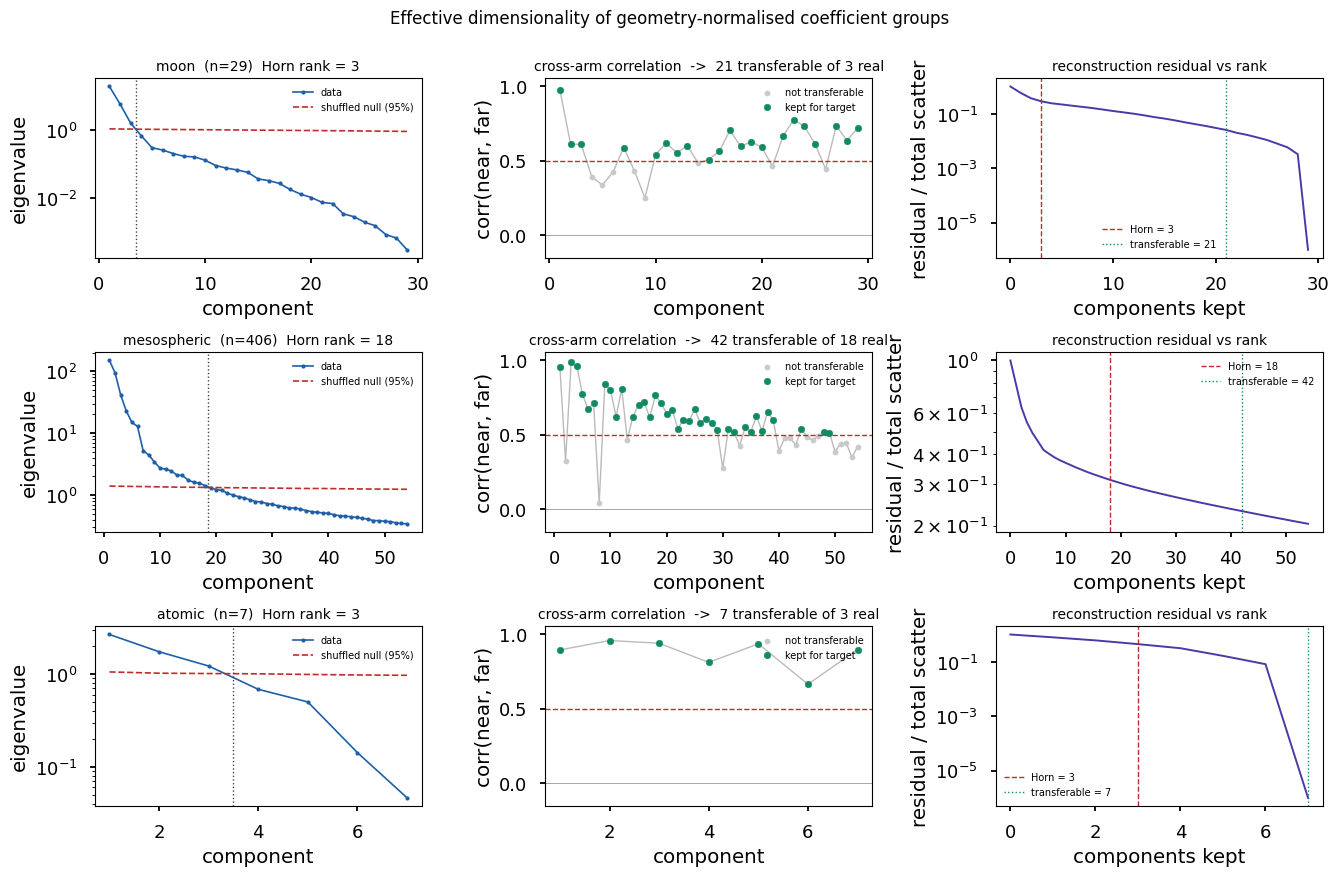


RECOMMENDATION
  coefficient dimension   442  ->  70 (encoder input), 70 (target)
  encoder first layer     175k  ->  33k params (5.4x)
  all group heads         85k  ->  13k params (6.3x)

  1. PROCEED. 6.3x compression of the target space. Fit the basis on training nights only, on geometry-normalised amplitudes in 'asinh' space, per group, pooled over near/far/sci so all three share one basis.
  2. 'moon' has more transferable (21) than single-arm-detectable (3) directions. That is expected where a mode is weak but shared: correlating two arms beats the noise floor of either one alone. Size the encoder input by the larger number.
  3. 'mesospheric' has more transferable (42) than single-arm-detectable (18) directions. That is expected where a mode is weak but shared: correlating two arms beats the noise floor of either one alone. Size the encoder input by the larger number.
  4. 'mesospheric' is markedly more compact under asinh/log than linear (17 vs 26 directions), confirming the 

In [10]:
# Effective dimensionality of the coefficient groups.
#
# The question this answers: how many degrees of freedom do the coefficient
# groups actually carry, and how many of those are *transferable* from the sky
# arms to the science pointing? 402 OH line coefficients are not 402 degrees of
# freedom -- Meinel emission from one layer is set by the vibrational
# populations and a single rotational temperature, so the physical dimension is
# closer to ten.
#
# Three rank criteria are computed, because they answer different questions and
# disagree badly:
#
#   1. VARIANCE FRACTION (reported for reference only, and it is a trap). Past
#      the real structure, the leftover variance is noise spread evenly over
#      hundreds of directions, so "99.9% of variance" tries to capture the
#      noise and returns a rank in the hundreds.
#
#   2. HORN PARALLEL ANALYSIS. Shuffle each coefficient column independently to
#      destroy cross-coefficient correlation while preserving the marginals,
#      recompute the spectrum, and keep components above the shuffled null.
#      This is "how many directions carry structure rather than noise", and it
#      is the right rank for the ENCODER INPUT: denoise the sky arms without
#      discarding real signal.
#
#   3. CROSS-ARM SCORE CORRELATION. Project the near and far arms onto the same
#      basis and correlate their scores per component. A direction that is
#      uncorrelated between two simultaneous lines of sight cannot be predicted
#      at a third one, so including it in the target only adds unpredictable
#      variance. This is the right rank for the TARGET, and it is the number
#      that matters for this model.
#
# Everything runs on geometry-normalised coefficients (zenith-equivalent
# amplitudes), because PCA on raw coefficients would put airmass into PC1 and
# rediscover geometry that is already removed analytically. The basis is fit on
# TRAINING NIGHTS ONLY; cross-arm correlations are evaluated on held-out nights.

import matplotlib.pyplot as plt


def _pca_transform(coef, scale, kind='asinh'):
    """Map coefficients into the space the PCA is performed in.

    asinh is the default: it behaves like log for amplitudes well above the
    scale, which linearises the multiplicative structure (a change in rotational
    temperature is a single linear direction in log space but a curved manifold
    in linear space), while staying finite and monotonic through zero and
    negative values. sqrt is variance-stabilising and is the right space for the
    *loss*, but it is a worse space in which to look for structure.
    """
    coef = np.asarray(coef, dtype=np.float64)
    if kind == 'asinh':
        return np.arcsinh(coef / scale[None, :])
    if kind == 'log':
        return np.log(np.clip(coef / scale[None, :], 1e-3, None))
    if kind == 'sqrt':
        return np.sqrt(np.clip(coef, 0.0, None))
    if kind == 'linear':
        return coef.copy()
    raise ValueError(f'unknown transform {kind!r}')


def _spectrum(x_centered):
    """Eigenvalues of the sample covariance, descending."""
    n = max(x_centered.shape[0] - 1, 1)
    cov = (x_centered.T @ x_centered) / n
    eig = np.linalg.eigvalsh(cov)[::-1]
    return np.clip(eig, 0.0, None)


def _horn_threshold(x_centered, n_permutations, rng, percentile=95.0):
    """Null eigenvalue spectrum from independently shuffled columns."""
    null = []
    for _ in range(int(n_permutations)):
        shuffled = x_centered.copy()
        for j in range(shuffled.shape[1]):
            rng.shuffle(shuffled[:, j])
        null.append(_spectrum(shuffled))
    return np.percentile(np.vstack(null), percentile, axis=0)


def _leading_rank(values, threshold):
    """Number of leading components that stay above threshold."""
    above = np.asarray(values) > np.asarray(threshold)
    if not above.any():
        return 0
    if above.all():
        return int(above.size)
    return int(np.argmax(~above))


def pca_rank_diagnostic(
    filtered,
    group_indices,
    transform='asinh',
    min_group_size=3,
    max_rows_per_arm=4000,
    n_permutations=3,
    xarm_threshold=0.50,
    transform_sensitivity=True,
    sensitivity_rows=2000,
    seed=0,
    make_plot=True,
    verbose=True,
):
    """Per-group effective rank of the coefficient space, with a recommendation."""
    rng = np.random.default_rng(seed)
    coef_names = [str(n) for n in filtered['coef_names']]
    n_coef_total = len(coef_names)

    # --- geometry-normalised (zenith-equivalent) amplitudes -----------------
    geom_kwargs = dict(
        ctx_names=filtered['ctx_names'],
        group_indices=group_indices,
        n_coef=n_coef_total,
        coef_wavelengths_a=filtered.get('coef_wavelengths_a'),
        coef_extinction_k=filtered.get('coef_extinction_k'),
    )
    emissivity = {}
    for arm, ckey, xkey in (('near', 'coef_near', 'ctx_near'),
                            ('far', 'coef_far', 'ctx_far'),
                            ('sci', 'coef_sci', 'ctx_sci')):
        scale = airglow_geometry_scale(filtered[xkey], **geom_kwargs)
        emissivity[arm] = np.asarray(filtered[ckey], dtype=np.float64) / scale

    # --- split by night; basis fit on train, correlations on held-out -------
    n_rows = emissivity['near'].shape[0]
    if 'obstime_mjd' in filtered:
        train_idx, val_idx, test_idx = split_indices_by_night(filtered['obstime_mjd'])
        held_idx = np.concatenate([val_idx, test_idx])
    else:
        if verbose:
            print('WARNING: no obstime_mjd; falling back to a random split, which '
                  'leaks across nights and will overstate the transferable rank.')
        train_idx, val_idx, test_idx = split_indices(n_rows)
        held_idx = np.concatenate([val_idx, test_idx])
    if verbose:
        null_r = 1.0 / np.sqrt(max(min(held_idx.size, max_rows_per_arm), 2))
        print(f'Rows: {n_rows} total, {train_idx.size} train (basis), '
              f'{held_idx.size} held out (cross-arm correlations).')
        print(f'Correlation null level ~1/sqrt(n_held) = {null_r:.3f}; the '
              f'threshold below is {xarm_threshold / max(null_r, 1e-9):.1f} sigma.')
        print(f'Transform: {transform};  Horn permutations: {n_permutations};  '
              f'cross-arm threshold: {xarm_threshold:.2f}')

    def _subsample(idx, cap):
        if idx.size <= cap:
            return idx
        return rng.choice(idx, int(cap), replace=False)

    train_sub = _subsample(train_idx, max_rows_per_arm)
    held_sub = _subsample(held_idx, max_rows_per_arm)

    results = []
    for group_name, gidx in group_indices.items():
        gidx = np.asarray(gidx, dtype=int)
        n_g = int(gidx.size)
        if n_g == 0:
            continue
        if n_g < int(min_group_size):
            results.append({'group': group_name, 'n_coef': n_g, 'skipped': True})
            continue

        # per-coefficient robust scale from training rows
        block_tr = emissivity['near'][np.ix_(train_sub, gidx)]
        positive = np.where(block_tr > 0, block_tr, np.nan)
        scale = np.nanmedian(positive, axis=0)
        scale = np.where(np.isfinite(scale) & (scale > 0), scale, 1.0)

        z = {arm: _pca_transform(emissivity[arm][:, gidx], scale, transform)
             for arm in ('near', 'far', 'sci')}

        pooled_train = np.vstack([z[a][train_sub] for a in ('near', 'far', 'sci')])
        keep = np.isfinite(pooled_train).all(axis=1)
        pooled_train = pooled_train[keep]
        if pooled_train.shape[0] < max(20, n_g // 2):
            results.append({'group': group_name, 'n_coef': n_g, 'skipped': True})
            continue

        # Standardise columns (i.e. work from the correlation matrix). Without
        # this, Horn's null inherits the column variances, and those span a
        # huge range here -- a high-excitation OH line is far more sensitive to
        # rotational temperature than a low-excitation one -- so the shuffled
        # null acquires large leading eigenvalues and the method badly
        # under-detects. It is also the space the pipeline works in, since a
        # per-coefficient robust scaler is applied before the network.
        mean_vec = pooled_train.mean(axis=0)
        sd_vec = pooled_train.std(axis=0)
        sd_vec = np.where(sd_vec > 1e-12, sd_vec, 1.0)
        centered = (pooled_train - mean_vec) / sd_vec
        eig = _spectrum(centered)
        var_frac = eig / max(eig.sum(), 1e-300)
        cum = np.cumsum(var_frac)

        null_thresh = _horn_threshold(centered, n_permutations, rng)
        rank_horn = _leading_rank(eig, null_thresh)

        # basis vectors
        cov = (centered.T @ centered) / max(centered.shape[0] - 1, 1)
        evals, evecs = np.linalg.eigh(cov)
        order = np.argsort(evals)[::-1]
        basis = evecs[:, order]

        # cross-arm score correlation on held-out rows
        scores_near = ((z['near'][held_sub] - mean_vec) / sd_vec) @ basis
        scores_far = ((z['far'][held_sub] - mean_vec) / sd_vec) @ basis
        finite = np.isfinite(scores_near).all(axis=1) & np.isfinite(scores_far).all(axis=1)
        scores_near, scores_far = scores_near[finite], scores_far[finite]
        xarm = np.full(n_g, np.nan)
        if scores_near.shape[0] > 10:
            a = scores_near - scores_near.mean(axis=0)
            b = scores_far - scores_far.mean(axis=0)
            denom = np.sqrt((a * a).sum(axis=0) * (b * b).sum(axis=0))
            xarm = np.where(denom > 0, (a * b).sum(axis=0) / np.maximum(denom, 1e-300), 0.0)
        # COUNT, not a leading block. PCA orders components by variance, not by
        # transferability, so a shared mode can sit behind an arm-private one.
        # The transferable subspace is therefore selected by correlation, not by
        # variance rank -- which also means the target basis is a *chosen subset*
        # of components rather than the first k.
        xarm_keep = np.flatnonzero(xarm > xarm_threshold)
        rank_xarm = int(xarm_keep.size)
        rank_xarm50 = int(np.sum(xarm > 0.50))

        resid_frac = np.sqrt(np.clip(1.0 - np.concatenate([[0.0], cum]), 0.0, None))

        sensitivity = {}
        if transform_sensitivity:
            sens_rows = _subsample(train_sub, sensitivity_rows)
            for kind in ('asinh', 'log', 'sqrt', 'linear'):
                zz = np.vstack([_pca_transform(emissivity[a][np.ix_(sens_rows, gidx)],
                                               scale, kind)
                                for a in ('near', 'far', 'sci')])
                zz = zz[np.isfinite(zz).all(axis=1)]
                if zz.shape[0] < 20:
                    continue
                zsd = zz.std(axis=0)
                zc = (zz - zz.mean(axis=0)) / np.where(zsd > 1e-12, zsd, 1.0)
                sensitivity[kind] = _leading_rank(
                    _spectrum(zc), _horn_threshold(zc, 1, rng))

        results.append({
            'group': group_name, 'n_coef': n_g, 'skipped': False,
            'xarm_keep': xarm_keep,
            'eig': eig, 'var_frac': var_frac, 'cum': cum,
            'null_thresh': null_thresh, 'xarm': xarm, 'resid_frac': resid_frac,
            'rank_horn': rank_horn, 'rank_xarm': rank_xarm, 'rank_xarm50': rank_xarm50,
            'rank_var90': int(np.searchsorted(cum, 0.90)) + 1,
            'rank_var99': int(np.searchsorted(cum, 0.99)) + 1,
            'rank_var999': int(np.searchsorted(cum, 0.999)) + 1,
            'sensitivity': sensitivity,
        })

    def _fmt(v):
        return '-' if v is None or (isinstance(v, float) and not np.isfinite(v)) else int(v)

    table = pd.DataFrame([
        {'group': r['group'], 'n_coef': r['n_coef'],
         'var90': _fmt(r.get('rank_var90')), 'var99': _fmt(r.get('rank_var99')),
         'var99.9': _fmt(r.get('rank_var999')), 'horn': _fmt(r.get('rank_horn')),
         'transferable': _fmt(r.get('rank_xarm')), 'xarm>0.5': _fmt(r.get('rank_xarm50')),
         'input_rank': r['n_coef'] if r['skipped']
                       else max(r['rank_horn'], r['rank_xarm']),
         'target_rank': r['n_coef'] if r['skipped'] else r['rank_xarm'],
         'compressed': not r['skipped']}
        for r in results
    ])

    if verbose and len(table):
        print()
        print('Effective rank by group')
        print(table.to_string(index=False))
        for r in results:
            if r.get('sensitivity'):
                s = r['sensitivity']
                print(f"  {r['group']:<14s} Horn rank by transform: "
                      + '  '.join(f'{k}={v}' for k, v in s.items()))

    if make_plot:
        plotted = [r for r in results if not r['skipped']]
        if plotted:
            n = len(plotted)
            fig, axes = plt.subplots(n, 3, figsize=(13.5, 2.9 * n), squeeze=False)
            for row, r in enumerate(plotted):
                k = np.arange(1, r['n_coef'] + 1)
                show = min(r['n_coef'], max(3 * max(r['rank_horn'], 4), 30))

                ax = axes[row][0]
                ax.semilogy(k[:show], np.clip(r['eig'][:show], 1e-300, None),
                            'o-', ms=3, lw=1.2, color='#1f5fa8', label='data')
                ax.semilogy(k[:show], np.clip(r['null_thresh'][:show], 1e-300, None),
                            '--', lw=1.2, color='#c02c2c', label='shuffled null (95%)')
                ax.axvline(r['rank_horn'] + 0.5, color='#444', lw=1.0, ls=':')
                ax.set_title(f"{r['group']}  (n={r['n_coef']})  Horn rank = {r['rank_horn']}",
                             fontsize=10)
                ax.set_xlabel('component'); ax.set_ylabel('eigenvalue')
                ax.legend(fontsize=7, frameon=False)

                ax = axes[row][1]
                ax.plot(k[:show], r['xarm'][:show], '-', lw=1.0, color='#bbb', zorder=1)
                sel = r['xarm_keep'][r['xarm_keep'] < show]
                rej = np.setdiff1d(np.arange(show), sel)
                ax.scatter(rej + 1, r['xarm'][rej], s=14, color='#c9c9c9',
                           zorder=2, label='not transferable')
                ax.scatter(sel + 1, r['xarm'][sel], s=22, color='#0f8a63',
                           zorder=3, label='kept for target')
                ax.axhline(xarm_threshold, color='#c02c2c', ls='--', lw=1.0)
                ax.axhline(0.0, color='#999', lw=0.6)
                ax.set_ylim(-0.15, 1.05)
                ax.set_title(f"cross-arm correlation  ->  {r['rank_xarm']} transferable "
                             f"of {r['rank_horn']} real", fontsize=10)
                ax.legend(fontsize=7, frameon=False, loc='upper right')
                ax.set_xlabel('component'); ax.set_ylabel('corr(near, far)')

                ax = axes[row][2]
                rr = np.arange(r['resid_frac'].size)
                ax.semilogy(rr[:show + 1], np.clip(r['resid_frac'][:show + 1], 1e-6, None),
                            '-', lw=1.4, color='#4a3aa7')
                ax.axvline(r['rank_horn'], color='#c02c2c', lw=1.0, ls='--',
                           label=f"Horn = {r['rank_horn']}")
                ax.axvline(r['rank_xarm'], color='#0f8a63', lw=1.0, ls=':',
                           label=f"transferable = {r['rank_xarm']}")
                ax.set_title('reconstruction residual vs rank', fontsize=10)
                ax.set_xlabel('components kept')
                ax.set_ylabel('residual / total scatter')
                ax.legend(fontsize=7, frameon=False)
            fig.suptitle('Effective dimensionality of geometry-normalised coefficient groups',
                         fontsize=12, y=1.002)
            fig.tight_layout()
            plt.show()

    # ---------------------------- recommendation ---------------------------
    if verbose and len(table):
        input_dim = int(table['input_rank'].sum())
        target_dim = int(table['target_rank'].sum())
        n_ctx = len(filtered['ctx_names'])
        enc0 = 384
        head_dim = 192
        enc_before = (n_coef_total + n_ctx) * enc0
        enc_after = (input_dim + n_ctx) * enc0
        head_before = head_dim * n_coef_total
        head_after = head_dim * target_dim

        def _percoef_weight(sizes):
            return {g: (1.0 / np.sqrt(max(n, 1))) / max(n, 1) for g, n in sizes.items()}

        sizes_before = dict(zip(table['group'], table['n_coef']))
        sizes_after = dict(zip(table['group'], table['target_rank']))
        wb, wa = _percoef_weight(sizes_before), _percoef_weight(sizes_after)
        ratio_before = ratio_after = np.nan
        if 'continuum' in wb and 'mesospheric' in wb:
            ratio_before = wb['continuum'] / wb['mesospheric']
            ratio_after = wa['continuum'] / wa['mesospheric']

        print()
        print('=' * 78)
        print('RECOMMENDATION')
        print('=' * 78)
        print(f'  coefficient dimension   {n_coef_total}  ->  {input_dim} (encoder input), '
              f'{target_dim} (target)')
        print(f'  encoder first layer     {enc_before/1e3:.0f}k  ->  {enc_after/1e3:.0f}k params '
              f'({enc_before/max(enc_after,1):.1f}x)')
        print(f'  all group heads         {head_before/1e3:.0f}k  ->  {head_after/1e3:.0f}k params '
              f'({head_before/max(head_after,1):.1f}x)')
        if np.isfinite(ratio_before):
            print(f'  per-coefficient weight ratio continuum:mesospheric  '
                  f'{ratio_before:.0f}x  ->  {ratio_after:.0f}x')
        print()

        compression = n_coef_total / max(target_dim, 1)
        verdict = []
        if compression >= 3.0:
            verdict.append(
                f'PROCEED. {compression:.1f}x compression of the target space. Fit the basis '
                f'on training nights only, on geometry-normalised amplitudes in {transform!r} '
                f'space, per group, pooled over near/far/sci so all three share one basis.')
        else:
            verdict.append(
                f'DO NOT BOTHER. Only {compression:.1f}x compression; the coefficients are '
                f'already close to independent and PCA would buy little while costing '
                f'interpretability and the non-negativity constraint.')

        for r in results:
            if r['skipped']:
                continue
            if r['rank_xarm'] > r['rank_horn']:
                verdict.append(
                    f"{r['group']!r} has more transferable ({r['rank_xarm']}) than "
                    f"single-arm-detectable ({r['rank_horn']}) directions. That is expected "
                    f"where a mode is weak but shared: correlating two arms beats the noise "
                    f"floor of either one alone. Size the encoder input by the larger number.")
            if r['rank_horn'] >= 0.5 * r['n_coef']:
                verdict.append(
                    f"Leave {r['group']!r} uncompressed: Horn rank {r['rank_horn']} is over half "
                    f"of its {r['n_coef']} coefficients, so there is little redundancy.")
            elif r['rank_xarm'] <= 0.35 * r['rank_horn']:
                verdict.append(
                    f"{r['group']!r} carries {r['rank_horn']} real directions but only "
                    f"{r['rank_xarm']} are correlated between the two sky arms. The rest is "
                    f"structure the sky telescopes cannot transfer to the science pointing -- "
                    f"that gap is an information ceiling, not a modelling failure, and it "
                    f"should agree with the structure function for this group.")
            if r['sensitivity'] and 'asinh' in r['sensitivity'] and 'linear' in r['sensitivity']:
                if r['sensitivity']['linear'] > 1.5 * r['sensitivity']['asinh']:
                    verdict.append(
                        f"{r['group']!r} is markedly more compact under asinh/log than linear "
                        f"({r['sensitivity']['asinh']} vs {r['sensitivity']['linear']} "
                        f"directions), confirming the variability is multiplicative. Do the "
                        f"projection in that space even though the loss stays in sqrt space.")

        verdict.append(
            'Use the Horn rank for the encoder input and the cross-arm count for the target: '
            'a direction uncorrelated between two simultaneous lines of sight cannot be '
            'predicted at a third, so keeping it in the target only adds unpredictable '
            'variance. Select the target components BY CORRELATION, not by variance order -- '
            'PCA sorts by variance and a transferable mode can sit behind an arm-private one. '
            'The retained indices are in the returned results under "xarm_keep".')
        for r in results:
            if r['skipped'] or r['rank_xarm'] == 0:
                continue
            keep = r['xarm_keep']
            contiguous = np.array_equal(keep, np.arange(keep.size))
            if not contiguous:
                verdict.append(
                    f"{r['group']!r}: the transferable components are not the leading block "
                    f"(indices {[int(v) for v in keep[:12]]}"
                    f"{' ...' if keep.size > 12 else ''}), so "
                    f"truncating at the first k would keep unpredictable directions and "
                    f"discard predictable ones.")
        verdict.append(
            'Two consequences to decide deliberately: Softplus non-negativity is lost in score '
            'space (predict scores linearly and clip after reconstruction, or accept the small '
            'negatives the decomposition already contains), and PCA truncation on the moon '
            'spline is itself a smoothness prior, so moon_smooth_lambda becomes redundant.')
        verdict.append(
            'Reconstruction residual in this basis doubles as an out-of-distribution flag on '
            'nights whose conditions fall outside the training span.')

        for i, line in enumerate(verdict, 1):
            print(f'  {i}. ' + line.replace('\n', '\n     '))
        print('=' * 78)

    return table, results


pca_rank_table, pca_rank_results = pca_rank_diagnostic(
    filtered_triplet,
    _build_group_indices(filtered_triplet['coef_names']),
    transform='asinh',
    verbose=True,
    make_plot=True,
)


## Symmetric Dual-Encoder Group-Head Model

Key design choices in this implementation:
1. Shared near/far encoder weights for symmetry and sample efficiency.
2. Fusion vector uses:
   - $e_{mean} = 0.5(e_{near} + e_{far})$
   - $e_{diff} = e_{near} - e_{far}$
   - $|e_{diff}|$
3. Context branch encodes science-context only, now including folded time features and van Rhijn shell factors.
4. Group-specific heads map fused representation into layer-aware coefficient groups rather than a single flat atomic bucket.

**Note.** `DualEncoderGroupHeadMLP` below is the parent architecture. What
the notebook actually trains is `DualEncoderGroupHeadMLPCompressed` (defined
two cells down, together with the compressor fit), which reuses this
architecture verbatim on a per-group compressed coefficient space and emits
signed linear head outputs. See §5.5 in the methods cell above for the
compression pipeline and the empirical argument for switching to it.


In [11]:
# Symmetric dual-encoder group-head MLP for same-time SCI coefficient prediction
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset


class DualEncoderGroupHeadMLP(nn.Module):
    def __init__(self, n_coef, n_ctx, group_indices, ctx_names=None, encoder_dims=(384, 192), ctx_dims=(64,), trunk_dims=(256, 128), head_dim=128,
                 drop_vanrhijn_from_context=False):
        super().__init__()
        self.group_indices = group_indices
        self.ctx_names = [str(n).strip().lower() for n in ctx_names] if ctx_names is not None else None

        # Airglow geometry is divided out analytically before anything reaches
        # this model, so the vanrhijn_* columns are redundant FOR THE AIRGLOW
        # GROUPS.  They are not redundant for the moon and continuum groups,
        # which receive no analytic correction and must learn their airmass
        # dependence from context -- and the encoders are shared across groups,
        # so dropping the columns takes those smooth non-linear functions of
        # altitude away from every head.  Default is therefore to keep them.
        if self.ctx_names is not None and bool(drop_vanrhijn_from_context):
            self.ctx_keep_idx = [i for i, name in enumerate(self.ctx_names) if name not in VAN_RHIJN_FEATURES]
        elif self.ctx_names is not None:
            self.ctx_keep_idx = list(range(len(self.ctx_names)))
        else:
            self.ctx_keep_idx = list(range(int(n_ctx)))

        self.ctx_dim = len(self.ctx_keep_idx)
        self.sky_encoder = self._make_mlp(n_coef + self.ctx_dim, encoder_dims)
        sky_embed_dim = int(encoder_dims[-1])

        self.ctx_encoder = self._make_mlp(self.ctx_dim, ctx_dims)
        ctx_embed_dim = int(ctx_dims[-1]) if len(ctx_dims) > 0 else self.ctx_dim

        fusion_in = 3 * sky_embed_dim + ctx_embed_dim
        self.trunk = self._make_mlp(fusion_in, trunk_dims)
        trunk_out = int(trunk_dims[-1]) if len(trunk_dims) > 0 else fusion_in

        self.heads = nn.ModuleDict({
            g: nn.Sequential(
                nn.Linear(trunk_out, int(head_dim)),
                nn.GELU(),
                nn.Linear(int(head_dim), len(idx)),
            )
            for g, idx in group_indices.items()
        })

    @staticmethod
    def _make_mlp(in_dim, dims):
        layers = []
        d0 = int(in_dim)
        for d1 in dims:
            d1 = int(d1)
            layers += [nn.Linear(d0, d1), nn.LayerNorm(d1), nn.GELU()]
            d0 = d1
        return nn.Sequential(*layers) if layers else nn.Identity()

    def _select_ctx(self, ctx):
        if self.ctx_names is None or len(self.ctx_keep_idx) == ctx.shape[1]:
            return ctx
        if len(self.ctx_keep_idx) == 0:
            return ctx[:, :0]
        return ctx[:, self.ctx_keep_idx]

    def forward(self, near_coef, far_coef, near_ctx, far_ctx, sci_ctx):
        near_ctx_model = self._select_ctx(near_ctx)
        far_ctx_model = self._select_ctx(far_ctx)
        sci_ctx_model = self._select_ctx(sci_ctx)

        e_near = self.sky_encoder(torch.cat([near_coef, near_ctx_model], dim=1))
        e_far = self.sky_encoder(torch.cat([far_coef, far_ctx_model], dim=1))
        e_mean = 0.5 * (e_near + e_far)
        e_diff = e_near - e_far
        e_absdiff = torch.abs(e_diff)
        e_ctx = self.ctx_encoder(sci_ctx_model)

        z = torch.cat([e_mean, e_diff, e_absdiff, e_ctx], dim=1)
        h = self.trunk(z)
        # Outputs are intrinsic emissivities in model space; the caller
        # multiplies by airglow_geometry_scale(ctx_sci) to get observed
        # amplitudes at the science line of sight.
        return {g: F.softplus(head(h)) for g, head in self.heads.items()}

def _group_loss(pred_dict, y_true, group_idx_t, moon_smooth_lambda=0.0, continuum_group_weight=1.0):
    loss = torch.tensor(0.0, device=y_true.device)

    for g, idx_t in group_idx_t.items():
        w = 1.0 / np.sqrt(max(int(idx_t.numel()), 1))
        if g == 'continuum':
            w = w * float(continuum_group_weight)
        loss = loss + float(w) * F.smooth_l1_loss(pred_dict[g], y_true[:, idx_t])

    if moon_smooth_lambda > 0 and 'moon' in pred_dict and pred_dict['moon'].shape[1] >= 3:
        moon = pred_dict['moon']
        d2 = moon[:, 2:] - 2.0 * moon[:, 1:-1] + moon[:, :-2]
        loss = loss + float(moon_smooth_lambda) * torch.mean(d2 * d2)

    return loss / max(len(group_idx_t), 1)


def _group_loss_breakdown(pred_dict, y_true, group_idx_t):
    """Unweighted per-group SmoothL1, for diagnosing which head is losing out.

    The weighted objective mixes groups whose effective per-coefficient weights
    differ by orders of magnitude (w_g = 1/sqrt(n_g) means a 2-coefficient
    continuum group outweighs a 400-coefficient OH group per coefficient by
    a factor of thousands). Tracking the raw per-group loss separates 'this
    head is under-trained' from 'this head is being traded away'.
    """
    return {g: float(F.smooth_l1_loss(pred_dict[g], y_true[:, idx_t]).item())
            for g, idx_t in group_idx_t.items()}


def train_coeff_prediction_group_mlp(
    filtered,
    n_epochs=120,
    batch_size=256,
    lr=6e-4,
    encoder_dims=(384, 192),
    ctx_dims=(64,),
    trunk_dims=(256, 128),
    head_dim=128,
    weight_decay=1e-4,
    grad_clip=1.0,
    patience=20,
    split_mode='night_grouped',
    seed=42,
    moon_smooth_lambda=0.0,
    continuum_group_weight=1.0,
    coef_wavelengths_a=None,
    coef_extinction_k=None,
    drop_vanrhijn_from_context=False,
):
    _set_reproducibility(seed)

    coef_near = np.asarray(filtered['coef_near'], dtype=np.float32)
    coef_far = np.asarray(filtered['coef_far'], dtype=np.float32)
    coef_sci = np.asarray(filtered['coef_sci'], dtype=np.float32)
    ctx_near = np.asarray(filtered['ctx_near'], dtype=np.float32)
    ctx_far = np.asarray(filtered['ctx_far'], dtype=np.float32)
    ctx_sci = np.asarray(filtered['ctx_sci'], dtype=np.float32)

    n = coef_near.shape[0]
    split_mode_norm = str(split_mode).strip().lower()
    if split_mode_norm in ('time_sorted', 'sorted_time', 'time'):
        if 'obstime_mjd' not in filtered:
            raise KeyError("filtered dataset is missing 'obstime_mjd' required for time-sorted split")
        train_idx, val_idx, test_idx = split_indices_by_sorted_time(filtered['obstime_mjd'])
        print('Using time-sorted split for train/val/test.')
    elif split_mode_norm in ('night_grouped', 'night', 'nightly', 'night_split'):
        if 'obstime_mjd' not in filtered:
            raise KeyError("filtered dataset is missing 'obstime_mjd' required for night-grouped split")
        train_idx, val_idx, test_idx = split_indices_by_night(filtered['obstime_mjd'], seed=seed)
        print('Using night-grouped split for train/val/test.')
    elif split_mode_norm == 'random':
        train_idx, val_idx, test_idx = split_indices(n, seed=seed)
        print('Using random split for train/val/test.')
    else:
        raise ValueError(f"Unknown split_mode={split_mode!r}; expected 'night_grouped', 'time_sorted', or 'random'")

    # --- geometry: divide out van Rhijn * extinction in PHYSICAL units ------
    # Must happen before _coef_to_model_space (sqrt) and before RobustScaler,
    # because neither commutes with a division by the geometry factor.
    group_indices = _build_group_indices(filtered['coef_names'])

    if coef_wavelengths_a is None:
        coef_wavelengths_a = filtered.get('coef_wavelengths_a')
    coef_wavelengths_a, wavelength_source = resolve_coef_wavelengths_a(
        filtered['coef_names'],
        group_indices=group_indices,
        input_wavelengths_a=coef_wavelengths_a,
        basis_wavelengths_a=None,
        verbose=True,
    )

    if coef_extinction_k is None:
        coef_extinction_k = filtered.get('coef_extinction_k')
    if coef_extinction_k is None:
        # no fitted values available: fall back to the generic stellar curve
        coef_extinction_k, extinction_source = resolve_coef_extinction_k(
            filtered['coef_names'], coef_wavelengths_a, group_indices,
            fit_table=None, clip_to_generic=False, verbose=False)
    else:
        coef_extinction_k = np.asarray(coef_extinction_k, dtype=np.float64)
        extinction_source = ['supplied'] * len(filtered['coef_names'])

    geom_kwargs = dict(
        ctx_names=filtered['ctx_names'],
        group_indices=group_indices,
        n_coef=coef_near.shape[1],
        coef_wavelengths_a=coef_wavelengths_a,
        coef_extinction_k=coef_extinction_k,
    )
    scale_near = airglow_geometry_scale(ctx_near, **geom_kwargs)
    scale_far = airglow_geometry_scale(ctx_far, **geom_kwargs)
    scale_sci = airglow_geometry_scale(ctx_sci, **geom_kwargs)

    airglow_cols = np.flatnonzero(np.any(scale_sci != 1.0, axis=0))
    if airglow_cols.size:
        print(f'Geometry normalisation applied to {airglow_cols.size} airglow '
              f'coefficients; V*ext at SCI spans '
              f'{scale_sci[:, airglow_cols].min():.3f}..{scale_sci[:, airglow_cols].max():.3f}')
    else:
        print('WARNING: geometry normalisation matched no coefficients.')

    near_model = _coef_to_model_space(coef_near / scale_near)
    far_model = _coef_to_model_space(coef_far / scale_far)
    sci_model = _coef_to_model_space(coef_sci / scale_sci)

    coef_scaler = RobustScaler().fit(np.vstack([near_model[train_idx], far_model[train_idx], sci_model[train_idx]]))
    ctx_scaler = RobustScaler().fit(np.vstack([ctx_near[train_idx], ctx_far[train_idx], ctx_sci[train_idx]]))

    near_n = np.clip(coef_scaler.transform(near_model), -25.0, 25.0).astype(np.float32)
    far_n = np.clip(coef_scaler.transform(far_model), -25.0, 25.0).astype(np.float32)
    sci_n = np.clip(coef_scaler.transform(sci_model), -25.0, 25.0).astype(np.float32)
    ctx_near_n = np.clip(ctx_scaler.transform(ctx_near), -25.0, 25.0).astype(np.float32)
    ctx_far_n = np.clip(ctx_scaler.transform(ctx_far), -25.0, 25.0).astype(np.float32)
    sci_ctx_n = np.clip(ctx_scaler.transform(ctx_sci), -25.0, 25.0).astype(np.float32)

    tr_loader = DataLoader(
        TensorDataset(
            torch.from_numpy(near_n[train_idx]),
            torch.from_numpy(far_n[train_idx]),
            torch.from_numpy(ctx_near_n[train_idx]),
            torch.from_numpy(ctx_far_n[train_idx]),
            torch.from_numpy(sci_ctx_n[train_idx]),
            torch.from_numpy(sci_n[train_idx]),
        ),
        batch_size=int(batch_size),
        shuffle=True,
    )
    va_loader = DataLoader(
        TensorDataset(
            torch.from_numpy(near_n[val_idx]),
            torch.from_numpy(far_n[val_idx]),
            torch.from_numpy(ctx_near_n[val_idx]),
            torch.from_numpy(ctx_far_n[val_idx]),
            torch.from_numpy(sci_ctx_n[val_idx]),
            torch.from_numpy(sci_n[val_idx]),
        ),
        batch_size=512,
        shuffle=False,
    )

    if torch.cuda.is_available():
        device = 'cuda'
    elif getattr(torch.backends, 'mps', None) is not None and torch.backends.mps.is_available():
        device = 'mps'
    else:
        device = 'cpu'

    group_idx_t = {g: torch.as_tensor(idx, dtype=torch.long, device=device) for g, idx in group_indices.items()}

    model = DualEncoderGroupHeadMLP(
        n_coef=near_n.shape[1],
        n_ctx=sci_ctx_n.shape[1],
        group_indices=group_indices,
        ctx_names=[str(x) for x in filtered['ctx_names']],
        encoder_dims=tuple(int(v) for v in encoder_dims),
        ctx_dims=tuple(int(v) for v in ctx_dims),
        trunk_dims=tuple(int(v) for v in trunk_dims),
        head_dim=int(head_dim),
        drop_vanrhijn_from_context=bool(drop_vanrhijn_from_context),
    ).to(device)

    opt = torch.optim.AdamW(model.parameters(), lr=float(lr), weight_decay=float(weight_decay))

    history = []
    best_val = np.inf
    best_epoch = -1
    best_state = None
    stale = 0

    for ep in range(1, int(n_epochs) + 1):
        model.train()
        tr_loss = 0.0
        tr_n = 0

        for near_b, far_b, near_ctx_b, far_ctx_b, ctx_b, yb in tr_loader:
            near_b = near_b.to(device)
            far_b = far_b.to(device)
            near_ctx_b = near_ctx_b.to(device)
            far_ctx_b = far_ctx_b.to(device)
            ctx_b = ctx_b.to(device)
            yb = yb.to(device)

            pred = model(near_b, far_b, near_ctx_b, far_ctx_b, ctx_b)
            loss = _group_loss(pred, yb, group_idx_t, moon_smooth_lambda=float(moon_smooth_lambda), continuum_group_weight=float(continuum_group_weight))
            if not torch.isfinite(loss):
                continue

            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), float(grad_clip))
            opt.step()

            tr_loss += float(loss.item())
            tr_n += 1

        model.eval()
        va_loss = 0.0
        va_n = 0
        va_group = {g: 0.0 for g in group_idx_t}
        with torch.no_grad():
            for near_b, far_b, near_ctx_b, far_ctx_b, ctx_b, yb in va_loader:
                near_b = near_b.to(device)
                far_b = far_b.to(device)
                near_ctx_b = near_ctx_b.to(device)
                far_ctx_b = far_ctx_b.to(device)
                ctx_b = ctx_b.to(device)
                yb = yb.to(device)
                pred = model(near_b, far_b, near_ctx_b, far_ctx_b, ctx_b)
                loss = _group_loss(pred, yb, group_idx_t, moon_smooth_lambda=float(moon_smooth_lambda), continuum_group_weight=float(continuum_group_weight))
                if torch.isfinite(loss):
                    va_loss += float(loss.item())
                    va_n += 1
                    for g, v in _group_loss_breakdown(pred, yb, group_idx_t).items():
                        va_group[g] += v

        tr_mean = tr_loss / max(tr_n, 1)
        va_mean = va_loss / max(va_n, 1)
        history.append({'epoch': ep, 'train_loss': tr_mean, 'val_loss': va_mean,
                        **{f'val_{g}': va_group[g] / max(va_n, 1) for g in va_group}})

        if va_mean < best_val:
            best_val = va_mean
            best_epoch = ep
            best_state = copy.deepcopy(model.state_dict())
            stale = 0
        else:
            stale += 1

        if ep == 1 or ep % 10 == 0 or ep == int(n_epochs):
            print(f"[dual-group-mlp] epoch={ep:03d} train={tr_mean:.6f} val={va_mean:.6f}")

        if stale >= int(patience):
            print(f"Early stopping at epoch {ep} (patience={patience})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    if history:
        best_row = history[min(range(len(history)),
                               key=lambda i: history[i]['val_loss'])]
        parts = [f"{g.replace('val_', '')}={v:.5f}"
                 for g, v in best_row.items() if g.startswith('val_') and g != 'val_loss']
        print('Per-group validation loss at best epoch (unweighted): ' + '  '.join(parts))
        if best_epoch >= int(n_epochs):
            print(f'NOTE: best epoch is the last epoch ({best_epoch}/{n_epochs}); '
                  f'training was cut short rather than converged.')

    return {
        'model': model,
        'device': device,
        'coef_scaler': coef_scaler,
        'ctx_scaler': ctx_scaler,
        'group_indices': group_indices,
        'history': history,
        'best_val_loss': float(best_val),
        'best_epoch': int(best_epoch),
        'train_idx': np.asarray(train_idx, dtype=int),
        'val_idx': np.asarray(val_idx, dtype=int),
        'test_idx': np.asarray(test_idx, dtype=int),
        'coef_names': [str(x) for x in filtered['coef_names']],
        'ctx_names': [str(x) for x in filtered['ctx_names']],
        'coef_wavelengths_a': np.asarray(coef_wavelengths_a, dtype=np.float64),
        'wavelength_source': list(wavelength_source),
        'coef_extinction_k': np.asarray(coef_extinction_k, dtype=np.float64),
        'extinction_source': list(extinction_source),
        'moon_smooth_lambda': float(moon_smooth_lambda),
        'continuum_group_weight': float(continuum_group_weight),
        'config': {
            'n_epochs': int(n_epochs),
            'batch_size': int(batch_size),
            'lr': float(lr),
            'encoder_dims': tuple(int(v) for v in encoder_dims),
            'ctx_dims': tuple(int(v) for v in ctx_dims),
            'trunk_dims': tuple(int(v) for v in trunk_dims),
            'head_dim': int(head_dim),
            'weight_decay': float(weight_decay),
            'patience': int(patience),
            'split_mode': split_mode_norm,
            'drop_vanrhijn_from_context': bool(drop_vanrhijn_from_context),
            'moon_smooth_lambda': float(moon_smooth_lambda),
            'continuum_group_weight': float(continuum_group_weight),
        },
    }


def predict_sci_coefficients_group_mlp(artifacts, coef_near_phys, coef_far_phys, ctx_near_phys, ctx_far_phys, ctx_sci_phys):
    model = artifacts['model']
    device = artifacts['device']
    coef_scaler = artifacts['coef_scaler']
    ctx_scaler = artifacts['ctx_scaler']

    n_coef = len(artifacts['coef_names'])
    geom_kwargs = {
        'ctx_names': artifacts['ctx_names'],
        'group_indices': artifacts['group_indices'],
        'n_coef': n_coef,
        'coef_wavelengths_a': artifacts.get('coef_wavelengths_a'),
        'coef_extinction_k': artifacts.get('coef_extinction_k'),
    }
    scale_near = airglow_geometry_scale(np.asarray(ctx_near_phys, dtype=np.float64), **geom_kwargs)
    scale_far = airglow_geometry_scale(np.asarray(ctx_far_phys, dtype=np.float64), **geom_kwargs)
    scale_sci = airglow_geometry_scale(np.asarray(ctx_sci_phys, dtype=np.float64), **geom_kwargs)

    near_em = np.asarray(coef_near_phys, dtype=np.float64) / scale_near
    far_em = np.asarray(coef_far_phys, dtype=np.float64) / scale_far

    near_n = np.clip(coef_scaler.transform(_coef_to_model_space(near_em.astype(np.float32))), -25.0, 25.0).astype(np.float32)
    far_n = np.clip(coef_scaler.transform(_coef_to_model_space(far_em.astype(np.float32))), -25.0, 25.0).astype(np.float32)
    near_ctx_n = np.clip(ctx_scaler.transform(np.asarray(ctx_near_phys, dtype=np.float32)), -25.0, 25.0).astype(np.float32)
    far_ctx_n = np.clip(ctx_scaler.transform(np.asarray(ctx_far_phys, dtype=np.float32)), -25.0, 25.0).astype(np.float32)
    sci_ctx_n = np.clip(ctx_scaler.transform(np.asarray(ctx_sci_phys, dtype=np.float32)), -25.0, 25.0).astype(np.float32)

    with torch.no_grad():
        pred_dict = model(
            torch.from_numpy(near_n).to(device),
            torch.from_numpy(far_n).to(device),
            torch.from_numpy(near_ctx_n).to(device),
            torch.from_numpy(far_ctx_n).to(device),
            torch.from_numpy(sci_ctx_n).to(device),
        )

    n_rows = near_n.shape[0]
    out = np.zeros((n_rows, n_coef), dtype=np.float32)
    for g, idx in artifacts['group_indices'].items():
        out[:, idx] = pred_dict[g].detach().cpu().numpy().astype(np.float32)

    # Model predicts intrinsic emissivity; restore observed amplitudes at the
    # science line of sight.
    coef_emissivity = _coef_from_model_space(coef_scaler.inverse_transform(out))
    return (coef_emissivity.astype(np.float64) * scale_sci).astype(np.float32)

In [17]:
# ============================================================================
# Per-group coefficient compression -- points 2, 3, 4 of the diagnostic.
#
#   2. Compress OH ("mesospheric") in ASINH space, moon in LINEAR space.
#      Atomic / continuum / ionospheric / other pass through as sqrt "identity
#      compressors" so the score-space pipeline is uniform even where nothing
#      is actually compressed.
#   3. Select KEPT COMPONENTS BY CROSS-ARM CORRELATION > 0.5 on held-out
#      nights.  This is NOT a variance-order truncation; the retained indices
#      are the target subspace flagged by Cell 13's `xarm_keep` at
#      xarm_threshold = 0.5.
#   4. The encoder input dimension shrinks by the same factor as the target,
#      because near/far/sci all pass through the same per-group basis.
#
# The compressor for each group is:
#     em (n_g)  -->  z = transform(em)          (asinh / linear / sqrt)
#     z         -->  z_std = (z - mean) / sd    (standardise columns)
#     z_std     -->  scores = z_std @ basis     (basis = PCA of correlation)
#     scores    -->  scores[:, kept]            (r_xarm > threshold on held-out)
# and the inverse puts zeros in dropped-component slots.  Non-negativity is
# recovered by clipping the emissivity after the inverse transform (also, the
# sqrt "identity" branch inverts via square which is non-negative by design).
# ============================================================================

COMPRESSION_XARM_THRESHOLD = 0.5

COMPRESSION_TRANSFORM_BY_GROUP = {
    'mesospheric': 'asinh',
    'moon': 'linear',
    'atomic': 'sqrt',
    'continuum': 'sqrt',
    'ionospheric': 'sqrt',
    'other': 'sqrt',
}

COMPRESSION_USE_PCA_BY_GROUP = {
    'mesospheric': True,
    'moon': True,
    'atomic': False,
    'continuum': False,
    'ionospheric': False,
    'other': False,
}


def _score_forward(x, kind, per_col_scale):
    x = np.asarray(x, dtype=np.float64)
    if kind == 'linear':
        return x / per_col_scale[None, :]
    if kind == 'sqrt':
        return np.sqrt(np.clip(x, 0.0, None))
    if kind == 'asinh':
        return np.arcsinh(x / per_col_scale[None, :])
    if kind == 'log':
        return np.log(np.clip(x / per_col_scale[None, :], 1e-6, None))
    raise ValueError(f'unknown score transform {kind!r}')


def _score_inverse(y, kind, per_col_scale):
    y = np.asarray(y, dtype=np.float64)
    if kind == 'linear':
        return y * per_col_scale[None, :]
    if kind == 'sqrt':
        # square is non-negative by construction; sign is intentionally lost
        return np.square(np.clip(y, 0.0, None))
    if kind == 'asinh':
        return np.sinh(y) * per_col_scale[None, :]
    if kind == 'log':
        return np.exp(y) * per_col_scale[None, :]
    raise ValueError(f'unknown score transform {kind!r}')


def fit_group_compressor(em_near_g, em_far_g, em_sci_g,
                         train_idx, held_idx,
                         kind, use_pca, xarm_threshold):
    """Fit one group's compressor and return the matrices needed to apply it."""
    em_near_g = np.asarray(em_near_g, dtype=np.float64)
    em_far_g = np.asarray(em_far_g, dtype=np.float64)
    em_sci_g = np.asarray(em_sci_g, dtype=np.float64)
    n_g = em_near_g.shape[1]

    # per-column robust scale set from training rows on the near arm.
    pos = em_near_g[train_idx].copy()
    pos[pos <= 0] = np.nan
    per_col_scale = np.nanmedian(pos, axis=0)
    per_col_scale = np.where(np.isfinite(per_col_scale) & (per_col_scale > 0),
                             per_col_scale, 1.0)

    z_near = _score_forward(em_near_g, kind, per_col_scale)
    z_far = _score_forward(em_far_g, kind, per_col_scale)
    z_sci = _score_forward(em_sci_g, kind, per_col_scale)

    pooled_tr = np.vstack([z_near[train_idx], z_far[train_idx], z_sci[train_idx]])
    finite = np.isfinite(pooled_tr).all(axis=1)
    pooled_tr = pooled_tr[finite]
    if pooled_tr.shape[0] < max(20, n_g // 2):
        raise RuntimeError(
            'not enough finite training rows to standardise this group')
    mean_vec = pooled_tr.mean(axis=0)
    sd_vec = pooled_tr.std(axis=0)
    sd_vec = np.where(sd_vec > 1e-12, sd_vec, 1.0)

    if not use_pca:
        # identity: keep every column, no rotation, no selection.
        return {
            'kind': kind,
            'use_pca': False,
            'per_col_scale': per_col_scale,
            'mean_vec': mean_vec,
            'sd_vec': sd_vec,
            'basis': np.eye(n_g),
            'kept': np.arange(n_g, dtype=int),
            'xarm_kept': np.full(n_g, np.nan),
            'n_coef_group': n_g,
        }

    centered = (pooled_tr - mean_vec) / sd_vec
    cov = (centered.T @ centered) / max(centered.shape[0] - 1, 1)
    evals, evecs = np.linalg.eigh(cov)
    order = np.argsort(evals)[::-1]
    basis = evecs[:, order]  # (n_g, n_g); columns are components, ordered by variance

    # score cross-arm correlation on held-out rows -- selects the KEPT set.
    scores_near_h = ((z_near[held_idx] - mean_vec) / sd_vec) @ basis
    scores_far_h = ((z_far[held_idx] - mean_vec) / sd_vec) @ basis
    finite_h = (np.isfinite(scores_near_h).all(axis=1)
                & np.isfinite(scores_far_h).all(axis=1))
    a = scores_near_h[finite_h] - scores_near_h[finite_h].mean(axis=0)
    b = scores_far_h[finite_h] - scores_far_h[finite_h].mean(axis=0)
    denom = np.sqrt((a * a).sum(axis=0) * (b * b).sum(axis=0))
    xarm = np.where(denom > 0, (a * b).sum(axis=0) / np.maximum(denom, 1e-300),
                    0.0)
    kept = np.flatnonzero(xarm > float(xarm_threshold))

    return {
        'kind': kind,
        'use_pca': True,
        'per_col_scale': per_col_scale,
        'mean_vec': mean_vec,
        'sd_vec': sd_vec,
        'basis': basis,
        'kept': kept,
        'xarm_kept': xarm[kept],
        'xarm_full': xarm,
        'n_coef_group': n_g,
    }


def apply_group_compressor(comp, em_g):
    """Transform emissivity to compressed scores (n_rows, len(kept))."""
    em_g = np.asarray(em_g, dtype=np.float64)
    z = _score_forward(em_g, comp['kind'], comp['per_col_scale'])
    centered = (z - comp['mean_vec']) / comp['sd_vec']
    scores_full = centered @ comp['basis']
    return scores_full[:, comp['kept']]


def inverse_group_compressor(comp, scores):
    """Compressed scores -> emissivity (n_rows, n_g)."""
    scores = np.asarray(scores, dtype=np.float64)
    n_pc = comp['basis'].shape[1]
    full = np.zeros((scores.shape[0], n_pc), dtype=np.float64)
    full[:, comp['kept']] = scores
    centered = full @ comp['basis'].T
    z = centered * comp['sd_vec'] + comp['mean_vec']
    return _score_inverse(z, comp['kind'], comp['per_col_scale'])


def fit_all_group_compressors(filtered, group_indices, train_idx, held_idx,
                              transforms_by_group=None, use_pca_by_group=None,
                              xarm_threshold=0.5, verbose=True):
    if transforms_by_group is None:
        transforms_by_group = COMPRESSION_TRANSFORM_BY_GROUP
    if use_pca_by_group is None:
        use_pca_by_group = COMPRESSION_USE_PCA_BY_GROUP

    n_coef = filtered['coef_near'].shape[1]
    geom_kwargs = dict(
        ctx_names=filtered['ctx_names'],
        group_indices=group_indices,
        n_coef=n_coef,
        coef_wavelengths_a=filtered.get('coef_wavelengths_a'),
        coef_extinction_k=filtered.get('coef_extinction_k'),
    )
    sc_near = airglow_geometry_scale(filtered['ctx_near'], **geom_kwargs)
    sc_far = airglow_geometry_scale(filtered['ctx_far'], **geom_kwargs)
    sc_sci = airglow_geometry_scale(filtered['ctx_sci'], **geom_kwargs)
    em_near = np.asarray(filtered['coef_near'], dtype=np.float64) / sc_near
    em_far = np.asarray(filtered['coef_far'], dtype=np.float64) / sc_far
    em_sci = np.asarray(filtered['coef_sci'], dtype=np.float64) / sc_sci

    compressors = {}
    if verbose:
        print(f'Fitting per-group compressors on {train_idx.size} training rows, '
              f'{held_idx.size} held-out rows (xarm_threshold={xarm_threshold:.2f}).')
        print(f"  {'group':<14s} {'n_coef':>6s} {'transform':>9s} {'PCA':>4s} "
              f"{'n_score':>7s} {'median r':>8s} {'compression':>11s}")

    total_in, total_out = 0, 0
    for gname, gidx in group_indices.items():
        gidx = np.asarray(gidx, dtype=int)
        n_in = int(gidx.size)
        if n_in == 0:
            continue
        kind = transforms_by_group.get(gname, 'sqrt')
        use_pca = bool(use_pca_by_group.get(gname, False)) and n_in >= 3
        comp = fit_group_compressor(
            em_near[:, gidx], em_far[:, gidx], em_sci[:, gidx],
            train_idx=train_idx, held_idx=held_idx,
            kind=kind, use_pca=use_pca, xarm_threshold=xarm_threshold,
        )
        comp['coef_indices'] = gidx
        compressors[gname] = comp
        n_out = int(comp['kept'].size)
        total_in += n_in
        total_out += n_out
        if verbose:
            if comp['use_pca'] and n_out:
                r_med = f"{float(np.median(comp['xarm_kept'])):.3f}"
            else:
                r_med = ' n/a  '
            comp_ratio = f'{n_in/max(n_out,1):.1f}x'
            print(f"  {gname:<14s} {n_in:>6d} {kind:>9s} "
                  f"{('yes' if comp['use_pca'] else 'no'):>4s} "
                  f"{n_out:>7d} {r_med:>8s} {comp_ratio:>11s}")

    if verbose:
        print(f"  {'TOTAL':<14s} {total_in:>6d} {'':>9s} {'':>4s} "
              f"{total_out:>7d} {'':>8s} "
              f"{total_in/max(total_out,1):>10.1f}x")
    return compressors, geom_kwargs


def compress_coefs_to_scores(coef_phys, ctx_phys, compressors, geom_kwargs,
                             group_indices):
    """Full pipeline: physical coefs -> concatenated per-group scores."""
    scale = airglow_geometry_scale(np.asarray(ctx_phys, dtype=np.float64),
                                   **geom_kwargs)
    em = np.asarray(coef_phys, dtype=np.float64) / scale
    parts = []
    slices = {}
    offset = 0
    for gname, gidx in group_indices.items():
        gidx = np.asarray(gidx, dtype=int)
        if gname not in compressors or gidx.size == 0:
            continue
        comp = compressors[gname]
        s = apply_group_compressor(comp, em[:, gidx])
        parts.append(s)
        slices[gname] = (offset, offset + s.shape[1])
        offset += s.shape[1]
    if not parts:
        return np.empty((coef_phys.shape[0], 0), dtype=np.float64), slices
    return np.concatenate(parts, axis=1), slices


def expand_scores_to_coefs(scores, ctx_phys, compressors, group_indices,
                           geom_kwargs, n_coef, score_slices):
    """Full pipeline: predicted scores -> physical coefs at ctx_phys geometry."""
    scale = airglow_geometry_scale(np.asarray(ctx_phys, dtype=np.float64),
                                   **geom_kwargs)
    em = np.zeros((scores.shape[0], n_coef), dtype=np.float64)
    for gname, gidx in group_indices.items():
        gidx = np.asarray(gidx, dtype=int)
        if gname not in compressors or gidx.size == 0:
            continue
        lo, hi = score_slices[gname]
        em[:, gidx] = inverse_group_compressor(compressors[gname],
                                               scores[:, lo:hi])
    coef = em * scale
    return np.clip(coef, 0.0, None)


# --- Fit compressors -------------------------------------------------------
_group_indices_compress = _build_group_indices(filtered_triplet['coef_names'])
_split_tr, _split_va, _split_te = split_indices_by_night(
    filtered_triplet['obstime_mjd'], seed=42)
_split_held = np.concatenate([_split_va, _split_te])

group_compressors, compress_geom_kwargs = fit_all_group_compressors(
    filtered_triplet, _group_indices_compress,
    train_idx=_split_tr, held_idx=_split_held,
    xarm_threshold=COMPRESSION_XARM_THRESHOLD,
    verbose=True,
)

filtered_triplet['compress_train_idx'] = _split_tr
filtered_triplet['compress_val_idx'] = _split_va
filtered_triplet['compress_test_idx'] = _split_te


Fitting per-group compressors on 11711 training rows, 2815 held-out rows (xarm_threshold=0.50).
  group          n_coef transform  PCA n_score median r compression
  moon               29    linear  yes      27    0.659        1.1x
  mesospheric       406     asinh  yes      45    0.606        9.0x
  atomic              7      sqrt   no       7    n/a          1.0x
  TOTAL             442                     79                 5.6x


In [20]:
# ============================================================================
# Compressed dual-encoder group-head MLP.  THIS is the notebook's default model.
#
# See §5.5 of the methods cell for the compression rationale and the empirical
# argument for switching from the uncompressed baseline of §6 to this one.
# The uncompressed model is kept only as the parent class of
# `DualEncoderGroupHeadMLPCompressed`; its architecture, geometry handling,
# splitting and optimiser are inherited unchanged.
#
# The compressed model differs from the parent baseline in three ways:
#   * input to the encoder is per-arm compressed scores (n_input_score) rather
#     than sqrt-scaled coefficients (n_coef).
#   * group heads emit SIGNED score-space predictions (linear, no Softplus);
#     non-negativity is recovered by clipping the reconstructed physical
#     emissivity after inverse projection through the per-group compressor.
#   * loss is SmoothL1 on scaled score-space vectors, per group, with the
#     1/sqrt(n_g_score) balancing described in §7.  Because compressed groups
#     have comparable n_g_score, the per-coefficient weight imbalance between
#     continuum and OH of the uncompressed loss collapses by an order of
#     magnitude, and `continuum_group_weight` / `moon_smooth_lambda` are retired.
# ============================================================================


class DualEncoderGroupHeadMLPCompressed(DualEncoderGroupHeadMLP):
    """Subclass of the baseline arch with per-group heads emitting signed scores."""

    def __init__(self, *, n_score, n_ctx, group_score_dims, ctx_names=None,
                 encoder_dims=(384, 192), ctx_dims=(64,),
                 trunk_dims=(320, 160), head_dim=192,
                 drop_vanrhijn_from_context=False):
        fake_group_indices = {g: np.arange(int(n))
                              for g, n in group_score_dims.items()}
        super().__init__(
            n_coef=int(n_score),
            n_ctx=int(n_ctx),
            group_indices=fake_group_indices,
            ctx_names=ctx_names,
            encoder_dims=encoder_dims,
            ctx_dims=ctx_dims,
            trunk_dims=trunk_dims,
            head_dim=head_dim,
            drop_vanrhijn_from_context=drop_vanrhijn_from_context,
        )
        self.group_score_dims = dict(group_score_dims)

    def forward(self, near_score, far_score, near_ctx, far_ctx, sci_ctx):
        near_ctx_m = self._select_ctx(near_ctx)
        far_ctx_m = self._select_ctx(far_ctx)
        sci_ctx_m = self._select_ctx(sci_ctx)
        e_near = self.sky_encoder(torch.cat([near_score, near_ctx_m], dim=1))
        e_far = self.sky_encoder(torch.cat([far_score, far_ctx_m], dim=1))
        e_mean = 0.5 * (e_near + e_far)
        e_diff = e_near - e_far
        e_absdiff = torch.abs(e_diff)
        e_ctx = self.ctx_encoder(sci_ctx_m)
        z = torch.cat([e_mean, e_diff, e_absdiff, e_ctx], dim=1)
        h = self.trunk(z)
        # SIGNED linear outputs -- clipping to non-negative happens after the
        # inverse compressor, in physical emissivity units.
        return {g: head(h) for g, head in self.heads.items()}


def train_compressed_group_mlp(
    filtered, compressors, group_indices, geom_kwargs,
    split_indices=None,
    n_epochs=50, batch_size=256, lr=7e-4,
    encoder_dims=(384, 192), ctx_dims=(64,),
    trunk_dims=(320, 160), head_dim=192,
    weight_decay=1e-4, grad_clip=1.0, patience=4,
    seed=42, drop_vanrhijn_from_context=False,
):
    _set_reproducibility(seed)

    ctx_near = np.asarray(filtered['ctx_near'], dtype=np.float32)
    ctx_far = np.asarray(filtered['ctx_far'], dtype=np.float32)
    ctx_sci = np.asarray(filtered['ctx_sci'], dtype=np.float32)

    if split_indices is not None:
        train_idx, val_idx, test_idx = split_indices
    else:
        train_idx, val_idx, test_idx = split_indices_by_night(
            filtered['obstime_mjd'], seed=seed)
    train_idx = np.asarray(train_idx, dtype=int)
    val_idx = np.asarray(val_idx, dtype=int)
    test_idx = np.asarray(test_idx, dtype=int)

    coef_near = np.asarray(filtered['coef_near'], dtype=np.float64)
    coef_far = np.asarray(filtered['coef_far'], dtype=np.float64)
    coef_sci = np.asarray(filtered['coef_sci'], dtype=np.float64)

    scores_near, slices_near = compress_coefs_to_scores(
        coef_near, ctx_near, compressors, geom_kwargs, group_indices)
    scores_far, slices_far = compress_coefs_to_scores(
        coef_far, ctx_far, compressors, geom_kwargs, group_indices)
    scores_sci, slices_sci = compress_coefs_to_scores(
        coef_sci, ctx_sci, compressors, geom_kwargs, group_indices)
    assert slices_near == slices_far == slices_sci, 'score slices disagree'
    score_slices = slices_near
    n_input_score = scores_near.shape[1]
    group_score_dims = {g: (hi - lo) for g, (lo, hi) in score_slices.items()}

    print(f'Compressed input dimension: {n_input_score} '
          f'(uncompressed was {coef_near.shape[1]}); per-group scores: '
          + ', '.join(f'{g}={n}' for g, n in group_score_dims.items()))

    score_scaler = RobustScaler().fit(np.vstack([
        scores_near[train_idx], scores_far[train_idx], scores_sci[train_idx],
    ]).astype(np.float32))
    ctx_scaler = RobustScaler().fit(np.vstack([
        ctx_near[train_idx], ctx_far[train_idx], ctx_sci[train_idx],
    ]))

    near_s = np.clip(score_scaler.transform(scores_near.astype(np.float32)),
                     -25.0, 25.0).astype(np.float32)
    far_s = np.clip(score_scaler.transform(scores_far.astype(np.float32)),
                    -25.0, 25.0).astype(np.float32)
    sci_s = np.clip(score_scaler.transform(scores_sci.astype(np.float32)),
                    -25.0, 25.0).astype(np.float32)
    ctx_near_n = np.clip(ctx_scaler.transform(ctx_near), -25.0, 25.0).astype(np.float32)
    ctx_far_n = np.clip(ctx_scaler.transform(ctx_far), -25.0, 25.0).astype(np.float32)
    ctx_sci_n = np.clip(ctx_scaler.transform(ctx_sci), -25.0, 25.0).astype(np.float32)

    tr_loader = DataLoader(TensorDataset(
        torch.from_numpy(near_s[train_idx]),
        torch.from_numpy(far_s[train_idx]),
        torch.from_numpy(ctx_near_n[train_idx]),
        torch.from_numpy(ctx_far_n[train_idx]),
        torch.from_numpy(ctx_sci_n[train_idx]),
        torch.from_numpy(sci_s[train_idx]),
    ), batch_size=int(batch_size), shuffle=True)
    va_loader = DataLoader(TensorDataset(
        torch.from_numpy(near_s[val_idx]),
        torch.from_numpy(far_s[val_idx]),
        torch.from_numpy(ctx_near_n[val_idx]),
        torch.from_numpy(ctx_far_n[val_idx]),
        torch.from_numpy(ctx_sci_n[val_idx]),
        torch.from_numpy(sci_s[val_idx]),
    ), batch_size=512, shuffle=False)

    if torch.cuda.is_available():
        device = 'cuda'
    elif getattr(torch.backends, 'mps', None) is not None and torch.backends.mps.is_available():
        device = 'mps'
    else:
        device = 'cpu'

    model = DualEncoderGroupHeadMLPCompressed(
        n_score=n_input_score, n_ctx=ctx_near_n.shape[1],
        group_score_dims=group_score_dims,
        ctx_names=[str(x) for x in filtered['ctx_names']],
        encoder_dims=tuple(int(v) for v in encoder_dims),
        ctx_dims=tuple(int(v) for v in ctx_dims),
        trunk_dims=tuple(int(v) for v in trunk_dims),
        head_dim=int(head_dim),
        drop_vanrhijn_from_context=bool(drop_vanrhijn_from_context),
    ).to(device)

    opt = torch.optim.AdamW(model.parameters(), lr=float(lr),
                            weight_decay=float(weight_decay))

    def compressed_loss(pred_dict, yb):
        loss = torch.tensor(0.0, device=yb.device)
        for g, y_head in pred_dict.items():
            lo, hi = score_slices[g]
            target = yb[:, lo:hi].contiguous()  # smooth_l1_loss uses .view() internally; a plain slice can be non-contiguous when preceded by ops
            w = 1.0 / max(float(np.sqrt(max(target.shape[1], 1))), 1.0)
            loss = loss + float(w) * F.smooth_l1_loss(y_head, target)
        return loss / max(len(pred_dict), 1)

    history = []
    best_val = np.inf
    best_epoch = -1
    best_state = None
    stale = 0
    for ep in range(1, int(n_epochs) + 1):
        model.train()
        tr_loss = 0.0
        tr_n = 0
        for near_b, far_b, near_ctx_b, far_ctx_b, ctx_b, yb in tr_loader:
            near_b = near_b.to(device); far_b = far_b.to(device)
            near_ctx_b = near_ctx_b.to(device); far_ctx_b = far_ctx_b.to(device)
            ctx_b = ctx_b.to(device); yb = yb.to(device)
            pred = model(near_b, far_b, near_ctx_b, far_ctx_b, ctx_b)
            loss = compressed_loss(pred, yb)
            if not torch.isfinite(loss):
                continue
            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), float(grad_clip))
            opt.step()
            tr_loss += float(loss.item())
            tr_n += 1

        model.eval()
        va_loss = 0.0
        va_n = 0
        with torch.no_grad():
            for near_b, far_b, near_ctx_b, far_ctx_b, ctx_b, yb in va_loader:
                near_b = near_b.to(device); far_b = far_b.to(device)
                near_ctx_b = near_ctx_b.to(device); far_ctx_b = far_ctx_b.to(device)
                ctx_b = ctx_b.to(device); yb = yb.to(device)
                pred = model(near_b, far_b, near_ctx_b, far_ctx_b, ctx_b)
                loss = compressed_loss(pred, yb)
                if torch.isfinite(loss):
                    va_loss += float(loss.item())
                    va_n += 1

        tr_mean = tr_loss / max(tr_n, 1)
        va_mean = va_loss / max(va_n, 1)
        history.append({'epoch': ep, 'train_loss': tr_mean, 'val_loss': va_mean})
        if va_mean < best_val:
            best_val = va_mean
            best_epoch = ep
            best_state = copy.deepcopy(model.state_dict())
            stale = 0
        else:
            stale += 1
        if ep == 1 or ep % 5 == 0 or ep == int(n_epochs):
            print(f'[compressed] epoch={ep:03d} train={tr_mean:.6f} val={va_mean:.6f}')
        if stale >= int(patience):
            print(f'Early stopping at epoch {ep} (patience={patience})')
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return {
        'model': model,
        'device': device,
        'score_scaler': score_scaler,
        'ctx_scaler': ctx_scaler,
        'compressors': compressors,
        'geom_kwargs': geom_kwargs,
        'group_indices': group_indices,
        'score_slices': score_slices,
        'group_score_dims': group_score_dims,
        'n_input_score': n_input_score,
        'history': history,
        'best_val_loss': float(best_val),
        'best_epoch': int(best_epoch),
        'train_idx': train_idx, 'val_idx': val_idx, 'test_idx': test_idx,
        'coef_names': [str(x) for x in filtered['coef_names']],
        'ctx_names': [str(x) for x in filtered['ctx_names']],
        'config': {
            'n_epochs': int(n_epochs), 'batch_size': int(batch_size),
            'lr': float(lr), 'encoder_dims': tuple(int(v) for v in encoder_dims),
            'ctx_dims': tuple(int(v) for v in ctx_dims),
            'trunk_dims': tuple(int(v) for v in trunk_dims),
            'head_dim': int(head_dim), 'weight_decay': float(weight_decay),
            'patience': int(patience), 'seed': int(seed),
            'drop_vanrhijn_from_context': bool(drop_vanrhijn_from_context),
        },
    }


def predict_sci_coefficients_default(artifacts, coef_near_phys, coef_far_phys,
                                     ctx_near_phys, ctx_far_phys, ctx_sci_phys):
    """Default sky-to-science coefficient predictor (compressed model, see methods §5.5).

    Pipeline: physical coefficients -> divide by geometry factor (§4) ->
    per-group forward compressor (asinh / linear / sqrt + PCA rotation +
    xarm-selected retained subspace) -> encoder + fusion + trunk + heads ->
    inverse compressor -> multiply by science-pointing geometry factor ->
    non-negativity clip.
    """
    model = artifacts['model']
    device = artifacts['device']
    score_scaler = artifacts['score_scaler']
    ctx_scaler = artifacts['ctx_scaler']
    compressors = artifacts['compressors']
    geom_kwargs = artifacts['geom_kwargs']
    group_indices = artifacts['group_indices']
    score_slices = artifacts['score_slices']
    n_coef = len(artifacts['coef_names'])

    scores_near, _ = compress_coefs_to_scores(
        np.asarray(coef_near_phys, dtype=np.float64),
        np.asarray(ctx_near_phys, dtype=np.float64),
        compressors, geom_kwargs, group_indices)
    scores_far, _ = compress_coefs_to_scores(
        np.asarray(coef_far_phys, dtype=np.float64),
        np.asarray(ctx_far_phys, dtype=np.float64),
        compressors, geom_kwargs, group_indices)

    near_s = np.clip(score_scaler.transform(scores_near.astype(np.float32)),
                     -25.0, 25.0).astype(np.float32)
    far_s = np.clip(score_scaler.transform(scores_far.astype(np.float32)),
                    -25.0, 25.0).astype(np.float32)
    ctx_near_n = np.clip(ctx_scaler.transform(np.asarray(ctx_near_phys, dtype=np.float32)),
                         -25.0, 25.0).astype(np.float32)
    ctx_far_n = np.clip(ctx_scaler.transform(np.asarray(ctx_far_phys, dtype=np.float32)),
                        -25.0, 25.0).astype(np.float32)
    ctx_sci_n = np.clip(ctx_scaler.transform(np.asarray(ctx_sci_phys, dtype=np.float32)),
                        -25.0, 25.0).astype(np.float32)

    with torch.no_grad():
        pred_dict = model(
            torch.from_numpy(near_s).to(device),
            torch.from_numpy(far_s).to(device),
            torch.from_numpy(ctx_near_n).to(device),
            torch.from_numpy(ctx_far_n).to(device),
            torch.from_numpy(ctx_sci_n).to(device),
        )

    n_rows = near_s.shape[0]
    n_score_total = artifacts['n_input_score']
    pred_scaled = np.zeros((n_rows, n_score_total), dtype=np.float64)
    for g, (lo, hi) in score_slices.items():
        pred_scaled[:, lo:hi] = pred_dict[g].detach().cpu().numpy().astype(np.float64)

    pred_scores = score_scaler.inverse_transform(
        pred_scaled.astype(np.float32)).astype(np.float64)

    coef_predicted = expand_scores_to_coefs(
        pred_scores, np.asarray(ctx_sci_phys, dtype=np.float64),
        compressors, group_indices, geom_kwargs, n_coef, score_slices)
    return coef_predicted.astype(np.float32)


# --- Train the compressed model, register it as the default predictor --------
required = ['filtered_triplet', 'group_compressors', 'compress_geom_kwargs',
            '_group_indices_compress', '_metric_row']
_missing = [k for k in required if k not in globals()]
if _missing:
    raise RuntimeError('Run prerequisite cells first (compressor fit + ML utils). '
                       'Missing: ' + ', '.join(_missing))

default_dual_group_config = {
    'name': 'dual_group_mlp_compressed',
    'n_epochs': 50,
    'batch_size': 256,
    'lr': 5.0e-4,
    'encoder_dims': (384, 192),
    'ctx_dims': (64,),
    'trunk_dims': (320, 160),
    'head_dim': 224,
    'weight_decay': 1e-4,
    'patience': 4,
    'split_mode': 'night_grouped',
}
print('=== Training compressed dual-encoder group-head MLP (default model) ===')
print(default_dual_group_config)

mlp_artifacts = train_compressed_group_mlp(
    filtered_triplet, group_compressors, _group_indices_compress,
    compress_geom_kwargs,
    split_indices=(
        filtered_triplet['compress_train_idx'],
        filtered_triplet['compress_val_idx'],
        filtered_triplet['compress_test_idx'],
    ),
    n_epochs=int(default_dual_group_config['n_epochs']),
    batch_size=int(default_dual_group_config['batch_size']),
    lr=float(default_dual_group_config['lr']),
    encoder_dims=tuple(int(v) for v in default_dual_group_config['encoder_dims']),
    ctx_dims=tuple(int(v) for v in default_dual_group_config['ctx_dims']),
    trunk_dims=tuple(int(v) for v in default_dual_group_config['trunk_dims']),
    head_dim=int(default_dual_group_config['head_dim']),
    weight_decay=float(default_dual_group_config['weight_decay']),
    patience=int(default_dual_group_config['patience']),
    seed=42,
)
print(f"Best epoch: {mlp_artifacts['best_epoch']} | "
      f"best val loss: {mlp_artifacts['best_val_loss']:.6f}")

# Convenience globals used by the downstream evaluation cells.
train_idx = np.asarray(mlp_artifacts['train_idx'], dtype=int)
val_idx = np.asarray(mlp_artifacts['val_idx'], dtype=int)
test_idx = np.asarray(mlp_artifacts['test_idx'], dtype=int)

coef_near_all = np.asarray(filtered_triplet['coef_near'], dtype=np.float32)
coef_far_all = np.asarray(filtered_triplet['coef_far'], dtype=np.float32)
coef_sci_all = np.asarray(filtered_triplet['coef_sci'], dtype=np.float32)
ctx_near_all = np.asarray(filtered_triplet['ctx_near'], dtype=np.float32)
ctx_far_all = np.asarray(filtered_triplet['ctx_far'], dtype=np.float32)
ctx_sci_all = np.asarray(filtered_triplet['ctx_sci'], dtype=np.float32)

y_te = coef_sci_all[test_idx]
coef_pred_det = predict_sci_coefficients_default(
    mlp_artifacts,
    coef_near_phys=coef_near_all[test_idx],
    coef_far_phys=coef_far_all[test_idx],
    ctx_near_phys=ctx_near_all[test_idx],
    ctx_far_phys=ctx_far_all[test_idx],
    ctx_sci_phys=ctx_sci_all[test_idx],
).astype(np.float32)

cmp_df = pd.DataFrame([
    _metric_row(y_te, coef_pred_det, 'dual_group_compressed'),
])
print(f"\nCompressed-model test metrics on the night-held-out split "
      f"(n_test = {test_idx.size} rows):")
print(cmp_df.to_string(index=False, float_format=lambda v: f'{v:.6g}'))


=== Training compressed dual-encoder group-head MLP (default model) ===
{'name': 'dual_group_mlp_compressed', 'n_epochs': 50, 'batch_size': 256, 'lr': 0.0005, 'encoder_dims': (384, 192), 'ctx_dims': (64,), 'trunk_dims': (320, 160), 'head_dim': 224, 'weight_decay': 0.0001, 'patience': 4, 'split_mode': 'night_grouped'}
Compressed input dimension: 79 (uncompressed was 442); per-group scores: moon=27, mesospheric=45, atomic=7
[compressed] epoch=001 train=0.092999 val=0.058294
[compressed] epoch=005 train=0.040127 val=0.042263
[compressed] epoch=010 train=0.027712 val=0.039136
[compressed] epoch=015 train=0.021309 val=0.038241
[compressed] epoch=020 train=0.017689 val=0.037595
[compressed] epoch=025 train=0.014856 val=0.036279
[compressed] epoch=030 train=0.013227 val=0.035538
Early stopping at epoch 34 (patience=4)
Best epoch: 30 | best val loss: 0.035538

Compressed-model test metrics on the night-held-out split (n_test = 1386 rows):
                model  mean_rmse  median_rmse  mean_mae

In [ ]:
# ============================================================================
# Two-stage hyperparameter sweep for the compressed model.
#
# See methods sect 11.11: the compressed model of the training cell above reuses
# the retired uncompressed baseline's sweep-best values, which optimised a
# different loss on a different target dimension. This cell reruns a compact
# random search over the knobs most likely to matter for the per-group
# score-space SmoothL1 of sect 7 (encoder_dims, trunk_dims, head_dim, lr,
# weight_decay). `moon_smooth_lambda` and `continuum_group_weight` are not
# swept: both are retired in sect 5.5 / sect 7.
#
# Anchor metric: mean per-coefficient RMSE on the night-held-out split,
# tie-broken by MAE then by best validation loss. Trains use exactly the
# same split as `mlp_artifacts` so the numbers are directly comparable.
#
# Gate: RUN_SWEEP. This cell never overwrites `mlp_artifacts`; adopting the
# result requires editing `default_dual_group_config` in the training cell
# above and re-running that cell.
# ============================================================================
import ast
import contextlib
import io
import itertools
import os
from joblib import Parallel, delayed

required = ['filtered_triplet', 'group_compressors', 'compress_geom_kwargs',
            '_group_indices_compress', 'train_compressed_group_mlp',
            'predict_sci_coefficients_default', '_metric_row',
            'default_dual_group_config']
_missing = [k for k in required if k not in globals()]
if _missing:
    raise RuntimeError('Run prerequisite cells first. Missing: ' + ', '.join(_missing))

# --- runtime knobs -----------------------------------------------------------
RUN_SWEEP = False          # Set False to skip on repeat notebook runs.
SWEEP_N_JOBS = 1          # 1 = serial. Safer with PyTorch on MPS / CUDA;
                          # bump to 2-4 on pure CPU for a modest speedup.
SWEEP_PARALLEL_BACKEND = 'threading'
SUPPRESS_TRAIN_STDOUT = True   # Silence per-epoch prints from each candidate.
COARSE_MAX_RUNS = 8
FINE_MAX_RUNS = 6
COARSE_EPOCHS = 25
COARSE_PATIENCE = 4
FINE_EPOCHS = 40
FINE_PATIENCE = 5
SWEEP_SEED = 42

_sweep_coef_near = np.asarray(filtered_triplet['coef_near'], dtype=np.float32)
_sweep_coef_far = np.asarray(filtered_triplet['coef_far'], dtype=np.float32)
_sweep_coef_sci = np.asarray(filtered_triplet['coef_sci'], dtype=np.float32)
_sweep_ctx_near = np.asarray(filtered_triplet['ctx_near'], dtype=np.float32)
_sweep_ctx_far = np.asarray(filtered_triplet['ctx_far'], dtype=np.float32)
_sweep_ctx_sci = np.asarray(filtered_triplet['ctx_sci'], dtype=np.float32)
_sweep_split = (
    filtered_triplet['compress_train_idx'],
    filtered_triplet['compress_val_idx'],
    filtered_triplet['compress_test_idx'],
)


def _parse_tuple_text(s):
    obj = ast.literal_eval(str(s))
    if isinstance(obj, (list, tuple)):
        return tuple(int(v) for v in obj)
    return (int(obj),)


def _eval_cfg_compressed(cfg, tag):
    try:
        import torch
        torch.set_num_threads(1)
        if hasattr(torch, 'set_num_interop_threads'):
            torch.set_num_interop_threads(1)
    except Exception:
        pass

    ctx_mgr = (contextlib.redirect_stdout(io.StringIO())
               if SUPPRESS_TRAIN_STDOUT else contextlib.nullcontext())
    with ctx_mgr:
        art = train_compressed_group_mlp(
            filtered_triplet, group_compressors, _group_indices_compress,
            compress_geom_kwargs,
            split_indices=_sweep_split,
            n_epochs=int(cfg['n_epochs']),
            batch_size=256,
            lr=float(cfg['lr']),
            encoder_dims=tuple(int(v) for v in cfg['encoder_dims']),
            ctx_dims=(64,),
            trunk_dims=tuple(int(v) for v in cfg['trunk_dims']),
            head_dim=int(cfg['head_dim']),
            weight_decay=float(cfg['weight_decay']),
            grad_clip=1.0,
            patience=int(cfg['patience']),
            seed=SWEEP_SEED,
        )

        test_idx = np.asarray(art['test_idx'], dtype=int)
        y_te = _sweep_coef_sci[test_idx]
        y_pred = predict_sci_coefficients_default(
            art,
            coef_near_phys=_sweep_coef_near[test_idx],
            coef_far_phys=_sweep_coef_far[test_idx],
            ctx_near_phys=_sweep_ctx_near[test_idx],
            ctx_far_phys=_sweep_ctx_far[test_idx],
            ctx_sci_phys=_sweep_ctx_sci[test_idx],
        ).astype(np.float32)

    m = _metric_row(y_te, y_pred, 'compressed_sweep')
    return {
        'stage': tag,
        'encoder_dims': str(tuple(int(v) for v in cfg['encoder_dims'])),
        'trunk_dims': str(tuple(int(v) for v in cfg['trunk_dims'])),
        'head_dim': int(cfg['head_dim']),
        'lr': float(cfg['lr']),
        'weight_decay': float(cfg['weight_decay']),
        'n_epochs': int(cfg['n_epochs']),
        'patience': int(cfg['patience']),
        'best_epoch': int(art['best_epoch']),
        'best_val_loss': float(art['best_val_loss']),
        'test_mean_rmse': float(m['mean_rmse']),
        'test_median_rmse': float(m['median_rmse']),
        'test_mean_mae': float(m['mean_mae']),
        'test_median_corr': float(m['median_corr']),
    }


def _run_cfg_list(cfg_list, tag):
    if not cfg_list:
        return []
    if SWEEP_N_JOBS > 1 and len(cfg_list) > 1:
        print(f'Running {tag} stage in parallel: n_runs={len(cfg_list)} | '
              f'n_jobs={SWEEP_N_JOBS} | backend={SWEEP_PARALLEL_BACKEND}')
        return Parallel(n_jobs=int(SWEEP_N_JOBS),
                        backend=SWEEP_PARALLEL_BACKEND, verbose=5)(
            delayed(_eval_cfg_compressed)(cfg, tag) for cfg in cfg_list)
    print(f'Running {tag} stage serially: n_runs={len(cfg_list)}')
    out = []
    for i, cfg in enumerate(cfg_list, start=1):
        row = _eval_cfg_compressed(cfg, tag)
        print(f'  [{tag} {i:02d}/{len(cfg_list)}] '
              f"enc={row['encoder_dims']} trk={row['trunk_dims']} "
              f"h={row['head_dim']} lr={row['lr']:.1e} "
              f"wd={row['weight_decay']:.1e} -> "
              f"mean_rmse={row['test_mean_rmse']:.4g} "
              f"median_corr={row['test_median_corr']:.3f} "
              f"@ep{row['best_epoch']}")
        out.append(row)
    return out


def _neighbors_2d(base_pair, d0, d1, min0=128, min1=64):
    a, b = int(base_pair[0]), int(base_pair[1])
    vals = {
        (max(min0, a - d0), max(min1, b - d1)),
        (a, b),
        (a + d0, b + d1),
    }
    return sorted(vals)


coarse_pool_compressed = {
    'encoder_dims': [(256, 128), (320, 160), (384, 192), (448, 224)],
    'trunk_dims': [(192, 96), (256, 128), (320, 160), (384, 192)],
    'head_dim': [96, 128, 160, 192, 256],
    'lr': [3e-4, 5e-4, 7e-4, 1e-3],
    'weight_decay': [3e-5, 1e-4, 3e-4],
    'n_epochs': [COARSE_EPOCHS],
    'patience': [COARSE_PATIENCE],
}

coarse_all_compressed = [
    {'encoder_dims': e, 'trunk_dims': t, 'head_dim': h,
     'lr': lr, 'weight_decay': wd, 'n_epochs': ep, 'patience': pa}
    for e, t, h, lr, wd, ep, pa in itertools.product(
        coarse_pool_compressed['encoder_dims'],
        coarse_pool_compressed['trunk_dims'],
        coarse_pool_compressed['head_dim'],
        coarse_pool_compressed['lr'],
        coarse_pool_compressed['weight_decay'],
        coarse_pool_compressed['n_epochs'],
        coarse_pool_compressed['patience'],
    )
]

_sweep_rng = np.random.default_rng(SWEEP_SEED)
if len(coarse_all_compressed) > COARSE_MAX_RUNS:
    _keep = np.sort(_sweep_rng.choice(len(coarse_all_compressed),
                                      size=COARSE_MAX_RUNS, replace=False))
    coarse_cfgs = [coarse_all_compressed[k] for k in _keep]
else:
    coarse_cfgs = coarse_all_compressed


optimized_compressed_config = None
if not RUN_SWEEP:
    print('Sweep skipped. Set RUN_SWEEP = True to execute the compressed-model sweep.')
else:
    print(f'Stage 1 (coarse): {len(coarse_cfgs)} runs sampled from '
          f'{len(coarse_all_compressed)} candidates')
    _sweep_rows = _run_cfg_list(coarse_cfgs, tag='coarse')

    coarse_df = (pd.DataFrame(_sweep_rows)
                 .sort_values(['test_mean_rmse', 'test_mean_mae', 'best_val_loss'])
                 .reset_index(drop=True))
    coarse_best = coarse_df.iloc[0]

    print('\nTop coarse configs (sorted by test_mean_rmse):')
    print(coarse_df.head(min(8, len(coarse_df))).to_string(
        index=False, float_format=lambda v: f'{v:.6g}'))

    best_enc = _parse_tuple_text(coarse_best['encoder_dims'])
    best_trk = _parse_tuple_text(coarse_best['trunk_dims'])
    best_head = int(coarse_best['head_dim'])
    best_lr = float(coarse_best['lr'])
    best_wd = float(coarse_best['weight_decay'])

    fine_pool_compressed = {
        'encoder_dims': _neighbors_2d(best_enc, d0=64, d1=32),
        'trunk_dims': _neighbors_2d(best_trk, d0=32, d1=16),
        'head_dim': sorted({max(64, best_head - 32), best_head, best_head + 32}),
        'lr': sorted({max(1e-4, best_lr * 0.7), best_lr, min(2e-3, best_lr * 1.4)}),
        'weight_decay': sorted({max(1e-6, best_wd / 3.0), best_wd, best_wd * 3.0}),
        'n_epochs': [FINE_EPOCHS],
        'patience': [FINE_PATIENCE],
    }

    fine_all_compressed = [
        {'encoder_dims': e, 'trunk_dims': t, 'head_dim': h,
         'lr': lr, 'weight_decay': wd, 'n_epochs': ep, 'patience': pa}
        for e, t, h, lr, wd, ep, pa in itertools.product(
            fine_pool_compressed['encoder_dims'],
            fine_pool_compressed['trunk_dims'],
            fine_pool_compressed['head_dim'],
            fine_pool_compressed['lr'],
            fine_pool_compressed['weight_decay'],
            fine_pool_compressed['n_epochs'],
            fine_pool_compressed['patience'],
        )
    ]

    if len(fine_all_compressed) > FINE_MAX_RUNS:
        _keep = np.sort(_sweep_rng.choice(len(fine_all_compressed),
                                          size=FINE_MAX_RUNS, replace=False))
        fine_cfgs = [fine_all_compressed[k] for k in _keep]
    else:
        fine_cfgs = fine_all_compressed

    print(f'\nStage 2 (fine): {len(fine_cfgs)} runs sampled from '
          f'{len(fine_all_compressed)} local candidates')
    _sweep_rows.extend(_run_cfg_list(fine_cfgs, tag='fine'))

    sweep_df = (pd.DataFrame(_sweep_rows)
                .sort_values(['test_mean_rmse', 'test_mean_mae', 'best_val_loss'])
                .reset_index(drop=True))
    print('\nCombined sweep top configs (sorted by test_mean_rmse):')
    print(sweep_df.head(min(20, len(sweep_df))).to_string(
        index=False, float_format=lambda v: f'{v:.6g}'))

    best_cfg_row = sweep_df.iloc[0]
    optimized_compressed_config = {
        'name': 'dual_group_mlp_compressed_sweep_best',
        'n_epochs': int(default_dual_group_config['n_epochs']),
        'batch_size': 256,
        'lr': float(best_cfg_row['lr']),
        'encoder_dims': _parse_tuple_text(best_cfg_row['encoder_dims']),
        'ctx_dims': (64,),
        'trunk_dims': _parse_tuple_text(best_cfg_row['trunk_dims']),
        'head_dim': int(best_cfg_row['head_dim']),
        'weight_decay': float(best_cfg_row['weight_decay']),
        'patience': int(default_dual_group_config['patience']),
        'split_mode': 'night_grouped',
    }

    print('\nCurrent default_dual_group_config:')
    print(default_dual_group_config)
    print('\nRecommended optimized_compressed_config (edit training cell to adopt):')
    print(optimized_compressed_config)


Stage 1 (coarse): 8 runs sampled from 960 candidates
Running coarse stage serially: n_runs=8
  [coarse 01/8] enc=(256, 128) trk=(256, 128) h=128 lr=1.0e-03 wd=1.0e-04 -> mean_rmse=164.1 median_corr=0.879 @ep24
  [coarse 02/8] enc=(256, 128) trk=(256, 128) h=160 lr=3.0e-04 wd=1.0e-04 -> mean_rmse=283.7 median_corr=0.858 @ep21
  [coarse 03/8] enc=(320, 160) trk=(320, 160) h=256 lr=7.0e-04 wd=3.0e-05 -> mean_rmse=115.5 median_corr=0.869 @ep11
  [coarse 04/8] enc=(320, 160) trk=(320, 160) h=256 lr=1.0e-03 wd=3.0e-04 -> mean_rmse=111 median_corr=0.875 @ep11
  [coarse 05/8] enc=(384, 192) trk=(320, 160) h=160 lr=3.0e-04 wd=1.0e-04 -> mean_rmse=122.7 median_corr=0.866 @ep18
  [coarse 06/8] enc=(384, 192) trk=(384, 192) h=96 lr=1.0e-03 wd=3.0e-05 -> mean_rmse=131.5 median_corr=0.887 @ep24
  [coarse 07/8] enc=(448, 224) trk=(192, 96) h=128 lr=7.0e-04 wd=3.0e-05 -> mean_rmse=112.5 median_corr=0.883 @ep25
  [coarse 08/8] enc=(448, 224) trk=(256, 128) h=192 lr=7.0e-04 wd=3.0e-05 -> mean_rmse=147.6

In [18]:
# ============================================================================
# Verification of the sweep-best compressed config at the default budget.
#
# The sweep uses a shorter budget (n_epochs=40, patience=5) than the default
# training cell (n_epochs=50, patience=4).  Before promoting the sweep-best
# hyperparameters into `default_dual_group_config`, retrain the top candidate
# at the default budget and compare against `mlp_artifacts` on the same
# night-held-out split.  "Good" means the retrained model does at least as
# well as the current default on mean_rmse and does not regress median_corr.
#
# The retrained model is saved as `verify_artifacts`; it is NOT assigned to
# `mlp_artifacts` here -- that happens only after the sweep-best config is
# adopted in the training cell above and that cell is re-run.
# ============================================================================
required = ['filtered_triplet', 'group_compressors', 'compress_geom_kwargs',
            '_group_indices_compress', 'train_compressed_group_mlp',
            'predict_sci_coefficients_default', '_metric_row',
            'default_dual_group_config', 'mlp_artifacts', 'cmp_df',
            'coef_near_all', 'coef_far_all', 'coef_sci_all',
            'ctx_near_all', 'ctx_far_all', 'ctx_sci_all', 'test_idx']
_missing = [k for k in required if k not in globals()]
if _missing:
    raise RuntimeError('Run prerequisite cells first. Missing: ' + ', '.join(_missing))

verify_config = {
    'name': 'dual_group_mlp_compressed_sweep_best',
    'n_epochs': 50,          # match default budget (sweep used 40)
    'batch_size': 256,
    'lr': 1.0e-3,            # up from default 7e-4
    'encoder_dims': (256, 128),   # down from default (384, 192)
    'ctx_dims': (64,),
    'trunk_dims': (320, 160),     # unchanged
    'head_dim': 224,              # up from default 192
    'weight_decay': 1.0e-4,       # unchanged
    'patience': 4,           # match default (sweep used 5)
    'split_mode': 'night_grouped',
    'seed': 42,
}

print('=== Verifying sweep-best compressed config at default budget ===')
print(verify_config)

verify_artifacts = train_compressed_group_mlp(
    filtered_triplet, group_compressors, _group_indices_compress,
    compress_geom_kwargs,
    split_indices=(
        filtered_triplet['compress_train_idx'],
        filtered_triplet['compress_val_idx'],
        filtered_triplet['compress_test_idx'],
    ),
    n_epochs=int(verify_config['n_epochs']),
    batch_size=int(verify_config['batch_size']),
    lr=float(verify_config['lr']),
    encoder_dims=tuple(int(v) for v in verify_config['encoder_dims']),
    ctx_dims=tuple(int(v) for v in verify_config['ctx_dims']),
    trunk_dims=tuple(int(v) for v in verify_config['trunk_dims']),
    head_dim=int(verify_config['head_dim']),
    weight_decay=float(verify_config['weight_decay']),
    patience=int(verify_config['patience']),
    seed=int(verify_config['seed']),
)
print(f"Verify best epoch: {verify_artifacts['best_epoch']} | "
      f"best val loss: {verify_artifacts['best_val_loss']:.6f}")

# Same test split as `mlp_artifacts`, so metrics are directly comparable.
_verify_test = np.asarray(verify_artifacts['test_idx'], dtype=int)
assert np.array_equal(_verify_test, np.asarray(test_idx, dtype=int)), \
    'test split changed between default and verify runs; comparison would be invalid.'

y_te_verify = coef_sci_all[_verify_test]
coef_pred_verify = predict_sci_coefficients_default(
    verify_artifacts,
    coef_near_phys=coef_near_all[_verify_test],
    coef_far_phys=coef_far_all[_verify_test],
    ctx_near_phys=ctx_near_all[_verify_test],
    ctx_far_phys=ctx_far_all[_verify_test],
    ctx_sci_phys=ctx_sci_all[_verify_test],
).astype(np.float32)

verify_metrics = _metric_row(y_te_verify, coef_pred_verify,
                             'dual_group_compressed_sweep_best')
verify_cmp_df = pd.DataFrame([
    {'label': 'current default', **{k: v for k, v in
        cmp_df.iloc[0].items()}},
    {'label': 'sweep-best verify', **verify_metrics},
])
print(f"\nSide-by-side test metrics (n_test = {_verify_test.size} rows):")
print(verify_cmp_df.to_string(index=False, float_format=lambda v: f'{v:.6g}'))

# Simple decision rule: sweep-best is "good" iff it improves mean_rmse and
# does not regress median_corr by more than 0.005.
_default_row = cmp_df.iloc[0]
_delta_mean_rmse = float(verify_metrics['mean_rmse']) - float(_default_row['mean_rmse'])
_delta_median_corr = float(verify_metrics['median_corr']) - float(_default_row['median_corr'])
verify_is_good = (_delta_mean_rmse < 0.0) and (_delta_median_corr > -0.005)

print(f"\nDelta vs current default: "
      f"mean_rmse {_delta_mean_rmse:+.4g}, "
      f"median_corr {_delta_median_corr:+.4f}")
print(f"Adoption verdict (mean_rmse improves AND median_corr does not "
      f"regress by more than 0.005): "
      f"{'ADOPT' if verify_is_good else 'DO NOT ADOPT'}")


=== Verifying sweep-best compressed config at default budget ===
{'name': 'dual_group_mlp_compressed_sweep_best', 'n_epochs': 50, 'batch_size': 256, 'lr': 0.001, 'encoder_dims': (256, 128), 'ctx_dims': (64,), 'trunk_dims': (320, 160), 'head_dim': 224, 'weight_decay': 0.0001, 'patience': 4, 'split_mode': 'night_grouped', 'seed': 42}
Compressed input dimension: 79 (uncompressed was 442); per-group scores: moon=27, mesospheric=45, atomic=7
[compressed] epoch=001 train=0.085703 val=0.051820
[compressed] epoch=005 train=0.037668 val=0.041904
[compressed] epoch=010 train=0.026098 val=0.040072
[compressed] epoch=015 train=0.020194 val=0.038678
[compressed] epoch=020 train=0.016863 val=0.038689
Early stopping at epoch 20 (patience=4)
Verify best epoch: 16 | best val loss: 0.038038

Side-by-side test metrics (n_test = 1386 rows):
            label                            model  mean_rmse  median_rmse  mean_mae  mean_corr  median_corr
  current default            dual_group_compressed    102.

In [ ]:
# ============================================================================
# Denser sweep centred on the current default's neighbourhood.
#
# Motivation: the wide random sweep (previous cell) sampled 14 of ~1200
# candidates and missed the exact current-default geometry
# (encoder=(384,192), trunk=(320,160), head=192, lr=7e-4, wd=1e-4).
# Its "winner" (encoder=(256,128), head=224, lr=1e-3) turned out to be
# WORSE than the current default when retrained at the default budget.
#
# This cell does the opposite: a small EXHAUSTIVE grid around the current
# default, evaluated at the same budget as `mlp_artifacts`, so the
# comparison is direct and every candidate at seed=42 is deterministic.
#
#   encoder_dims  in {(320,160), (384,192)}                 -> 2
#   trunk_dims    fixed (320,160)                           -> 1
#   head_dim      in {160, 192, 224}                        -> 3
#   lr            in {5e-4, 7e-4, 1e-3}                     -> 3
#   weight_decay  fixed 1e-4                                -> 1
#   -> 18 candidates, run all
#
# Everything else matches the default training cell: seed=42,
# n_epochs=50, patience=4, batch_size=256, ctx_dims=(64,),
# grad_clip=1.0, same night-held-out split.
#
# Gate: RUN_DENSE_SWEEP.  Never overwrites `mlp_artifacts`.  When done,
# stores the leaderboard in `dense_sweep_df` and the winning config in
# `dense_best_config`.
# ============================================================================
required = ['filtered_triplet', 'group_compressors', 'compress_geom_kwargs',
            '_group_indices_compress', 'train_compressed_group_mlp',
            'predict_sci_coefficients_default', '_metric_row',
            'default_dual_group_config', 'mlp_artifacts', 'cmp_df',
            'coef_near_all', 'coef_far_all', 'coef_sci_all',
            'ctx_near_all', 'ctx_far_all', 'ctx_sci_all', 'test_idx']
_missing = [k for k in required if k not in globals()]
if _missing:
    raise RuntimeError('Run prerequisite cells first. Missing: ' + ', '.join(_missing))

import contextlib
import io
import itertools

RUN_DENSE_SWEEP = False
DENSE_SUPPRESS_STDOUT = True
DENSE_SEED = 42

dense_grid = {
    'encoder_dims': [(320, 160), (384, 192)],
    'trunk_dims': [(320, 160)],
    'head_dim': [160, 192, 224],
    'lr': [5e-4, 7e-4, 1e-3],
    'weight_decay': [1e-4],
}

dense_cfgs = [
    {'encoder_dims': e, 'trunk_dims': t, 'head_dim': h,
     'lr': lr, 'weight_decay': wd,
     'n_epochs': int(default_dual_group_config['n_epochs']),
     'patience': int(default_dual_group_config['patience'])}
    for e, t, h, lr, wd in itertools.product(
        dense_grid['encoder_dims'], dense_grid['trunk_dims'],
        dense_grid['head_dim'], dense_grid['lr'],
        dense_grid['weight_decay'],
    )
]


def _eval_dense_cfg(cfg, idx_all):
    ctx_mgr = (contextlib.redirect_stdout(io.StringIO())
               if DENSE_SUPPRESS_STDOUT else contextlib.nullcontext())
    with ctx_mgr:
        art = train_compressed_group_mlp(
            filtered_triplet, group_compressors, _group_indices_compress,
            compress_geom_kwargs,
            split_indices=(
                filtered_triplet['compress_train_idx'],
                filtered_triplet['compress_val_idx'],
                filtered_triplet['compress_test_idx'],
            ),
            n_epochs=int(cfg['n_epochs']),
            batch_size=int(default_dual_group_config['batch_size']),
            lr=float(cfg['lr']),
            encoder_dims=tuple(int(v) for v in cfg['encoder_dims']),
            ctx_dims=tuple(int(v) for v in default_dual_group_config['ctx_dims']),
            trunk_dims=tuple(int(v) for v in cfg['trunk_dims']),
            head_dim=int(cfg['head_dim']),
            weight_decay=float(cfg['weight_decay']),
            grad_clip=1.0,
            patience=int(cfg['patience']),
            seed=DENSE_SEED,
        )
        _te = np.asarray(art['test_idx'], dtype=int)
        assert np.array_equal(_te, idx_all), \
            'test split changed between default and dense-sweep runs'
        y_te = coef_sci_all[_te]
        y_pred = predict_sci_coefficients_default(
            art,
            coef_near_phys=coef_near_all[_te],
            coef_far_phys=coef_far_all[_te],
            ctx_near_phys=ctx_near_all[_te],
            ctx_far_phys=ctx_far_all[_te],
            ctx_sci_phys=ctx_sci_all[_te],
        ).astype(np.float32)
    m = _metric_row(y_te, y_pred, 'dense_sweep')
    is_current_default = (
        tuple(int(v) for v in cfg['encoder_dims'])
            == tuple(int(v) for v in default_dual_group_config['encoder_dims'])
        and tuple(int(v) for v in cfg['trunk_dims'])
            == tuple(int(v) for v in default_dual_group_config['trunk_dims'])
        and int(cfg['head_dim']) == int(default_dual_group_config['head_dim'])
        and float(cfg['lr']) == float(default_dual_group_config['lr'])
        and float(cfg['weight_decay']) == float(default_dual_group_config['weight_decay'])
    )
    return {
        'encoder_dims': str(tuple(int(v) for v in cfg['encoder_dims'])),
        'trunk_dims': str(tuple(int(v) for v in cfg['trunk_dims'])),
        'head_dim': int(cfg['head_dim']),
        'lr': float(cfg['lr']),
        'weight_decay': float(cfg['weight_decay']),
        'is_current_default': bool(is_current_default),
        'best_epoch': int(art['best_epoch']),
        'best_val_loss': float(art['best_val_loss']),
        'test_mean_rmse': float(m['mean_rmse']),
        'test_median_rmse': float(m['median_rmse']),
        'test_mean_mae': float(m['mean_mae']),
        'test_median_corr': float(m['median_corr']),
    }


dense_best_config = None
if not RUN_DENSE_SWEEP:
    print('Dense sweep skipped. Set RUN_DENSE_SWEEP = True to execute.')
else:
    print(f'Running dense sweep exhaustively: {len(dense_cfgs)} configs at '
          f"n_epochs={default_dual_group_config['n_epochs']}, "
          f"patience={default_dual_group_config['patience']}, "
          f'seed={DENSE_SEED}')
    _te_ref = np.asarray(test_idx, dtype=int)
    _rows = []
    for i, cfg in enumerate(dense_cfgs, start=1):
        row = _eval_dense_cfg(cfg, _te_ref)
        marker = '  <-- current default' if row['is_current_default'] else ''
        print(f'  [{i:02d}/{len(dense_cfgs)}] '
              f"enc={row['encoder_dims']} h={row['head_dim']} "
              f"lr={row['lr']:.1e} wd={row['weight_decay']:.1e} -> "
              f"mean_rmse={row['test_mean_rmse']:.4g} "
              f"median_corr={row['test_median_corr']:.3f} "
              f"@ep{row['best_epoch']}{marker}")
        _rows.append(row)

    dense_sweep_df = (pd.DataFrame(_rows)
                     .sort_values(['test_mean_rmse', 'test_mean_mae',
                                   'best_val_loss'])
                     .reset_index(drop=True))
    print('\nFull dense-sweep leaderboard (sorted by test_mean_rmse):')
    print(dense_sweep_df.to_string(
        index=False, float_format=lambda v: f'{v:.6g}'))

    best_row = dense_sweep_df.iloc[0]
    dense_best_config = {
        'name': 'dual_group_mlp_compressed_dense_best',
        'n_epochs': int(default_dual_group_config['n_epochs']),
        'batch_size': int(default_dual_group_config['batch_size']),
        'lr': float(best_row['lr']),
        'encoder_dims': tuple(int(v) for v in ast.literal_eval(best_row['encoder_dims'])),
        'ctx_dims': tuple(int(v) for v in default_dual_group_config['ctx_dims']),
        'trunk_dims': tuple(int(v) for v in ast.literal_eval(best_row['trunk_dims'])),
        'head_dim': int(best_row['head_dim']),
        'weight_decay': float(best_row['weight_decay']),
        'patience': int(default_dual_group_config['patience']),
        'split_mode': 'night_grouped',
    }

    _default_row = cmp_df.iloc[0]
    _default_mean_rmse = float(_default_row['mean_rmse'])
    _default_median_corr = float(_default_row['median_corr'])
    _best_mean_rmse = float(best_row['test_mean_rmse'])
    _best_median_corr = float(best_row['test_median_corr'])
    _delta_mean_rmse = _best_mean_rmse - _default_mean_rmse
    _delta_median_corr = _best_median_corr - _default_median_corr
    is_default_winner = bool(best_row['is_current_default'])

    print(f'\nCurrent `mlp_artifacts` (default) test metrics for reference:')
    print(f'  mean_rmse={_default_mean_rmse:.4g}, '
          f'median_corr={_default_median_corr:.4f}')
    print(f'\nDense-sweep winner:')
    print(f'  enc={best_row["encoder_dims"]} trk={best_row["trunk_dims"]} '
          f'h={best_row["head_dim"]} lr={best_row["lr"]:.1e} '
          f'wd={best_row["weight_decay"]:.1e}')
    print(f'  mean_rmse={_best_mean_rmse:.4g} '
          f'({_delta_mean_rmse:+.4g} vs default), '
          f'median_corr={_best_median_corr:.4f} '
          f'({_delta_median_corr:+.4f} vs default)')
    if is_default_winner:
        print('\nVERDICT: current default IS the sweep winner. No change needed.')
    else:
        adopt = (_delta_mean_rmse < 0.0) and (_delta_median_corr > -0.005)
        print(f'\nAdoption verdict (mean_rmse improves AND median_corr does not '
              f'regress by more than 0.005): '
              f"{'ADOPT' if adopt else 'DO NOT ADOPT'}")
        print('\nRecommended dense_best_config:')
        print(dense_best_config)


## Copied Relationship Visualizations
The following visualization cell is copied from the existing notebook and uses the default predictor interface.

In [ ]:
# Relationship plots v8: compact, square-ish panels with shared row y-axis
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

required = ["mlp_artifacts", "filtered_triplet", "predict_sci_coefficients_default"]
missing = [k for k in required if k not in globals()]
if missing:
    raise RuntimeError("Run training + residual-correction cells first. Missing: " + ", ".join(missing))

print("Cell 15 updated: relationship plots v8 (4 panels/row)")

coef_near_all = np.asarray(filtered_triplet["coef_near"], dtype=np.float32)
coef_far_all = np.asarray(filtered_triplet["coef_far"], dtype=np.float32)
coef_sci_all = np.asarray(filtered_triplet["coef_sci"], dtype=np.float32)
ctx_near_all = np.asarray(filtered_triplet["ctx_near"], dtype=np.float32)
ctx_far_all = np.asarray(filtered_triplet["ctx_far"], dtype=np.float32)
ctx_sci_all = np.asarray(filtered_triplet["ctx_sci"], dtype=np.float32)
coef_names_all = [str(n) for n in filtered_triplet["coef_names"]]
ctx_names_all = [str(n) for n in filtered_triplet["ctx_names"]]
if 'airmass' in [n.lower() for n in ctx_names_all]:
    print("Relationship plots: airmass is included in non-time context panels.")
else:
    print("Relationship plots: airmass not found in ctx_names; rerun data-load/filter cells after updating context_cols.")

coef_pred_all = predict_sci_coefficients_default(
    mlp_artifacts,
    coef_near_phys=coef_near_all,
    coef_far_phys=coef_far_all,
    ctx_near_phys=ctx_near_all,
    ctx_far_phys=ctx_far_all,
    ctx_sci_phys=ctx_sci_all,
)
coef_name_l = [n.lower() for n in coef_names_all]

def _group_idx(names_l):
    groups = {
        "diffuse_continuum_median": [
            i for i, n in enumerate(names_l)
            if (n.startswith("ho2") or n.startswith("feo") or n.startswith("o2") or "diffuse" in n or "continuum" in n)
        ],
        "oh_median": [i for i, n in enumerate(names_l) if n.startswith("oh")],
        "atomic_median": [i for i, n in enumerate(names_l) if n.startswith("atom")],
    }
    return {k: np.asarray(v, dtype=int) for k, v in groups.items() if len(v) > 0}

def _is_time_context(name):
    s = str(name).lower()
    return s.startswith("obstime") or ("mjd" in s) or ("time" in s) or ("date" in s)

def _ordered_unique(values):
    return list(dict.fromkeys(str(v) for v in values))

def _chunked(items, chunk_size):
    for start in range(0, len(items), int(chunk_size)):
        yield items[start:start + int(chunk_size)]

def _pretty_group_name(name):
    return str(name).replace("_", " ")

def _build_plot_df(group_idx, context_kind, series_list):
    rows = []
    max_points = 6000
    n_rows = coef_sci_all.shape[0]
    if n_rows > max_points:
        rng = np.random.default_rng(42)
        use = np.sort(rng.choice(n_rows, size=max_points, replace=False))
    else:
        use = np.arange(n_rows)

    for gname, idx in group_idx.items():
        near_g = np.nanmedian(coef_near_all[use][:, idx], axis=1)
        far_g = np.nanmedian(coef_far_all[use][:, idx], axis=1)
        sci_true_g = np.nanmedian(coef_sci_all[use][:, idx], axis=1)
        sci_pred_g = np.nanmedian(coef_pred_all[use][:, idx], axis=1)
        values = {
            "near": near_g,
            "far": far_g,
            "sci_true": sci_true_g,
            "sci_pred_default": sci_pred_g,
        }

        for j, cname in enumerate(ctx_names_all):
            kind = "time" if _is_time_context(cname) else "non_time"
            if kind != context_kind:
                continue
            x = ctx_sci_all[use, j]
            for sname in series_list:
                rows.append(pd.DataFrame({
                    "group": gname,
                    "context_param": cname,
                    "context_value": x,
                    "coef_value": values[sname],
                    "series": sname,
                }))

    if len(rows) == 0:
        return pd.DataFrame(columns=["group", "context_param", "context_value", "coef_value", "series"])
    return pd.concat(rows, ignore_index=True)

def _plot_df_chunked(df, title, color_map, n_context_cols=4):
    if df.empty:
        print(f"No rows for: {title}")
        return

    groups = _ordered_unique(df["group"])
    context_params = _ordered_unique(df["context_param"])
    series_order = [
        s for s in ["near", "far", "sci_true", "sci_pred_default"]
        if s in set(df["series"].astype(str))
    ]

    if len(context_params) == 0 or len(groups) == 0:
        print(f"No usable panels for: {title}")
        return

    n_chunks = int(np.ceil(len(context_params) / float(n_context_cols)))
    for chunk_idx, ctx_chunk in enumerate(_chunked(context_params, n_context_cols), start=1):
        n_rows = len(groups)
        n_cols = int(n_context_cols)
        subplot_titles = []
        for row_idx in range(n_rows):
            for col_idx in range(1, n_cols + 1):
                ctx_name = ctx_chunk[col_idx - 1] if col_idx <= len(ctx_chunk) else ""
                subplot_titles.append(ctx_name if row_idx == 0 else "")

        fig = make_subplots(
            rows=n_rows,
            cols=n_cols,
            subplot_titles=subplot_titles,
            shared_xaxes=False,
            shared_yaxes="rows",
            vertical_spacing=0.08,
            horizontal_spacing=0.0,
        )

        for row_idx, group_name in enumerate(groups, start=1):
            for col_idx in range(1, n_cols + 1):
                if col_idx > len(ctx_chunk):
                    fig.update_xaxes(visible=False, row=row_idx, col=col_idx)
                    fig.update_yaxes(visible=False, row=row_idx, col=col_idx)
                    continue
                ctx_name = ctx_chunk[col_idx - 1]
                panel_df = df[
                    (df["group"].astype(str) == group_name)
                    & (df["context_param"].astype(str) == ctx_name)
                ]
                for series_name in series_order:
                    series_df = panel_df[panel_df["series"].astype(str) == series_name]
                    if series_df.empty:
                        continue
                    fig.add_trace(
                        go.Scattergl(
                            x=series_df["context_value"],
                            y=series_df["coef_value"],
                            mode="markers",
                            name=series_name,
                            showlegend=(row_idx == 1 and col_idx == 1),
                            marker=dict(
                                size=4,
                                opacity=0.18,
                                color=color_map.get(series_name, None),
                            ),
                        ),
                        row=row_idx,
                        col=col_idx,
                    )

                if row_idx == n_rows:
                    fig.update_xaxes(title_text=ctx_name, tickangle=30, row=row_idx, col=col_idx)
                else:
                    fig.update_xaxes(tickangle=30, row=row_idx, col=col_idx)

                if col_idx == 1:
                    fig.update_yaxes(title_text=_pretty_group_name(group_name), row=row_idx, col=col_idx)

        fig.for_each_annotation(lambda a: a.update(text=str(a.text), font=dict(size=11)))
        fig.update_xaxes(showline=True, mirror=True, ticks="outside", ticklen=4)
        fig.update_yaxes(showline=True, mirror=True, ticks="outside", ticklen=4)
        panel_size = 260
        fig.update_layout(
            template="plotly_white",
            height=max(panel_size * n_rows + 220, 760),
            width=max(panel_size * n_cols + 220, 980),
            title=f"{title} ({chunk_idx}/{n_chunks})",
            legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0.0),
            margin=dict(l=90, r=30, t=90, b=90),
        )
        fig.show()

group_idx = _group_idx(coef_name_l)
if len(group_idx) == 0:
    raise RuntimeError("No coefficient groups found for relationship diagnostics")

input_colors = {"near": "#1f77b4", "far": "#9467bd"}
valid_colors = {"sci_true": "#2ca02c", "sci_pred_default": "#d62728"}

inputs_non_time = _build_plot_df(group_idx, context_kind="non_time", series_list=["near", "far"])
inputs_time = _build_plot_df(group_idx, context_kind="time", series_list=["near", "far"])
valid_non_time = _build_plot_df(group_idx, context_kind="non_time", series_list=["sci_true", "sci_pred_default"])
valid_time = _build_plot_df(group_idx, context_kind="time", series_list=["sci_true", "sci_pred_default"])

_plot_df_chunked(inputs_non_time, "Grouped coefficient relationships vs non-time context (near/far inputs)", input_colors, n_context_cols=4)
_plot_df_chunked(inputs_time, "Grouped coefficient relationships vs time context (near/far inputs)", input_colors, n_context_cols=4)
_plot_df_chunked(valid_non_time, "Grouped coefficient relationships vs non-time context (science true/default)", valid_colors, n_context_cols=4)
_plot_df_chunked(valid_time, "Grouped coefficient relationships vs time context (science true/default)", valid_colors, n_context_cols=4)

## Copied Full-Spectrum Verification
The following verification cell is copied from the existing notebook and reconstructs a selected science row from predicted coefficients.

In [ ]:
# Full-spectrum reconstruction test for a single requested row using default coefficients
import plotly.graph_objects as go

EVERY10_INPUT = "lvmsframe_median_stack_1.2.1_every10.fits"
EVERY10_NEAR = "lvmsframe_median_stack_1.2.1_every10_decomp_sky1.fits"
EVERY10_FAR = "lvmsframe_median_stack_1.2.1_every10_decomp_sky2.fits"
EVERY10_SCI = "lvmsframe_median_stack_1.2.1_every10_decomp_sci.fits"

# Set the row to reconstruct and inspect.
REQUESTED_ROW = 612

required = [
    "mlp_artifacts",
    "predict_sci_coefficients_default",
    "context_cols",
    "build_triplet_coef_dataset",
    "reconstruct_component_spectra",
    "_infer_base_dir_for_reconstruction",
    "_moon_bs_indices_from_names",
    "_row_spline_roughness",
]
missing = [k for k in required if k not in globals()]
if missing:
    raise RuntimeError("Run the training + residual-correction cells first. Missing: " + ", ".join(missing))

# 1) Load coefficients/context from every10 decomposition products.
e10_triplet = build_triplet_coef_dataset(
    input_fits_path=EVERY10_INPUT,
    sky_near_decomp_fits_path=EVERY10_NEAR,
    sky_far_decomp_fits_path=EVERY10_FAR,
    sci_decomp_fits_path=EVERY10_SCI,
    context_columns=context_cols,
    return_chi2=False,
)
n_e10 = int(e10_triplet["n_rows"])
row_index_e10 = np.asarray(e10_triplet["row_index"], dtype=np.int64)
coef_names_e10 = [str(n) for n in e10_triplet["coef_names"]]
moon_idx = _moon_bs_indices_from_names(coef_names_e10)

if moon_idx.size < 3:
    raise RuntimeError("Expected at least 3 Moon_bs coefficients for spline diagnostics")

# 2) Load observed spectra, wavelength grid, and LSF from every10 input.
with fits.open(EVERY10_INPUT) as hdul:
    for ext in ("FLUX_SKY_NEAR", "FLUX_SKY_FAR", "FLUX_SCI", "WAVE", "LSF_SCI"):
        if ext not in hdul:
            raise KeyError(f"Missing extension {ext} in {EVERY10_INPUT}")

    wave_arr = np.asarray(hdul["WAVE"].data, dtype=np.float64)
    flux_near_all = np.asarray(hdul["FLUX_SKY_NEAR"].data, dtype=np.float64)
    flux_far_all = np.asarray(hdul["FLUX_SKY_FAR"].data, dtype=np.float64)
    flux_sci_true_all = np.asarray(hdul["FLUX_SCI"].data, dtype=np.float64)
    lsf_sci_arr = np.asarray(hdul["LSF_SCI"].data, dtype=np.float64)

n_spec, n_wave = flux_sci_true_all.shape
if row_index_e10.size != n_e10:
    raise ValueError(f"Triplet row_index length mismatch: {row_index_e10.size} vs n_rows={n_e10}")
if np.any(row_index_e10 < 0) or np.any(row_index_e10 >= n_spec):
    raise ValueError(
        f"Triplet row_index contains values outside [0, {n_spec - 1}] for {EVERY10_INPUT}"
    )

idx_row = int(REQUESTED_ROW)
triplet_pos = np.flatnonzero(row_index_e10 == idx_row)
if triplet_pos.size == 0:
    raise IndexError(
        f"REQUESTED_ROW={idx_row} is not available in aligned triplet rows. "
        f"Choose one of e10_triplet['row_index'] (size={row_index_e10.size})."
    )
triplet_pos = int(triplet_pos[0])

# Normalize WAVE/LSF arrays to per-row vectors, then select requested row.
wave_row = wave_arr if wave_arr.ndim == 1 else wave_arr[idx_row]
lsf_row = lsf_sci_arr if lsf_sci_arr.ndim == 1 else lsf_sci_arr[idx_row]

flux_near_row = flux_near_all[idx_row]
flux_far_row = flux_far_all[idx_row]
flux_sci_true_row = flux_sci_true_all[idx_row]

# 3) Predict SCI coefficients for the requested row using global default path.
coef_pred_row_batch = predict_sci_coefficients_default(
    mlp_artifacts,
    coef_near_phys=e10_triplet["coef_near"][triplet_pos: triplet_pos + 1],
    coef_far_phys=e10_triplet["coef_far"][triplet_pos: triplet_pos + 1],
    ctx_near_phys=e10_triplet["ctx_near"][triplet_pos: triplet_pos + 1],
    ctx_far_phys=e10_triplet["ctx_far"][triplet_pos: triplet_pos + 1],
    ctx_sci_phys=e10_triplet["ctx_sci"][triplet_pos: triplet_pos + 1],
)
coef_pred_row = np.asarray(coef_pred_row_batch[0], dtype=np.float64)

# 3b) Moon_bs coefficient diagnostics (global prior already applied).
coef_near_row = np.asarray(e10_triplet["coef_near"][triplet_pos], dtype=np.float64)
coef_far_row = np.asarray(e10_triplet["coef_far"][triplet_pos], dtype=np.float64)
coef_sci_row = np.asarray(e10_triplet["coef_sci"][triplet_pos], dtype=np.float64)
moon_pred = coef_pred_row[moon_idx]
moon_near = coef_near_row[moon_idx]
moon_far = coef_far_row[moon_idx]
moon_true = coef_sci_row[moon_idx]

# 4) Reconstruct this row for SCI prediction and near/far self-consistency checks.
base_dir_guess = _infer_base_dir_for_reconstruction()
comps_sci = reconstruct_component_spectra(
    wave=wave_row,
    coef=coef_pred_row,
    lsf_sigma=lsf_row / 2.35,
    n_spline_knots=25,
    base_dir=base_dir_guess,
)
comps_near_from_near = reconstruct_component_spectra(
    wave=wave_row,
    coef=coef_near_row,
    lsf_sigma=lsf_row / 2.35,
    n_spline_knots=25,
    base_dir=base_dir_guess,
)
comps_far_from_far = reconstruct_component_spectra(
    wave=wave_row,
    coef=coef_far_row,
    lsf_sigma=lsf_row / 2.35,
    n_spline_knots=25,
    base_dir=base_dir_guess,
)

flux_sci_pred_row = np.asarray(comps_sci["total"], dtype=np.float64) / FACTOR
flux_near_recon_row = np.asarray(comps_near_from_near["total"], dtype=np.float64) / FACTOR
flux_far_recon_row = np.asarray(comps_far_from_far["total"], dtype=np.float64) / FACTOR

# 5) Single-row metrics.
resid_row = flux_sci_pred_row - flux_sci_true_row
rmse_row = float(np.sqrt(np.mean(resid_row ** 2)))
rmse_row_display = float(rmse_row * FACTOR)
mae_row = float(np.mean(np.abs(resid_row)))
rel_resid_row = resid_row / np.where(flux_sci_true_row != 0, flux_sci_true_row, np.nan)

rmse_near_recon = float(np.sqrt(np.mean((flux_near_recon_row - flux_near_row) ** 2)))
rmse_far_recon = float(np.sqrt(np.mean((flux_far_recon_row - flux_far_row) ** 2)))

print("Single-row reconstruction summary (every10, default coefficients)")
print(f"  row index (input file) = {idx_row}")
print(f"  row index (triplet pos) = {triplet_pos}")
print(f"  n_wave     = {n_wave}")
print("  predictor  = deep group-head MLP")
print(
    "  Moon_bs roughness: "
    f"pred={_row_spline_roughness(moon_pred):.4g}, "
    f"near={_row_spline_roughness(moon_near):.4g}, "
    f"far={_row_spline_roughness(moon_far):.4g}, "
    f"sci_true={_row_spline_roughness(moon_true):.4g}"
)
print(f"  near self-recon RMSE = {rmse_near_recon:.6g}")
print(f"  far self-recon RMSE  = {rmse_far_recon:.6g}")
print(f"  sci row RMSE         = {rmse_row:.6g}")
print(f"  sci row RMSE (x{FACTOR:.3g} display units) = {rmse_row_display:.6g}")
print(f"  sci row MAE          = {mae_row:.6g}")

# 6) Four-panel diagnostic plot:
#    row1: near observed vs reconstruction from near coefficients
#    row2: far observed vs reconstruction from far coefficients
#    row3: science true vs science prediction
#    row4: science relative residual
fig = make_subplots(
    rows=4,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.04,
    subplot_titles=(
        "Near: observed vs reconstructed from near coefficients",
        "Far: observed vs reconstructed from far coefficients",
        "Science: true vs predicted",
        "Science residual: (pred - true) / true",
    ),
    row_heights=[0.24, 0.24, 0.34, 0.18],
)

fig.add_trace(
    go.Scattergl(
        x=wave_row,
        y=flux_near_row * FACTOR,
        mode="lines",
        name="near true",
        line=dict(color="#7f7f7f", width=1.0),
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scattergl(
        x=wave_row,
        y=flux_near_recon_row * FACTOR,
        mode="lines",
        name="near recon(from near coef)",
        line=dict(color="#e41a1c", width=1.4),
    ),
    row=1,
    col=1,
)

fig.add_trace(
    go.Scattergl(
        x=wave_row,
        y=flux_far_row * FACTOR,
        mode="lines",
        name="far true",
        line=dict(color="#7f7f7f", width=1.0),
    ),
    row=2,
    col=1,
)
fig.add_trace(
    go.Scattergl(
        x=wave_row,
        y=flux_far_recon_row * FACTOR,
        mode="lines",
        name="far recon(from far coef)",
        line=dict(color="#ff7f00", width=1.4),
    ),
    row=2,
    col=1,
)

fig.add_trace(
    go.Scattergl(
        x=wave_row,
        y=flux_sci_true_row * FACTOR,
        mode="lines",
        name="science true",
        line=dict(color="#7f7f7f", width=1.0),
    ),
    row=3,
    col=1,
)
fig.add_trace(
    go.Scattergl(
        x=wave_row,
        y=flux_sci_pred_row * FACTOR,
        mode="lines",
        name="science recon(pred)",
        line=dict(color="#1f78b4", width=1.4),
    ),
    row=3,
    col=1,
)

fig.add_trace(
    go.Scattergl(
        x=wave_row,
        y=rel_resid_row,
        mode="lines",
        name="science residual",
        line=dict(color="#d62728", width=1.0),
    ),
    row=4,
    col=1,
)
fig.add_hline(y=0, line=dict(color="black", width=0.8, dash="dash"), row=4, col=1)

fig.update_yaxes(type="log", title_text="Near flux", row=1, col=1)
fig.update_yaxes(type="log", title_text="Far flux", row=2, col=1)
fig.update_yaxes(type="log", title_text="Science flux", row=3, col=1)
fig.update_yaxes(type="linear", title_text="(pred-true)/true", row=4, col=1)
fig.update_xaxes(title_text="Wavelength [A]", row=4, col=1)

fig.update_layout(
    template="plotly_white",
    title=(
        f"Every10 row {idx_row} | near RMSE={rmse_near_recon:.3g}, "
        f"far RMSE={rmse_far_recon:.3g}, sci RMSE={rmse_row:.3g} (disp={rmse_row_display:.3g})"
    ),
    height=1160,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0.0),
)
fig.show()

# 7) Moon spline coefficient diagnostic figure (global-prior result).
moon_axis = np.arange(moon_idx.size)
fig_moon = go.Figure()
fig_moon.add_trace(
    go.Scatter(
        x=moon_axis,
        y=moon_near,
        mode="lines+markers",
        name="near",
        line=dict(color="#7f7f7f"),
    )
)
fig_moon.add_trace(
    go.Scatter(
        x=moon_axis,
        y=moon_far,
        mode="lines+markers",
        name="far",
        line=dict(color="#bdbdbd"),
    )
)
fig_moon.add_trace(
    go.Scatter(
        x=moon_axis,
        y=moon_true,
        mode="lines+markers",
        name="sci true",
        line=dict(color="#1f78b4"),
    )
)
fig_moon.add_trace(
    go.Scatter(
        x=moon_axis,
        y=moon_pred,
        mode="lines+markers",
        name="pred default",
        line=dict(color="#e41a1c"),
    )
)
fig_moon.update_layout(
    template="plotly_white",
    title="Moon spline coefficients (base prediction) for selected row",
    xaxis_title="Moon_bs coefficient index",
    yaxis_title="coefficient value",
    height=420,
)
fig_moon.show()


Triplet dataset built: n_rows=1722, n_coef=442, n_ctx=15
Single-row reconstruction summary (every10, default coefficients)
  row index (input file) = 612
  row index (triplet pos) = 608
  n_wave     = 12401
  predictor  = deep group-head MLP
  Moon_bs roughness: pred=0.5868, near=0.5347, far=0.4894, sci_true=0.5237
  near self-recon RMSE = 1.77842e-13
  far self-recon RMSE  = 1.24775e-13
  sci row RMSE         = 1.64182e-13
  sci row RMSE (x1e+14 display units) = 16.4182
  sci row MAE          = 3.11612e-14


In [22]:
# Batch RMSE stats on a random subset of every10 rows (same inputs as Cell 17)
import numpy as np
import pandas as pd
import plotly.graph_objects as go

RUN_RMSE_SUBSET_EVAL = True  # Set True to execute this slower evaluation cell.

required = [
    "mlp_artifacts",
    "predict_sci_coefficients_default",
    "context_cols",
    "build_triplet_coef_dataset",
    "reconstruct_component_spectra",
    "_infer_base_dir_for_reconstruction",
    "FACTOR",
]
missing = [k for k in required if k not in globals()]
if missing:
    raise RuntimeError("Run the training + residual-correction cells first. Missing: " + ", ".join(missing))

if not RUN_RMSE_SUBSET_EVAL:
    print("Cell 19 skipped. Set RUN_RMSE_SUBSET_EVAL = True to run the random-subset RMSE evaluation.")
else:
    # Use the same file inputs as Cell 17.
    EVERY10_INPUT = "lvmsframe_median_stack_1.2.1_every10.fits"
    EVERY10_NEAR = "lvmsframe_median_stack_1.2.1_every10_decomp_sky1.fits"
    EVERY10_FAR = "lvmsframe_median_stack_1.2.1_every10_decomp_sky2.fits"
    EVERY10_SCI = "lvmsframe_median_stack_1.2.1_every10_decomp_sci.fits"

    n_sample = 10
    rng_seed = 42

    # 1) Build aligned triplet rows, keeping chi2 so we can apply the same
    #    quality gates the training set went through.
    e10_triplet = build_triplet_coef_dataset(
        input_fits_path=EVERY10_INPUT,
        sky_near_decomp_fits_path=EVERY10_NEAR,
        sky_far_decomp_fits_path=EVERY10_FAR,
        sci_decomp_fits_path=EVERY10_SCI,
        context_columns=context_cols,
        return_chi2=True,
    )

    row_index_e10 = np.asarray(e10_triplet["row_index"], dtype=np.int64)
    _e10_n0 = int(e10_triplet["n_rows"])
    if _e10_n0 == 0:
        raise RuntimeError("No aligned rows available in e10_triplet")

    # 1a) Apply chi2 gating and LMC/SMC field exclusion BEFORE the random
    #     subsample, so the reconstructions we score are drawn from tiles
    #     that pass the same data-quality gates the training set went
    #     through.  Hard coefficient bounds and kappa-sigma clipping are
    #     intentionally NOT applied here -- those are training-time filters
    #     on the target that would remove the model's hardest true cases
    #     from the evaluation set.
    _e10_keep = np.ones(_e10_n0, dtype=bool)

    if "sci_ra" in e10_triplet and "sci_dec" in e10_triplet:
        _sci_ra = np.asarray(e10_triplet["sci_ra"], dtype=np.float64)
        _sci_dec = np.asarray(e10_triplet["sci_dec"], dtype=np.float64)
        _field_mask = np.ones(_e10_n0, dtype=bool)
        for _region in (LMC_EXCLUSION, SMC_EXCLUSION):
            _sep = _angular_separation_deg_vec(
                _sci_ra, _sci_dec,
                _region["ra_deg"], _region["dec_deg"])
            _inside = np.isfinite(_sep) & (_sep <= float(_region["radius_deg"]))
            print(
                f"  every10 field exclusion around {_region['name']}: "
                f"excluded {int(_inside.sum())}/{_e10_n0}"
            )
            _field_mask &= ~_inside
        _e10_keep &= _field_mask
    else:
        print("  every10 field exclusion skipped: no sci_ra/sci_dec in triplet.")

    if all(_k in e10_triplet for _k in ("chi2_near", "chi2_far", "chi2_sci")):
        _chi2_combined = np.nanmax(
            np.column_stack([
                np.asarray(e10_triplet["chi2_near"], dtype=np.float64),
                np.asarray(e10_triplet["chi2_far"], dtype=np.float64),
                np.asarray(e10_triplet["chi2_sci"], dtype=np.float64),
            ]),
            axis=1,
        )
        _chi2_finite = _chi2_combined[np.isfinite(_chi2_combined)]
        _chi2_hi = (float(np.nanpercentile(_chi2_finite, 90.0))
                    if _chi2_finite.size else np.inf)
        _chi2_upper = min(10.0, _chi2_hi)
        _chi2_mask = (np.isfinite(_chi2_combined)
                      & (_chi2_combined >= 0.0)
                      & (_chi2_combined <= _chi2_upper))
        print(
            f"  every10 chi2 filter (qmax=90% -> {_chi2_hi:.3g}, "
            f"upper={_chi2_upper:.3g}): "
            f"kept {int(_chi2_mask.sum())}/{_e10_n0}"
        )
        _e10_keep &= _chi2_mask
    else:
        print("  every10 chi2 filter skipped: chi2 columns not in triplet.")

    _e10_valid_pos = np.flatnonzero(_e10_keep)
    n_rows = int(_e10_valid_pos.size)
    print(
        f"  every10 rows passing chi2 + field exclusion: "
        f"{n_rows}/{_e10_n0} ({100.0 * n_rows / max(_e10_n0, 1):.1f}%)"
    )
    if n_rows == 0:
        raise RuntimeError(
            "No aligned rows survive chi2/field filtering; relax thresholds.")

    n_use = int(min(n_sample, n_rows))
    rng = np.random.default_rng(rng_seed)
    sel_pos = np.sort(rng.choice(_e10_valid_pos, size=n_use, replace=False))
    sel_rows = row_index_e10[sel_pos]

    # 2) Load observed spectra, wavelength grid, and LSF from the same input file.
    with fits.open(EVERY10_INPUT) as hdul:
        flux_near_all = np.asarray(hdul["FLUX_SKY_NEAR"].data, dtype=np.float64)
        flux_far_all = np.asarray(hdul["FLUX_SKY_FAR"].data, dtype=np.float64)
        flux_sci_all = np.asarray(hdul["FLUX_SCI"].data, dtype=np.float64)
        wave_arr = np.asarray(hdul["WAVE"].data, dtype=np.float64)
        lsf_sci_arr = np.asarray(hdul["LSF_SCI"].data, dtype=np.float64)

    n_spec = int(flux_sci_all.shape[0])
    if np.any(sel_rows < 0) or np.any(sel_rows >= n_spec):
        raise ValueError("Selected row index is outside the valid range of EVERY10_INPUT")

    # 3) Predict SCI coefficients for sampled rows.
    coef_sci_pred = predict_sci_coefficients_default(
        mlp_artifacts,
        coef_near_phys=e10_triplet["coef_near"][sel_pos],
        coef_far_phys=e10_triplet["coef_far"][sel_pos],
        ctx_near_phys=e10_triplet["ctx_near"][sel_pos],
        ctx_far_phys=e10_triplet["ctx_far"][sel_pos],
        ctx_sci_phys=e10_triplet["ctx_sci"][sel_pos],
    ).astype(np.float64)

    coef_near_sel = np.asarray(e10_triplet["coef_near"][sel_pos], dtype=np.float64)
    coef_far_sel = np.asarray(e10_triplet["coef_far"][sel_pos], dtype=np.float64)

    # 4) Reconstruct and compute per-row RMSE.
    base_dir_guess = _infer_base_dir_for_reconstruction()
    near_rmse = np.full(n_use, np.nan, dtype=np.float64)
    far_rmse = np.full(n_use, np.nan, dtype=np.float64)
    sci_rmse = np.full(n_use, np.nan, dtype=np.float64)
    sci_resid_rows = []
    sci_wave_rows = []

    for i, r in enumerate(sel_rows):
        rr = int(r)
        wave_row = wave_arr if wave_arr.ndim == 1 else np.asarray(wave_arr[rr], dtype=np.float64)
        lsf_row = lsf_sci_arr if lsf_sci_arr.ndim == 1 else np.asarray(lsf_sci_arr[rr], dtype=np.float64)

        flux_near_true = np.asarray(flux_near_all[rr], dtype=np.float64)
        flux_far_true = np.asarray(flux_far_all[rr], dtype=np.float64)
        flux_sci_true = np.asarray(flux_sci_all[rr], dtype=np.float64)

        comps_near = reconstruct_component_spectra(
            wave=wave_row,
            coef=coef_near_sel[i],
            lsf_sigma=lsf_row / 2.35,
            n_spline_knots=25,
            base_dir=base_dir_guess,
        )
        comps_far = reconstruct_component_spectra(
            wave=wave_row,
            coef=coef_far_sel[i],
            lsf_sigma=lsf_row / 2.35,
            n_spline_knots=25,
            base_dir=base_dir_guess,
        )
        comps_sci = reconstruct_component_spectra(
            wave=wave_row,
            coef=coef_sci_pred[i],
            lsf_sigma=lsf_row / 2.35,
            n_spline_knots=25,
            base_dir=base_dir_guess,
        )

        flux_near_recon = np.asarray(comps_near["total"], dtype=np.float64) / FACTOR
        flux_far_recon = np.asarray(comps_far["total"], dtype=np.float64) / FACTOR
        flux_sci_pred = np.asarray(comps_sci["total"], dtype=np.float64) / FACTOR

        near_rmse[i] = float(np.sqrt(np.mean((flux_near_recon - flux_near_true) ** 2)))
        far_rmse[i] = float(np.sqrt(np.mean((flux_far_recon - flux_far_true) ** 2)))

        sci_resid = flux_sci_pred - flux_sci_true
        sci_rmse[i] = float(np.sqrt(np.mean(sci_resid ** 2)))
        sci_resid_rows.append(np.asarray(sci_resid, dtype=np.float64))
        sci_wave_rows.append(np.asarray(wave_row, dtype=np.float64))

    def _rmse_stats(arr):
        x = np.asarray(arr, dtype=np.float64)
        x = x[np.isfinite(x)]
        if x.size == 0:
            return {
                "count": 0,
                "mean": np.nan,
                "median": np.nan,
                "std": np.nan,
                "min": np.nan,
                "p05": np.nan,
                "p95": np.nan,
                "max": np.nan,
            }
        return {
            "count": int(x.size),
            "mean": float(np.mean(x)),
            "median": float(np.median(x)),
            "std": float(np.std(x)),
            "min": float(np.min(x)),
            "p05": float(np.percentile(x, 5.0)),
            "p95": float(np.percentile(x, 95.0)),
            "max": float(np.max(x)),
        }

    summary_df = pd.DataFrame(
        [
            {"series": "near_self_recon", **_rmse_stats(near_rmse)},
            {"series": "far_self_recon", **_rmse_stats(far_rmse)},
            {"series": "sci_pred_vs_true", **_rmse_stats(sci_rmse)},
        ]
    )

    summary_disp_df = summary_df.copy()
    for c in ["mean", "median", "std", "min", "p05", "p95", "max"]:
        summary_disp_df[c] = summary_disp_df[c] * FACTOR

    print(f"Random RMSE evaluation on {n_use} spectra from every10 inputs (seed={rng_seed})")
    print("RMSE stats in physical flux units:")
    print(summary_df.to_string(index=False, float_format=lambda v: f"{v:.6g}"))
    print("")
    print(f"RMSE stats in display units (x{FACTOR:.3g}):")
    print(summary_disp_df.to_string(index=False, float_format=lambda v: f"{v:.6g}"))

    # Signed residual plot with a symmetric transparent gray +/- RMS(lambda)
    # band centred on zero, drawn ON TOP of the residual traces. If all sampled
    # spectra share the same wavelength grid the band is pointwise RMS across
    # the sample; otherwise a single global scalar RMS is drawn as a horizontal
    # +/- RMS band.
    fig_resid = go.Figure()
    sci_resid_arr = np.vstack(sci_resid_rows) * FACTOR
    wave_ref = sci_wave_rows[0]
    same_grid = all(
        (w.shape == wave_ref.shape) and np.allclose(w, wave_ref, rtol=0.0, atol=1e-8)
        for w in sci_wave_rows[1:]
    )

    if same_grid:
        # 1) residual traces first so they sit BELOW the RMS band
        for i in range(n_use):
            fig_resid.add_trace(
                go.Scattergl(
                    x=wave_ref,
                    y=sci_resid_arr[i],
                    mode="lines",
                    line=dict(width=0.8),
                    opacity=0.7,
                    name=f"row {int(sel_rows[i])}",
                )
            )
        # 2) transparent +/- RMS(lambda) band on top
        rms_band = np.sqrt(np.mean(sci_resid_arr ** 2, axis=0))
        fig_resid.add_trace(
            go.Scatter(
                x=wave_ref,
                y=-rms_band,
                mode="lines",
                line=dict(color="rgba(120,120,120,0.6)", width=1.0),
                hoverinfo="skip",
                showlegend=False,
            )
        )
        fig_resid.add_trace(
            go.Scatter(
                x=wave_ref,
                y=rms_band,
                mode="lines",
                line=dict(color="rgba(120,120,120,0.6)", width=1.0),
                fill="tonexty",
                fillcolor="rgba(120,120,120,0.15)",
                name="+/- RMS(lambda)",
            )
        )
    else:
        # residual traces first
        for i in range(n_use):
            fig_resid.add_trace(
                go.Scattergl(
                    x=sci_wave_rows[i],
                    y=sci_resid_arr[i],
                    mode="lines",
                    line=dict(width=0.8),
                    opacity=0.7,
                    name=f"row {int(sel_rows[i])}",
                )
            )
        # global +/- RMS band drawn as a translucent rectangle on top
        global_rms = float(np.sqrt(np.mean(sci_resid_arr ** 2)))
        fig_resid.add_hrect(
            y0=-global_rms,
            y1=global_rms,
            fillcolor="rgba(120,120,120,0.15)",
            line_width=0,
            layer="above",
            annotation_text=f"+/- RMS = {global_rms:.3g}",
            annotation_position="top left",
        )

    fig_resid.add_hline(y=0.0, line=dict(color="rgba(0,0,0,0.5)", width=0.8, dash="dash"))
    fig_resid.update_layout(
        title=f"SCI residuals (predicted - observed), n={n_use} spectra (display units x{FACTOR:.3g})",
        xaxis_title="Wavelength [A]",
        yaxis_title="predicted - observed",
        template="plotly_white",
        height=560,
        margin=dict(l=70, r=20, t=70, b=60),
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0.0),
    )
    fig_resid.show()

    rmse_subset_results = {
        "row_positions": sel_pos,
        "row_indices": sel_rows,
        "near_rmse": near_rmse,
        "far_rmse": far_rmse,
        "sci_rmse": sci_rmse,
        "summary": summary_df,
        "summary_display": summary_disp_df,
        "sci_residuals": sci_resid_arr,
    }


Triplet dataset built: n_rows=1722, n_coef=442, n_ctx=15 | sci pointing from META columns (sci_ra, sci_dec)
  every10 field exclusion around LMC: excluded 301/1722
  every10 field exclusion around SMC: excluded 91/1722
  every10 chi2 filter (qmax=90% -> 5.62, upper=5.62): kept 1549/1722
  every10 rows passing chi2 + field exclusion: 1188/1722 (69.0%)
Random RMSE evaluation on 10 spectra from every10 inputs (seed=42)
RMSE stats in physical flux units:
          series  count        mean      median         std         min         p05         p95         max
 near_self_recon      8 9.68242e-14  9.2636e-14 1.77235e-14 7.61123e-14 7.78243e-14  1.2701e-13 1.35257e-13
  far_self_recon      9 9.41489e-14 9.54333e-14 1.34508e-14 7.40944e-14  7.5901e-14 1.12161e-13 1.14504e-13
sci_pred_vs_true      9 9.19284e-14 9.46026e-14 1.45391e-14 7.05806e-14 7.30326e-14 1.14268e-13  1.1453e-13

RMSE stats in display units (x1e+14):
          series  count    mean  median     std     min     p05     p95   